In [2]:
import pandas as pd
import datetime as dt

file_path = r"C:\Users\EIPLPC038\Documents\Invoice Product Folder\Invoice wise detail_2026-08-18.csv"

df = pd.read_csv(
    file_path,
    encoding="cp1252"
)

print("File loaded successfully!")
print("Shape:", df.shape)

display(df.head())

C:\Users\EIPLPC038\AppData\Local\Temp\ipykernel_4264\240571389.py:6: DtypeWarning: Columns (0: Accouting Doc Type, 1: List Price, 2: S Quantity, 3: TO Quantity, 4: TO Value, 5: TO S Quantity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


File loaded successfully!
Shape: (78435, 45)


,Region,State Name,Part Group,Area Manager,GroupOrSingle,MD,Month,Posting Date,Bill Doc,Plant,...,PO Date,Sales Order,Accouting Doc Type,LR No,LR Date,List Price,S Quantity,TO Quantity,TO Value,TO S Quantity
0,North,Delhi,BRAKE PARTS,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,8.312509e+09,199D,...,2026-01-01T00:00:00,9181573.0,RV,116604,05-01-2026,1550,0.0,10,10075.0,10.0
1,North,Delhi,LUBES,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,8.312509e+09,199D,...,2026-01-01T00:00:00,9181573.0,RV,116604,05-01-2026,150,45.0,90,7425.0,45.0
2,North,Delhi,BRAKE PARTS,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,8.312509e+09,199D,...,2026-01-01T00:00:00,9181573.0,RV,116604,05-01-2026,1028,0.0,6,4009.2,6.0
3,North,Delhi,BRAKE PARTS,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,8.312509e+09,199D,...,2026-01-01T00:00:00,9181573.0,RV,116604,05-01-2026,1485,0.0,3,2895.75,3.0
4,North,Delhi,BRAKE PARTS,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,8.312509e+09,199D,...,2026-01-01T00:00:00,9181573.0,RV,116604,05-01-2026,1104,0.0,2,1435.2,2.0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: model selection, preprocessing, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

from scipy.sparse import hstack, csr_matrix
from sklearn.cluster import KMeans

import pickle
import json

# Styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print("✅ All imports successful!")

✅ All imports successful!


In [102]:

print(df.tail(10))

             Region State Name   Part Group       Area Manager GroupOrSingle  \
78425         South     Kerala  BRAKE PARTS   Area Manager-223         Group   
78426         South     Kerala  BRAKE PARTS   Area Manager-223         Group   
78427         South     Kerala  BRAKE PARTS   Area Manager-223         Group   
78428         South     Kerala  BRAKE PARTS   Area Manager-223         Group   
78429         South     Kerala  BRAKE PARTS   Area Manager-223         Group   
78430         South     Kerala  BRAKE PARTS   Area Manager-223         Group   
78431         South  Karnataka  BRAKE PARTS  Area Manager-2887         Group   
78432         South  Karnataka  BRAKE PARTS  Area Manager-2887         Group   
78433         South  Karnataka  BRAKE PARTS  Area Manager-2887         Group   
78434  Total: 78434        NaN          NaN                NaN           NaN   

                       MD Month Posting Date           Bill Doc Plant  ...  \
78425  28714 - Dealer-149   Jun   30-06-2

In [103]:
df.describe()

,Bill Doc,Delivery No,Accouting Doc,Customer No,HSN Number,Rate,Quantity,IGST Percent,CGST Percent,SGST Percent,Sales Order
count,"78,434.0000","78,434.0000","39,645.0000","78,434.0000","78,434.0000","78,434.0000","78,434.0000","78,434.0000","78,434.0000","78,434.0000","78,434.0000"
mean,"4,386,815,397.9093","80,365,840.6107","200,148,089.9749","29,258.6582","78,381,525.6824",416.6372,192.7225,10.0633,3.9686,3.9686,"9,439,980.3078"
std,"2,525,175,063.0415","5,617,520.5285","12,103.7342",761.3997,"19,072,367.2467",395.4979,"1,072.0721",8.9378,4.4685,4.4685,"5,971,983.6581"
min,"1,812,502,220.0000","9,164,278.0000","200,125,425.0000","28,503.0000","4,009.0000",7.8000,"-10,000.0000",0.0000,0.0000,0.0000,"9,164,278.0000"
25%,"2,732,526,029.2500","80,318,744.0000","200,137,556.0000","28,776.0000","87,083,000.0000",182.0000,6.0000,0.0000,0.0000,0.0000,"9,183,983.0000"
50%,"3,232,506,572.0000","80,325,222.0000","200,147,957.0000","29,045.0000","87,083,000.0000",328.2500,17.0000,18.0000,0.0000,0.0000,"9,187,012.0000"
75%,"8,312,510,110.0000","80,334,019.0000","200,158,982.0000","29,488.0000","87,083,000.0000",536.2500,50.0000,18.0000,9.0000,9.0000,"9,188,958.0000"
max,"8,312,671,006.0000","187,510,163.0000","200,168,402.0000","32,183.0000","90,318,000.0000","9,871.4000","60,000.0000",28.0000,9.0000,9.0000,"150,165,521.0000"


In [104]:
df.shape

(78435, 45)

In [105]:
df.index

RangeIndex(start=0, stop=78435, step=1)

In [106]:
df.size

3529575

In [107]:
df.columns

Index(['Region', 'State Name', 'Part Group', 'Area Manager', 'GroupOrSingle',
       'MD', 'Month', 'Posting Date', 'Bill Doc', 'Plant', 'Plant GSTIN',
       'Customer GSTIN', 'Contact Name', 'Customer State Name', 'Delivery No',
       'Accouting Doc', 'Doc Type', 'Customer', 'Customer No',
       'Legacy Part No', 'Material', 'Material Desc', 'HSN Number', 'Rate',
       'Quantity', 'Net Amount', 'IGST Amount', 'IGST Percent', 'CGST Amount',
       'CGST Percent', 'SGST Amount', 'SGST Percent', 'Total VALUE',
       'Distribution Channel', 'PO Number', 'PO Date', 'Sales Order',
       'Accouting Doc Type', 'LR No', 'LR Date', 'List Price', 'S Quantity',
       'TO Quantity', 'TO Value', 'TO S Quantity'],
      dtype='str')

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78435 entries, 0 to 78434
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                78435 non-null  str    
 1   State Name            77263 non-null  str    
 2   Part Group            78434 non-null  str    
 3   Area Manager          78434 non-null  str    
 4   GroupOrSingle         78434 non-null  str    
 5   MD                    78434 non-null  str    
 6   Month                 78434 non-null  str    
 7   Posting Date          78434 non-null  str    
 8   Bill Doc              78434 non-null  float64
 9   Plant                 78434 non-null  str    
 10  Plant GSTIN           78434 non-null  str    
 11  Customer GSTIN        78293 non-null  str    
 12  Contact Name          78434 non-null  str    
 13  Customer State Name   78293 non-null  str    
 14  Delivery No           78434 non-null  float64
 15  Accouting Doc         39645 no

DATA PREPROCESSING

In [109]:
df.isnull()

,Region,State Name,Part Group,Area Manager,GroupOrSingle,MD,Month,Posting Date,Bill Doc,Plant,...,PO Date,Sales Order,Accouting Doc Type,LR No,LR Date,List Price,S Quantity,TO Quantity,TO Value,TO S Quantity
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78430,False,False,False,False,False,False,False,False,False,False,...,True,False,True,True,True,False,False,False,False,False
78431,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,False
78432,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,False
78433,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,False


In [110]:
df.isnull().sum()

Region                      0
State Name               1172
Part Group                  1
Area Manager                1
GroupOrSingle               1
MD                          1
Month                       1
Posting Date                1
Bill Doc                    1
Plant                       1
Plant GSTIN                 1
Customer GSTIN            142
Contact Name                1
Customer State Name       142
Delivery No                 1
Accouting Doc           38790
Doc Type                    1
Customer                    1
Customer No                 1
Legacy Part No           6880
Material                    1
Material Desc               1
HSN Number                  1
Rate                        1
Quantity                    1
Net Amount                  0
IGST Amount                 0
IGST Percent                1
CGST Amount                 0
CGST Percent                1
SGST Amount                 0
SGST Percent                1
Total VALUE                 0
Distributi

MODE IMPUTATION

In [5]:
df['State Name'] = df['State Name'].fillna(df['State Name'].mode()[0])



In [6]:
df['Customer GSTIN'] = df['Customer GSTIN'].fillna(df['Customer GSTIN'].mode()[0])



In [7]:
df['Contact Name'] = df['Contact Name'].fillna(df['Contact Name'].mode()[0])



In [8]:
df['Accouting Doc Type'] = df['Accouting Doc Type'].fillna(df['Accouting Doc Type'].mode()[0])


In [9]:
df['Customer State Name'] = df['Customer State Name'].fillna(df['Customer State Name'].mode()[0])



Mean Imputation

In [10]:
# Numeric columns → fill with mean/median
# ID/Text columns → fill with Unknown

df['Accouting Doc'] = (
    df['Accouting Doc']
    .astype('string')
    .fillna('Unknown')
)

In [16]:
df['LR No'] = df['LR No'].fillna(df['LR No'].mode()[0])


MEDIAN IMPUTATION

In [12]:
df['Delivery No'] = df['Delivery No'].fillna(df['Delivery No'].median())


In [17]:
df.isnull().sum()

Region                      0
State Name                  0
Part Group                  1
Area Manager                1
GroupOrSingle               1
MD                          1
Month                       1
Posting Date                1
Bill Doc                    1
Plant                       1
Plant GSTIN                 1
Customer GSTIN              0
Contact Name                0
Customer State Name         0
Delivery No                 0
Accouting Doc               0
Doc Type                    1
Customer                    1
Customer No                 1
Legacy Part No           6880
Material                    1
Material Desc               1
HSN Number                  1
Rate                        1
Quantity                    1
Net Amount                  0
IGST Amount                 0
IGST Percent                1
CGST Amount                 0
CGST Percent                1
SGST Amount                 0
SGST Percent                1
Total VALUE                 0
Distributi

OUTLIER DETECTION AND TREATMENT

In [18]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Detect outliers using IQR
outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound))

    # Sum = number of outliers
    outlier_counts[col] = outliers.sum()

# Display outlier count for each column
outlier_counts = pd.Series(outlier_counts)

print(outlier_counts)


Bill Doc            0
Delivery No       310
Customer No      3920
HSN Number      15157
Rate             5132
Quantity        12279
IGST Percent        0
CGST Percent        0
SGST Percent        0
Sales Order       149
dtype: int64


In [19]:
print(df.select_dtypes(include=np.number).columns.tolist())


['Bill Doc', 'Delivery No', 'Customer No', 'HSN Number', 'Rate', 'Quantity', 'IGST Percent', 'CGST Percent', 'SGST Percent', 'Sales Order']


In [133]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 1: Select numerical columns
# ============================================================

numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_columns))


# ============================================================
# STEP 2: Function to calculate outliers using IQR
# ============================================================

def count_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    )
    
    return outliers.sum(), lower_bound, upper_bound


# ============================================================
# STEP 3: OUTLIERS BEFORE CAPPING
# ============================================================

before_results = []

for col in numeric_columns:
    
    outlier_count, lower_bound, upper_bound = count_outliers(df, col)
    
    before_results.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Before Capping': outlier_count
    })

before_df = pd.DataFrame(before_results)

print("\n========== BEFORE CAPPING ==========")
display(before_df)


# ============================================================
# STEP 4: IQR OUTLIER CAPPING
# ============================================================

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap lower outliers
    df[col] = df[col].clip(lower=lower_bound)
    
    # Cap upper outliers
    df[col] = df[col].clip(upper=upper_bound)


print("\nOutlier capping completed successfully!")


# ============================================================
# STEP 5: OUTLIERS AFTER CAPPING
# ============================================================

after_results = []

for col in numeric_columns:
    
    outlier_count, lower_bound, upper_bound = count_outliers(df, col)
    
    after_results.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers After Capping': outlier_count
    })

after_df = pd.DataFrame(after_results)

print("\n========== AFTER CAPPING ==========")
display(after_df)


# ============================================================
# STEP 6: COMBINED BEFORE & AFTER RESULTS
# ============================================================

comparison = before_df[['Column', 'Outliers Before Capping']].merge(
    after_df[['Column', 'Outliers After Capping']],
    on='Column'
)

print("\n========== OUTLIER TREATMENT SUMMARY ==========")
display(comparison)


# ============================================================
# STEP 7: CHECK WHETHER ALL OUTLIERS ARE REMOVED
# ============================================================

total_outliers_after = comparison['Outliers After Capping'].sum()

print("\nTotal outliers before capping:",
      comparison['Outliers Before Capping'].sum())

print("Total outliers after capping:",
      total_outliers_after)

if total_outliers_after == 0:
    print("\nSUCCESS: All outliers have been capped. Zero outliers remain.")
else:
    print("\nSome values are still being identified as outliers.")


Numerical columns:
['Bill Doc', 'Delivery No', 'Customer No', 'HSN Number', 'Rate', 'Quantity', 'IGST Percent', 'CGST Percent', 'SGST Percent', 'Sales Order']

========== BEFORE CAPPING ==========


,Column,Lower Bound,Upper Bound,Outliers Before Capping
0,Bill Doc,"-5,637,450,091.8750","16,682,486,231.1250",0
1,Delivery No,"80,295,831.5000","80,356,931.5000",310
2,Customer No,"27,708.0000","30,556.0000",3920
3,HSN Number,"87,083,000.0000","87,083,000.0000",15157
4,Rate,-349.3750,"1,067.6250",5132
5,Quantity,-60.0000,116.0000,12279
6,IGST Percent,-27.0000,45.0000,0
7,CGST Percent,-13.5000,22.5000,0
8,SGST Percent,-13.5000,22.5000,0
9,Sales Order,"9,176,520.5000","9,196,420.5000",149



Outlier capping completed successfully!

========== AFTER CAPPING ==========


,Column,Lower Bound,Upper Bound,Outliers After Capping
0,Bill Doc,"-5,637,450,091.8750","16,682,486,231.1250",0
1,Delivery No,"80,295,831.5000","80,356,931.5000",0
2,Customer No,"27,708.0000","30,556.0000",0
3,HSN Number,"87,083,000.0000","87,083,000.0000",0
4,Rate,-349.3750,"1,067.6250",0
5,Quantity,-60.0000,116.0000,0
6,IGST Percent,-27.0000,45.0000,0
7,CGST Percent,-13.5000,22.5000,0
8,SGST Percent,-13.5000,22.5000,0
9,Sales Order,"9,176,520.5000","9,196,420.5000",0



========== OUTLIER TREATMENT SUMMARY ==========


,Column,Outliers Before Capping,Outliers After Capping
0,Bill Doc,0,0
1,Delivery No,310,0
2,Customer No,3920,0
3,HSN Number,15157,0
4,Rate,5132,0
5,Quantity,12279,0
6,IGST Percent,0,0
7,CGST Percent,0,0
8,SGST Percent,0,0
9,Sales Order,149,0



Total outliers before capping: 36947
Total outliers after capping: 0

SUCCESS: All outliers have been capped. Zero outliers remain.


In [134]:
print(outlier_count)

0


### Handling Duplicate Entries

In [135]:
print("Number of duplicate rows:", df.duplicated().sum())



Number of duplicate rows: 376


In [136]:
#Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify
print("Duplicate rows remaining:", df.duplicated().sum())
print("New shape:", df.shape)


Duplicate rows remaining: 0
New shape: (78059, 45)


In [137]:
categorical_columns = [
    'State Name',
    'Part Groups'
    'Contact Name'
]

In [138]:
categorical_columns = [
    col for col in categorical_columns
    if col in df.columns
]

print("Using categorical columns:")
print(categorical_columns)

Using categorical columns:
['State Name']


In [139]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

categorical_matrix = encoder.fit_transform(
    df[categorical_columns]
)

print("Categorical matrix shape:", categorical_matrix.shape)

Categorical matrix shape: (78059, 25)


In [140]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

material_matrix = tfidf.fit_transform(
    df["Material Desc"]
    .fillna("")
    .astype(str)
)

print(
    "Material TF-IDF matrix shape:",
    material_matrix.shape
)

Material TF-IDF matrix shape: (78059, 1961)


In [141]:
# Inspect The vocabulary
feature_names = tfidf.get_feature_names_out()

print("Number of vocabulary terms:")
print(len(feature_names))

print("\nFirst 50 terms:")
print(feature_names[:50])

Number of vocabulary terms:
1961

First 50 terms:
['05' '05 alto' '05 cmfa' '05 iam' '05 k28' '05 k31' '05 k54' '05 mm'
 '05 resr' '10' '100' '100 ml' '1000' '100ml' '100ml dot3' '10w30'
 '10w30 4t' '11' '11 20' '12' '12v' '12v metal' '12v musical'
 '12v universal' '130l' '130l beam' '15' '15 87' '15 87mm' '150' '15w40'
 '15w40 ch4' '17' '17 46' '170' '175ml' '19' '19 05' '1ltr' '20' '20 64'
 '20 elite' '20 ltr' '2008' '2008 fl' '2008 rl' '2020' '2022' '2022 rr'
 '203']


In [142]:
# Combining Categorical adn Text Vectors Using Hstack
combined_matrix = hstack([
    categorical_matrix,
    material_matrix
])

combined_matrix = csr_matrix(
    combined_matrix
)

print(
    "Final vector matrix shape:",
    combined_matrix.shape
)

Final vector matrix shape: (78059, 1986)


In [143]:
query_index = 0

query_vector = combined_matrix[
    query_index
]

In [144]:
similarities = cosine_similarity(
    query_vector,
    combined_matrix
).flatten()

In [145]:
print(similarities[:10])

[1.         0.5        0.51923128 0.5        0.5        0.5
 0.73121133 1.         0.5        0.5       ]


In [146]:
top_indices = (
    similarities
    .argsort()[::-1]
)

In [147]:
top_indices = top_indices[
    top_indices != query_index
]

In [148]:
top_indices = top_indices[:10]

## Exploratory Data Analysis

In [95]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [96]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [149]:
df_sales = df.copy()


Posting Date    datetime64[us]
Total VALUE            float64
dtype: object


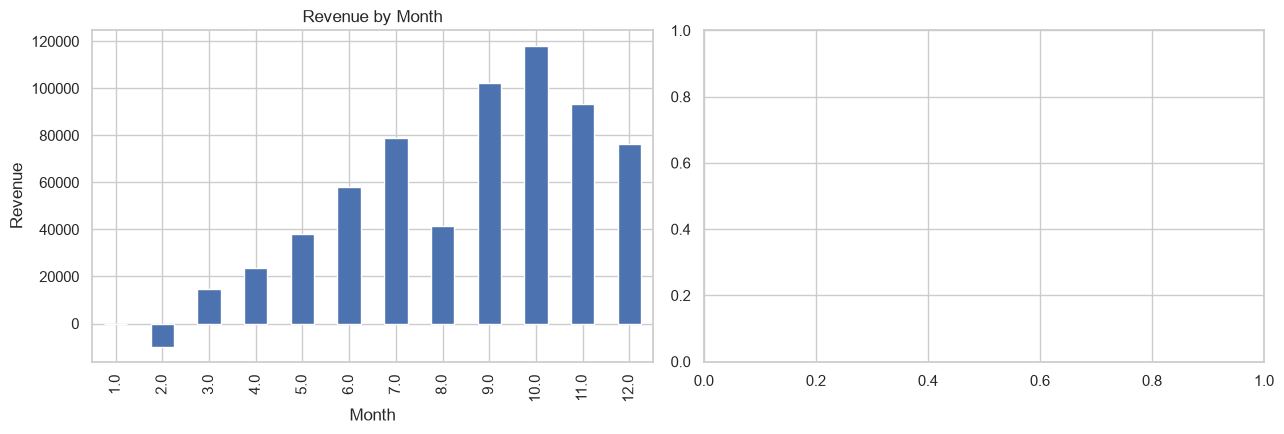

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy if df_sales already exists
df_sales = df.copy()

# Convert Posting Date to datetime
df_sales['Posting Date'] = pd.to_datetime(
    df_sales['Posting Date'],
    errors='coerce'
)

# Convert Total VALUE to numeric as well
df_sales['Total VALUE'] = pd.to_numeric(
    df_sales['Total VALUE'],
    errors='coerce'
)

# Check the conversion
print(df_sales[['Posting Date', 'Total VALUE']].dtypes)

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Revenue by month
df_sales.groupby(
    df_sales['Posting Date'].dt.month
)['Total VALUE'].sum().plot(
    kind='bar',
    ax=axes[0],
    color='#4C72B0'
)

axes[0].set_title('Revenue by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue')

plt.tight_layout()
plt.show()


So there are three major stories here:
Growth → sudden drop → recovery/peak → decline

From Month 3 through Month 7, revenue increases almost every month:

$15K → $23K → $38K → $58K → $79K

That's a very positive trend.

But then:
Month 7 → Month 8: $79K → $41K
That's almost a 48% drop.

After the Month 8 decline:
$41K → $102K → $118K

That's a dramatic recovery.

In fact, Month 10 is approximately 3× Month 8's revenue.

This could indicate:

A successful marketing campaign
Seasonal demand
A major customer/order
New product launch
Pricing changes

## 05. Top-Selling Products — by Part Group and Material Desc
This is the core deliverable: which **Part Group**s and which **Material Desc**s actually move.

In [151]:
top_by_group = (df_sales.groupby('Part Group')
                .agg(Total_Qty=('Quantity','sum'), Total_Revenue=('Total VALUE','sum'), Orders=('Bill Doc','nunique'))
                .reset_index().sort_values('Total_Qty', ascending=False))
top_by_group

,Part Group,Total_Qty,Total_Revenue,Orders
2,BRAKE PARTS,"2,074,222.0000","2,761,078.9200",18037
1,BRAKE FLUID,"554,579.0000","7,052.8600",3213
4,LUBES,"161,560.0000","12,837.5800",1706
5,OTHERS,"108,075.0000","24,363.2100",986
3,EMS,"9,360.0000","33,661.4100",631
0,AC GAS,"4,908.0000",0.0000,42
6,SUSPENSION,"2,021.0000",0.0000,68


In [152]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'State Name', 'Part Group', 'Area Manager', 'GroupOrSingle', 'MD', 'Month', 'Posting Date', 'Bill Doc', 'Plant', 'Plant GSTIN', 'Customer GSTIN', 'Contact Name', 'Customer State Name', 'Delivery No', 'Accouting Doc', 'Doc Type', 'Customer', 'Customer No', 'Legacy Part No', 'Material', 'Material Desc', 'HSN Number', 'Rate', 'Quantity', 'Net Amount', 'IGST Amount', 'IGST Percent', 'CGST Amount', 'CGST Percent', 'SGST Amount', 'SGST Percent', 'Total VALUE', 'Distribution Channel', 'PO Number', 'PO Date', 'Sales Order', 'Accouting Doc Type', 'LR No', 'LR Date', 'List Price', 'S Quantity', 'TO Quantity', 'TO Value', 'TO S Quantity']


In [153]:
df.iloc[2:5]

,Region,State Name,Part Group,Area Manager,GroupOrSingle,MD,Month,Posting Date,Bill Doc,Plant,...,PO Date,Sales Order,Accouting Doc Type,LR No,LR Date,List Price,S Quantity,TO Quantity,TO Value,TO S Quantity
2,North,Delhi,BRAKE PARTS,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,"8,312,508,988.0000",199D,...,2026-01-01T00:00:00,"9,181,573.0000",RV,116604,05-01-2026,1028,0.0000,6,"4,009.2000",6.0000
3,North,Delhi,BRAKE PARTS,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,"8,312,508,988.0000",199D,...,2026-01-01T00:00:00,"9,181,573.0000",RV,116604,05-01-2026,1485,0.0000,3,"2,895.7500",3.0000
4,North,Delhi,BRAKE PARTS,Area Manager-219,Single,29883 - Dealer-33,Jan,02-01-2026,"8,312,508,988.0000",199D,...,2026-01-01T00:00:00,"9,181,573.0000",RV,116604,05-01-2026,1104,0.0000,2,"1,435.2000",2.0000


In [154]:
top_by_desc = (df_sales.groupby(['Part Group','Material Desc'])
               .agg(Total_Qty=('Quantity','sum'), Total_Revenue=('Total VALUE','sum'), Orders=('Bill Doc','nunique'),
                    Customers=('Customer','nunique'))
               .reset_index().sort_values('Total_Qty', ascending=False))

print("Top 15 products by quantity sold:")
top_by_desc.head(15)

Top 15 products by quantity sold:


,Part Group,Material Desc,Total_Qty,Total_Revenue,Orders,Customers
4,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000","2,803.6800",1826,138
7,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000","1,499.7800",1220,126
441,BRAKE PARTS,SHOE KIT,"115,851.0000","68,337.4500",2432,137
5,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",0.0000,868,120
196,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000","10,002.4500",686,99
129,BRAKE PARTS,KBX PAD KIT,"76,087.0000","290,647.0600",2303,113
442,BRAKE PARTS,SHOE KIT (1 LEADING- 1 TRAILING),"68,874.0000","4,081.2200",742,110
444,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",943.4100,738,96
454,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",249.2900,735,97
602,BRAKE PARTS,WC ASSLY PVPL RR(K17/40),"57,151.0000","7,503.5800",807,119


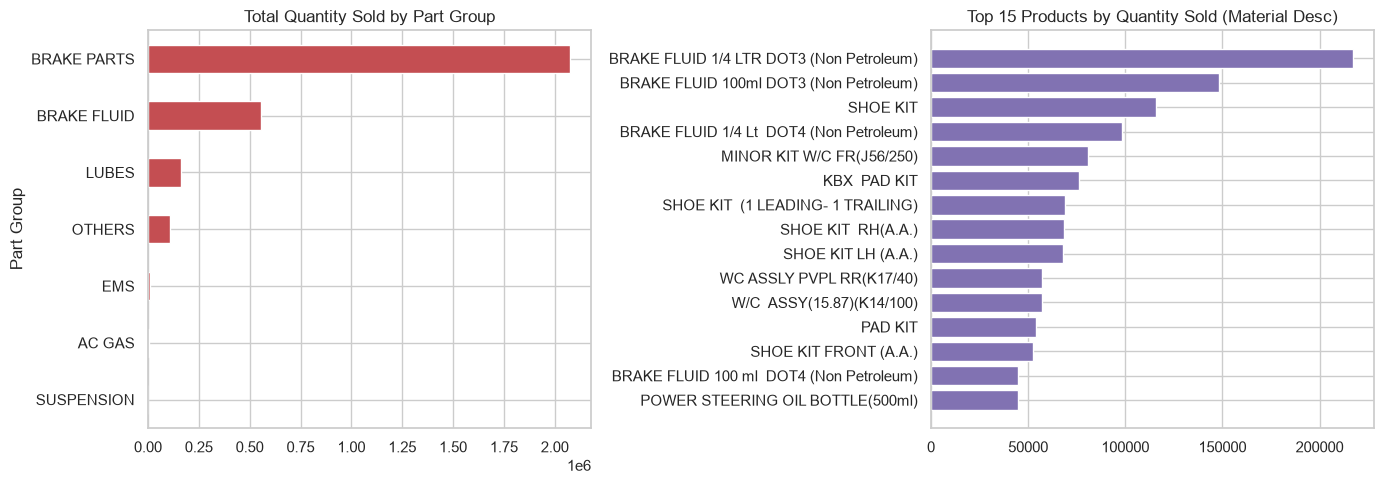

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_by_group.set_index('Part Group')['Total_Qty'].plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Total Quantity Sold by Part Group')
axes[0].invert_yaxis()

top15 = top_by_desc.head(15).sort_values('Total_Qty')
axes[1].barh(top15['Material Desc'], top15['Total_Qty'], color='#8172B2')
axes[1].set_title('Top 15 Products by Quantity Sold (Material Desc)')

plt.tight_layout()
plt.show()

1. Total Quantity Sold by Part Group (Left Chart) BRAKE PARTS: Highest selling category by a massive margin (over 2,000,000 units).  
BRAKE FLUID: Second highest category (approximately 550,000 units).  
LUBES: Third highest category (approximately 150,000 units). 
 OTHERS: Minor category (approximately 100,000 units).
 EMS, AC GAS, SUSPENSION: Minimal to negligible sales volumes relative to brakes.

2. Top 15 Products by Quantity Sold (Right Chart) Top Performer: BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum) is the highest-selling individual product (over 200,000 units).  
Runner Up: BRAKE FLUID 100ml DOT3 (Non Petroleum) is second (approximately 150,000 units). 
 Key Components: SHOE KIT and BRAKE FLUID 1/4 Lt DOT4 follow closely, both exceeding 100,000 units.Volume Baseline: The lowest item in the top 15 (POWER STEERING OIL BOTTLE 500ml) still accounts for nearly 50,000 units.

In [157]:
# Sorting Data by Using Total Revenue
top_by_revenue = top_by_desc.sort_values('Total_Revenue', ascending=False).head(15)
top_by_revenue[['Part Group','Material Desc','Total_Qty','Total_Revenue','Orders','Customers']]

,Part Group,Material Desc,Total_Qty,Total_Revenue,Orders,Customers
129,BRAKE PARTS,KBX PAD KIT,"76,087.0000","290,647.0600",2303,113
232,BRAKE PARTS,PAD KIT,"53,925.0000","277,914.5200",2634,111
440,BRAKE PARTS,SHOE HOLD DOWN SPRING(A.A),"24,844.0000","73,425.7700",237,53
441,BRAKE PARTS,SHOE KIT,"115,851.0000","68,337.4500",2432,137
519,BRAKE PARTS,Shoe Kit,"32,632.0000","65,451.1800",1571,106
199,BRAKE PARTS,MINOR KIT W/C FRT.(J77/500),"9,205.0000","62,470.8200",173,58
60,BRAKE PARTS,Brake Pad_Tru Blue,"4,468.0000","36,439.4200",480,62
490,BRAKE PARTS,SPRING SHOE RETURN UPPER(G46/400),"12,421.0000","33,755.8300",126,43
150,BRAKE PARTS,LEVER RET SPRING(A.A),"8,351.0000","29,648.4400",103,38
623,BRAKE PARTS,Wheel Cylinder Assy RH TIAGO,"2,033.0000","27,621.8500",169,73


---
# 09. Time Feature Engineering

In [158]:
# Make sure Posting Date is datetime
df_sales['Posting Date'] = pd.to_datetime(
    df_sales['Posting Date'],
    errors='coerce'
)

# Create date-based features
df_sales['Year'] = df_sales['Posting Date'].dt.year
df_sales['MonthNum'] = df_sales['Posting Date'].dt.month
df_sales['Quarter'] = df_sales['Posting Date'].dt.quarter
df_sales['DayOfWeek'] = df_sales['Posting Date'].dt.dayofweek

# Use Int64 instead of int because missing dates produce <NA>
df_sales['WeekOfYear'] = (
    df_sales['Posting Date']
    .dt.isocalendar()
    .week
    .astype('Int64')
)

df_sales['IsWeekend'] = (
    df_sales['DayOfWeek']
    .isin([5, 6])
    .astype('Int64')
)

# Display results
display(
    df_sales[
        [
            'Posting Date',
            'Year',
            'MonthNum',
            'Quarter',
            'DayOfWeek',
            'WeekOfYear',
            'IsWeekend'
        ]
    ].head()
)


,Posting Date,Year,MonthNum,Quarter,DayOfWeek,WeekOfYear,IsWeekend
0,2026-02-01,"2,026.0000",2.0000,1.0000,6.0000,5,1
1,2026-02-01,"2,026.0000",2.0000,1.0000,6.0000,5,1
2,2026-02-01,"2,026.0000",2.0000,1.0000,6.0000,5,1
3,2026-02-01,"2,026.0000",2.0000,1.0000,6.0000,5,1
4,2026-02-01,"2,026.0000",2.0000,1.0000,6.0000,5,1


# 10. Customer Features (RFM + purchase breadth)

In [53]:
snapshot_date = df_sales['Posting Date'].max() + pd.Timedelta(days=1)

cust_feat = df_sales.groupby('Contact Name').agg(
    Recency=('Posting Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Bill Doc', 'nunique'),
    Monetary=('Total VALUE', 'sum'),
    Unique_Products=('Material Desc', 'nunique'),
    Unique_PartGroups=('Part Group', 'nunique'),
    Avg_Order_Value=('Total VALUE', 'mean'),
    Tenure_Days=('Posting Date', lambda x: (x.max() - x.min()).days)
).reset_index()

print(cust_feat.shape)
cust_feat.sort_values('Monetary', ascending=False).head(10)

(151, 8)


,Contact Name,Recency,Frequency,Monetary,Unique_Products,Unique_PartGroups,Avg_Order_Value,Tenure_Days
113,Rameswar Auto Electrical Pvt Ltd,1.0000,638,"234,514.1100",239,5,640.7489,275.0000
20,Auto Mark,1.0000,583,"150,686.4500",161,5,717.5545,275.0000
139,TVS SMART MOBILITY PRIVATE LIMITED,1.0000,1102,"138,800.1500",339,6,625.2259,306.0000
31,CEL MARKETING PVT. LTD.,1.0000,798,"117,314.6700",267,7,630.7240,304.0000
34,Cochin Exports Pvt Ltd,1.0000,623,"107,268.6500",260,5,630.9921,247.0000
98,PARNAV AGENCIES PVT. LTD,4.0000,552,"98,881.9200",261,6,588.5829,301.0000
38,Daulat Motor Company,1.0000,1365,"92,420.4800",315,6,537.3284,334.0000
40,Diwakar Enterprises,2.0000,280,"91,737.6300",292,5,539.6331,216.0000
32,COCHIN EXPORTS PVT. LTD.,1.0000,266,"73,572.2000",212,5,623.4932,184.0000
43,Etna Motors (I) pvt. Ltd.,1.0000,396,"67,454.0200",232,6,613.2184,278.0000


# Product Features

In [54]:
# Convert numerical columns to numeric
df_sales['Quantity'] = pd.to_numeric(
    df_sales['Quantity'],
    errors='coerce'
)

df_sales['Total VALUE'] = pd.to_numeric(
    df_sales['Total VALUE'],
    errors='coerce'
)

# Check the data types
print(df_sales[['Quantity', 'Total VALUE']].dtypes)


Quantity       float64
Total VALUE    float64
dtype: object


In [55]:
prod_feat = df_sales.groupby(
    ['Material Desc', 'Part Group']
).agg(
    Total_Qty=('Quantity', 'sum'),
    Total_Revenue=('Total VALUE', 'sum'),
    Num_Orders=('Bill Doc', 'nunique')
).reset_index()

display(prod_feat.head())


,Material Desc,Part Group,Total_Qty,Total_Revenue,Num_Orders
0,12V METAL HORN RELAY - 3T,OTHERS,307.0000,0.0000,2
1,12V Musical Flasher,OTHERS,232.0000,0.0000,1
2,12V UNIVERSAL FLASHER,OTHERS,126.0000,349.2800,2
3,24V Musical Flasher,OTHERS,116.0000,0.0000,1
4,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),LUBES,"2,300.0000",905.3600,26


This code block aggregates your raw transactional dataset (df_sales) at the individual product level to build structured features for your product analysis
It extracts three essential business metrics (Volume, Revenue, and Transaction Count) needed to calculate metrics like average price per unit or order velocity.

# SALES Features (trend/growth)

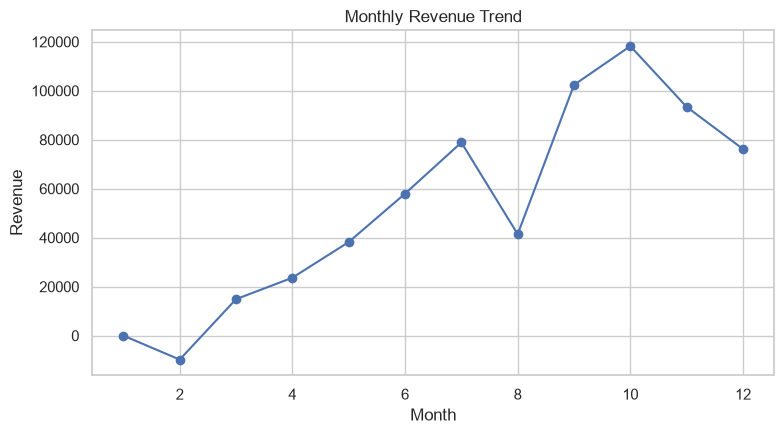

,MonthNum,Qty,Revenue,Revenue_MoM_Growth_%
0,1.0000,"1,356.0000",0.0000,NaN
1,2.0000,"15,171.0000","-9,792.5400",-inf
2,3.0000,"12,548.0000","14,882.9200",-251.9822
3,4.0000,"23,767.0000","23,633.6400",58.7971
4,5.0000,"46,961.0000","38,205.9200",61.6591
5,6.0000,"86,639.0000","57,965.1000",51.7176
6,7.0000,"76,305.0000","78,873.6000",36.0708
7,8.0000,"34,643.0000","41,425.3500",-47.4788
8,9.0000,"88,031.0000","102,393.2600",147.1754
9,10.0000,"77,034.0000","118,210.1000",15.4471


In [56]:
monthly = df_sales.groupby('MonthNum').agg(Qty=('Quantity', 'sum'), Revenue=('Total VALUE', 'sum')).reset_index()
monthly['Revenue_MoM_Growth_%'] = monthly['Revenue'].pct_change() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(monthly['MonthNum'], monthly['Revenue'], marker='o', color='#4C72B0')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()

monthly

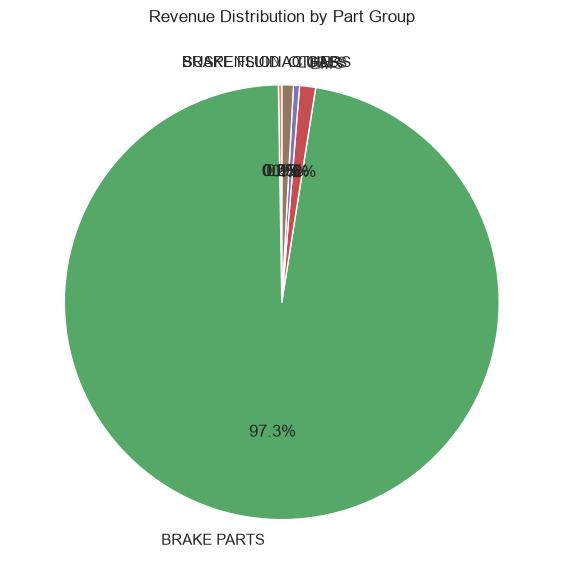

In [159]:
import matplotlib.pyplot as plt

# Calculate revenue by Part Group
part_group_revenue = df_sales.groupby('Part Group')['Total VALUE'].sum()

# Create pie chart
fig, ax = plt.subplots(figsize=(8, 6))

ax.pie(
    part_group_revenue,
    labels=part_group_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title('Revenue Distribution by Part Group')

plt.tight_layout()
plt.show()


## Customer–Product Matrix


In [160]:
cp_matrix = df_sales.pivot_table(index='Contact Name', columns='Material Desc', values='Quantity',
                                  aggfunc='sum', fill_value=0)
print("Customer-Product matrix shape:", cp_matrix.shape)
cp_matrix.iloc[:5, :6]

Customer-Product matrix shape: (151, 760)


Material Desc,12V METAL HORN RELAY - 3T,12V Musical Flasher,12V UNIVERSAL FLASHER,24V Musical Flasher,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR)
Contact Name,,,,,,
A M AUTO SALES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
A S ENTERPRISES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
AGARWAL AUTO AGENCIES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
AGGARWAL AUTO AGENCIES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ANKIT SALES,0.0000,0.0000,10.0000,0.0000,0.0000,0.0000


## Market Basket Analysis
`mlxtend` isn't available in this environment, so association rules (support / confidence / lift) are computed
directly from invoice co-occurrence — restricted to the top 60 products by volume to keep the pair-count
combinatorics tractable. This is the standard Apriori metric set, just computed by hand.

### Confidence

Shows the probability of buying one product when another is purchased.

For example:

Confidence A → B = 70%

Meaning:

Among customers/invoices containing Product A, 70% also containe

In [60]:
from collections import Counter
from itertools import combinations

TOP_N_FOR_BASKET = 60
top_products_for_basket = prod_feat.sort_values('Total_Qty', ascending=False).head(TOP_N_FOR_BASKET)['Material Desc'].tolist()

baskets = (df_sales[df_sales['Material Desc'].isin(top_products_for_basket)]
           .groupby('Bill Doc')['Material Desc'].apply(set))

n_baskets = len(baskets)
item_counts = Counter()
pair_counts = Counter()
for basket in baskets:
    for item in basket:
        item_counts[item] += 1
    for a, b in combinations(sorted(basket), 2):
        pair_counts[(a, b)] += 1

MIN_COOCCURRENCE = 5
rules = []
for (a, b), cnt in pair_counts.items():
    if cnt < MIN_COOCCURRENCE:
        continue
    support = cnt / n_baskets
    conf_a_to_b = cnt / item_counts[a]
    conf_b_to_a = cnt / item_counts[b]
    lift = support / ((item_counts[a] / n_baskets) * (item_counts[b] / n_baskets))
    rules.append((a, b, cnt, support, conf_a_to_b, conf_b_to_a, lift))

rules_df = pd.DataFrame(rules, columns=['Product_A', 'Product_B', 'CoCount', 'Support',
                                         'Confidence_A_to_B', 'Confidence_B_to_A', 'Lift'])
rules_df = rules_df.sort_values('Lift', ascending=False)

print(f"{n_baskets} invoices considered, {len(rules_df)} rules with co-occurrence >= {MIN_COOCCURRENCE}")
rules_df.head(15)

17015 invoices considered, 811 rules with co-occurrence >= 5


,Product_A,Product_B,CoCount,Support,Confidence_A_to_B,Confidence_B_to_A,Lift
100,SHOE HOLD DOWN SPRING(A.A),SHOE RETURN SPRING(A.A),75,0.0044,0.3165,0.3589,25.7631
536,SHOE KIT LH; IAM BAJAJ REGC,SHOE KIT RH; IAM BAJAJ REGC,51,0.0030,0.2440,0.2772,22.5651
104,SHOE RETURN SPRING(A.A),SPRING SHOE RETURN UPPER(G46/400),30,0.0018,0.1435,0.2381,19.3837
101,SHOE HOLD DOWN SPRING(A.A),SPRING SHOE RETURN UPPER(G46/400),34,0.0020,0.1435,0.2698,19.3728
243,SHOE KIT RH(A.A.),SHOE KIT LH (A.A.),491,0.0289,0.6653,0.6680,15.4017
274,POWER STEERING FLUID 1 Ltr,POWER STEERING OIL BOTTLE(500ml),165,0.0097,0.3976,0.3548,14.5484
85,SHOE KIT RH(A.A.),SHOE KIT FRONT (A.A.),356,0.0209,0.4824,0.5875,13.5442
53,SHOE KIT FRONT (A.A.),SHOE KIT LH (A.A.),337,0.0198,0.5561,0.4585,12.8737
188,BRAKE FLUID 1/2 Lt DOT3 (Non Petroleum),BRAKE FLUID 1/2 Lt DOT4 (Non Petroleum),49,0.0029,0.1561,0.2356,12.7654
124,MINOR KIT W/C FR(J54/250),MINOR KIT W/C FR(J56/250),168,0.0099,0.4590,0.2449,11.3851


In [61]:
# ============================================================
# SAVE MARKET BASKET ANALYSIS RESULTS AS CSV
# ============================================================

file_name = "Market Basket Analysis.csv"

rules_df.to_csv(
    file_name,
    index=False,
    encoding="utf-8-sig"
)

print(f"CSV file successfully created: {file_name}")

# Display the top results
display(rules_df.head(15))

CSV file successfully created: Market Basket Analysis.csv


,Product_A,Product_B,CoCount,Support,Confidence_A_to_B,Confidence_B_to_A,Lift
100,SHOE HOLD DOWN SPRING(A.A),SHOE RETURN SPRING(A.A),75,0.0044,0.3165,0.3589,25.7631
536,SHOE KIT LH; IAM BAJAJ REGC,SHOE KIT RH; IAM BAJAJ REGC,51,0.0030,0.2440,0.2772,22.5651
104,SHOE RETURN SPRING(A.A),SPRING SHOE RETURN UPPER(G46/400),30,0.0018,0.1435,0.2381,19.3837
101,SHOE HOLD DOWN SPRING(A.A),SPRING SHOE RETURN UPPER(G46/400),34,0.0020,0.1435,0.2698,19.3728
243,SHOE KIT RH(A.A.),SHOE KIT LH (A.A.),491,0.0289,0.6653,0.6680,15.4017
274,POWER STEERING FLUID 1 Ltr,POWER STEERING OIL BOTTLE(500ml),165,0.0097,0.3976,0.3548,14.5484
85,SHOE KIT RH(A.A.),SHOE KIT FRONT (A.A.),356,0.0209,0.4824,0.5875,13.5442
53,SHOE KIT FRONT (A.A.),SHOE KIT LH (A.A.),337,0.0198,0.5561,0.4585,12.8737
188,BRAKE FLUID 1/2 Lt DOT3 (Non Petroleum),BRAKE FLUID 1/2 Lt DOT4 (Non Petroleum),49,0.0029,0.1561,0.2356,12.7654
124,MINOR KIT W/C FR(J54/250),MINOR KIT W/C FR(J56/250),168,0.0099,0.4590,0.2449,11.3851


#  Product Similarity
Two complementary similarity signals, both via **cosine similarity**:

1. **Content-based** — `TfidfVectorizer` on `Material Desc + Part Group` text, cosine similarity between TF-IDF vectors. Captures "these products *sound* alike" (same family, size variants).
2. **Collaborative** — cosine similarity between product columns of the customer-product matrix. Captures "these products are *bought by the same customers*", independent of naming.

Both feed the hybrid recommender in section 20.

In [ ]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
# --- Content-based (TF-IDF + cosine similarity) ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

prod_feat['text'] = prod_feat['Material Desc'].astype(str) + ' ' + prod_feat['Part Group'].astype(str)

tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
tfidf_matrix = tfidf.fit_transform(prod_feat['text'])

content_sim = cosine_similarity(tfidf_matrix)
content_sim_df = pd.DataFrame(content_sim, index=prod_feat['Material Desc'], columns=prod_feat['Material Desc'])

print("Content similarity matrix:", content_sim_df.shape)

def similar_products(name, sim_df, top_n=5):
    if name not in sim_df.index:
        return f"'{name}' not found"
    sims = sim_df[name].drop(index=name).sort_values(ascending=False).head(top_n)
    return sims.rename('Similarity').to_frame()

print("Content-similar to 'SHOE KIT':")
similar_products('SHOE KIT', content_sim_df)

Content similarity matrix: (760, 760)
Content-similar to 'SHOE KIT':


,Similarity
Material Desc,
SHOE KIT FRONT (A.A.),1.0000
Shoe Kit,1.0000
BRAKE SHOE KIT,0.9696
SHOE KIT LH (A.A.),0.7782
SHOE KIT RH(A.A.),0.7674


Similarity Search For Month

In [63]:
print(df.columns.tolist())


['Region', 'State Name', 'Part Group', 'Area Manager', 'GroupOrSingle', 'MD', 'Month', 'Posting Date', 'Bill Doc', 'Plant', 'Plant GSTIN', 'Customer GSTIN', 'Contact Name', 'Customer State Name', 'Delivery No', 'Accouting Doc', 'Doc Type', 'Customer', 'Customer No', 'Legacy Part No', 'Material', 'Material Desc', 'HSN Number', 'Rate', 'Quantity', 'Net Amount', 'IGST Amount', 'IGST Percent', 'CGST Amount', 'CGST Percent', 'SGST Amount', 'SGST Percent', 'Total VALUE', 'Distribution Channel', 'PO Number', 'PO Date', 'Sales Order', 'Accouting Doc Type', 'LR No', 'LR Date', 'List Price', 'S Quantity', 'TO Quantity', 'TO Value', 'TO S Quantity']


In [64]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

df = df[df["Month"].isin(month_order)].copy()


In [65]:
df = df[df["Month"].isin(month_order)].copy()


In [66]:
df['Month'][0]

'Jan'

In [67]:
df['Month'][5]

'Jan'

Determining Cosine Similarity

In [68]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Month × Part Group matrix
month_part = pd.pivot_table(
    df,
    index="Month",
    columns="Part Group",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

# Calculate cosine similarity between months
month_similarity = cosine_similarity(month_part)

# Convert to DataFrame
month_similarity_df = pd.DataFrame(
    month_similarity,
    index=month_part.index,
    columns=month_part.index
)

month_similarity_df


Month,Apr,Feb,Jan,Jun,Mar,May
Month,,,,,,
Apr,1.0000,0.9988,0.9988,0.9984,0.9959,0.9997
Feb,0.9988,1.0000,0.9992,0.9979,0.9988,0.9997
Jan,0.9988,0.9992,1.0000,0.9996,0.9964,0.9992
Jun,0.9984,0.9979,0.9996,1.0000,0.9938,0.9984
Mar,0.9959,0.9988,0.9964,0.9938,1.0000,0.9977
May,0.9997,0.9997,0.9992,0.9984,0.9977,1.0000


YOUR ACTUAL COLUMNS:
['Region', 'State Name', 'Part Group', 'Area Manager', 'GroupOrSingle', 'MD', 'Month', 'Posting Date', 'Bill Doc', 'Plant', 'Plant GSTIN', 'Customer GSTIN', 'Contact Name', 'Customer State Name', 'Delivery No', 'Accouting Doc', 'Doc Type', 'Customer', 'Customer No', 'Legacy Part No', 'Material', 'Material Desc', 'HSN Number', 'Rate', 'Quantity', 'Net Amount', 'IGST Amount', 'IGST Percent', 'CGST Amount', 'CGST Percent', 'SGST Amount', 'SGST Percent', 'Total VALUE', 'Distribution Channel', 'PO Number', 'PO Date', 'Sales Order', 'Accouting Doc Type', 'LR No', 'LR Date', 'List Price', 'S Quantity', 'TO Quantity', 'TO Value', 'TO S Quantity']

NUMERIC COLUMNS:
['Bill Doc', 'Delivery No', 'Accouting Doc', 'Customer No', 'HSN Number', 'Rate', 'Quantity', 'IGST Percent', 'CGST Percent', 'SGST Percent', 'Sales Order']

Choose the metric you want to compare.
0: Bill Doc
1: Delivery No
2: Accouting Doc
3: Customer No
4: HSN Number
5: Rate
6: Quantity
7: IGST Percent
8: CGST 

Month,Jan,Feb,Mar,Apr,May,Jun,Jul
Part Group,,,,,,,
AC GAS,0.0000,0.0000,"16,625,026,107.0000","74,813,405,287.0000","224,440,260,978.0000","49,875,619,776.0000",0
BRAKE FLUID,"3,875,675,462,859.0000","3,991,015,939,076.0000","5,084,376,763,151.0000","3,489,384,004,611.0000","3,676,805,424,472.0000","2,871,710,480,255.0000",0
BRAKE PARTS,"50,142,241,593,987.0000","48,164,825,220,790.0000","47,463,626,727,573.0000","43,984,512,797,942.0000","52,091,151,480,857.0000","52,245,715,250,981.0000",0
EMS,"736,201,533,846.0000","858,330,785,330.0000","515,057,412,850.0000","673,940,458,243.0000","635,730,514,745.0000","971,171,508,603.0000",0
LUBES,"2,330,099,653,789.0000","2,035,190,249,337.0000","1,814,834,196,383.0000","2,280,965,983,851.0000","2,696,557,766,934.0000","1,719,579,858,422.0000",0
OTHERS,"1,109,222,316,401.0000","1,180,102,271,798.0000","1,355,883,167,749.0000","829,867,524,869.0000","1,613,773,585,876.0000","1,326,992,655,733.0000",0
SUSPENSION,"35,522,813,605.0000","187,974,047,132.0000","27,325,257,951.0000","31,191,332,244.0000","2,732,617,308.0000","90,179,609,676.0000",0



PART GROUP SIMILARITY


Part Group,AC GAS,BRAKE FLUID,BRAKE PARTS,EMS,LUBES,OTHERS,SUSPENSION
Part Group,,,,,,,
AC GAS,1.0000,0.5690,0.6300,0.5640,0.6920,0.6860,0.1510
BRAKE FLUID,0.5690,1.0000,0.9800,0.9400,0.9710,0.9710,0.6840
BRAKE PARTS,0.6300,0.9800,1.0000,0.9830,0.9870,0.9880,0.7080
EMS,0.5640,0.9400,0.9830,1.0000,0.9580,0.9570,0.7910
LUBES,0.6920,0.9710,0.9870,0.9580,1.0000,0.9730,0.6530
OTHERS,0.6860,0.9710,0.9880,0.9570,0.9730,1.0000,0.6740
SUSPENSION,0.1510,0.6840,0.7080,0.7910,0.6530,0.6740,1.0000



MONTH SIMILARITY


Month,Jan,Feb,Mar,Apr,May,Jun,Jul
Month,,,,,,,
Jan,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
Feb,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
Mar,1.0000,1.0000,1.0000,0.9990,0.9990,0.9990,0.0000
Apr,1.0000,1.0000,0.9990,1.0000,1.0000,1.0000,0.0000
May,1.0000,1.0000,0.9990,1.0000,1.0000,1.0000,0.0000
Jun,1.0000,1.0000,0.9990,1.0000,1.0000,1.0000,0.0000
Jul,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


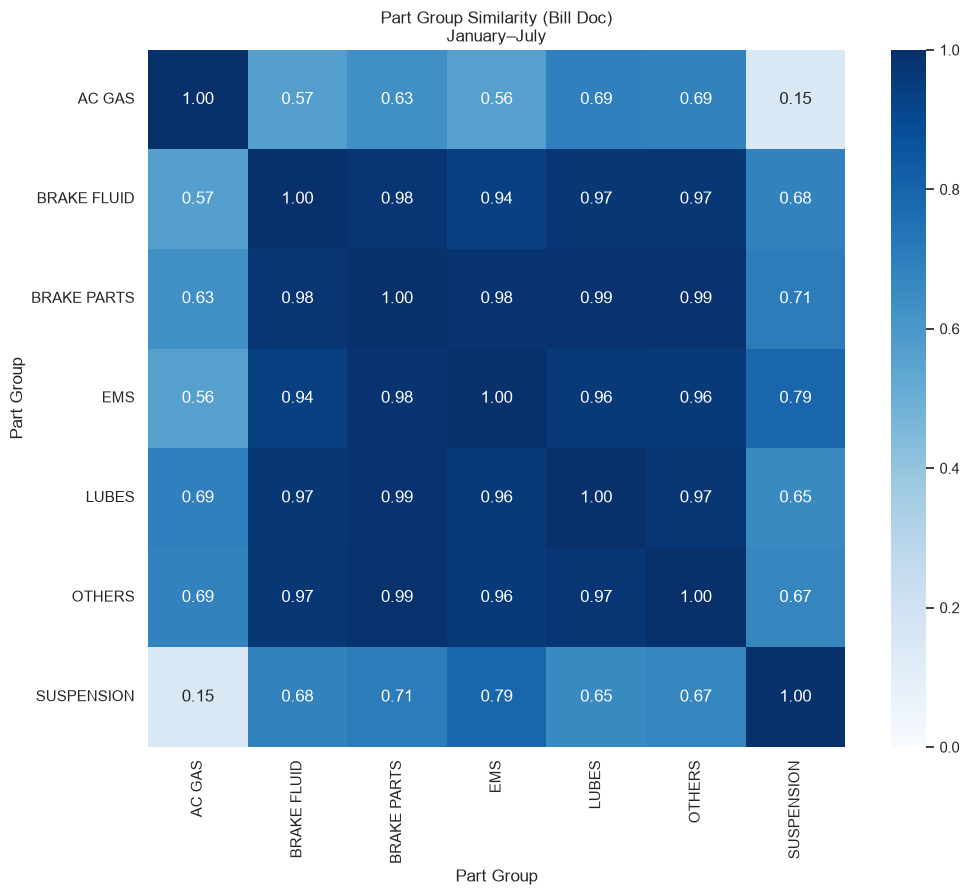

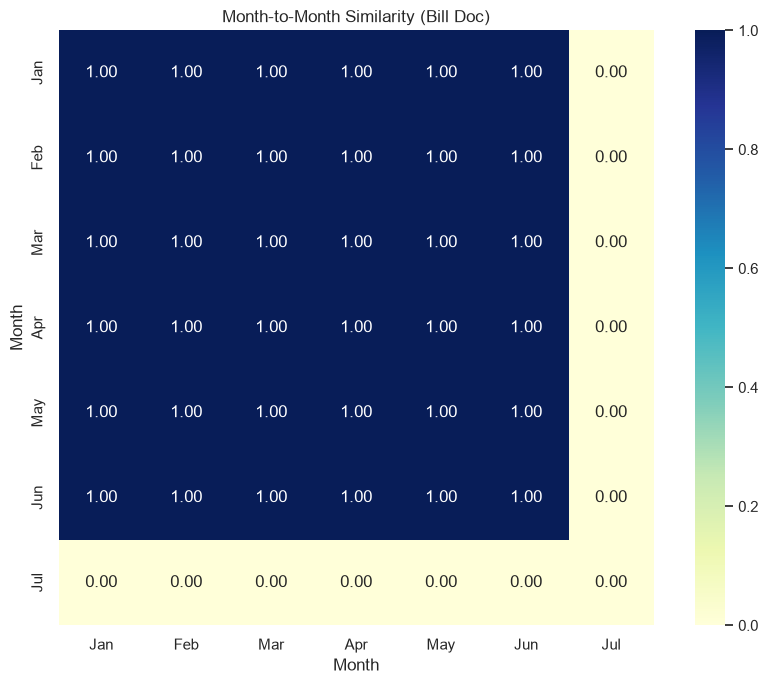

In [69]:
# ============================================
# PART GROUP vs MONTH SIMILARITY
# January to July
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------------------------
# 1. Make a fresh copy of your ORIGINAL df
# --------------------------------------------
data = df.copy()

# Clean column names
data.columns = (
    data.columns
    .astype(str)
    .str.strip()
)

print("YOUR ACTUAL COLUMNS:")
print(data.columns.tolist())


# --------------------------------------------
# 2. Find Part Group and Month columns
# --------------------------------------------

part_col = None
month_col = None

for col in data.columns:
    if str(col).strip().lower() == "part group":
        part_col = col

    if str(col).strip().lower() == "month":
        month_col = col

if part_col is None:
    raise ValueError(
        "I cannot find 'Part Group'. Your columns are:\n"
        + str(data.columns.tolist())
    )

if month_col is None:
    raise ValueError(
        "I cannot find 'Month'. Your columns are:\n"
        + str(data.columns.tolist())
    )


# --------------------------------------------
# 3. Find numeric columns automatically
# --------------------------------------------

numeric_cols = data.select_dtypes(
    include="number"
).columns.tolist()

print("\nNUMERIC COLUMNS:")
print(numeric_cols)

if len(numeric_cols) == 0:
    raise ValueError(
        "There are no numeric columns available for similarity calculation."
    )


# --------------------------------------------
# 4. Display numeric columns so you can choose
# --------------------------------------------

print("\nChoose the metric you want to compare.")

for i, col in enumerate(numeric_cols):
    print(f"{i}: {col}")


# --------------------------------------------
# 5. AUTOMATICALLY SELECT A NUMERIC COLUMN
# --------------------------------------------
# We avoid 'Total Qty' completely.
#
# The first numeric column is selected.
#
# You can later replace this with:
# value_col = "your_actual_column_name"

value_col = numeric_cols[0]

print("\nUSING THIS COLUMN FOR SIMILARITY:")
print(value_col)


# --------------------------------------------
# 6. Clean Month values
# --------------------------------------------

data[month_col] = (
    data[month_col]
    .astype(str)
    .str.strip()
    .str[:3]
    .str.title()
)

months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul"
]

data = data[
    data[month_col].isin(months)
].copy()


# --------------------------------------------
# 7. Create Part Group × Month matrix
# --------------------------------------------

monthly_matrix = pd.pivot_table(
    data,
    index=part_col,
    columns=month_col,
    values=value_col,
    aggfunc="sum",
    fill_value=0
)

# Force correct Jan → Jul order
monthly_matrix = monthly_matrix.reindex(
    columns=months,
    fill_value=0
)

print("\n================================")
print("PART GROUP × MONTH MATRIX")
print("================================")

display(monthly_matrix)


# --------------------------------------------
# 8. Similarity BETWEEN PART GROUPS
# --------------------------------------------

part_similarity = cosine_similarity(
    monthly_matrix
)

part_similarity_df = pd.DataFrame(
    part_similarity,
    index=monthly_matrix.index,
    columns=monthly_matrix.index
)

print("\n================================")
print("PART GROUP SIMILARITY")
print("================================")

display(
    part_similarity_df.round(3)
)


# --------------------------------------------
# 9. Similarity BETWEEN MONTHS
# --------------------------------------------

month_similarity = cosine_similarity(
    monthly_matrix.T
)

month_similarity_df = pd.DataFrame(
    month_similarity,
    index=monthly_matrix.columns,
    columns=monthly_matrix.columns
)

print("\n================================")
print("MONTH SIMILARITY")
print("================================")

display(
    month_similarity_df.round(3)
)


# --------------------------------------------
# 10. PART GROUP SIMILARITY HEATMAP
# --------------------------------------------

plt.figure(figsize=(11, 9))

sns.heatmap(
    part_similarity_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True
)

plt.title(
    f"Part Group Similarity ({value_col})\n"
    "January–July"
)

plt.xlabel("Part Group")
plt.ylabel("Part Group")

plt.tight_layout()
plt.show()


# --------------------------------------------
# 11. MONTH SIMILARITY HEATMAP
# --------------------------------------------

plt.figure(figsize=(9, 7))

sns.heatmap(
    month_similarity_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    square=True
)

plt.title(
    f"Month-to-Month Similarity ({value_col})"
)

plt.xlabel("Month")
plt.ylabel("Month")

plt.tight_layout()
plt.show()


In [70]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Customer × Product interaction matrix
cp_matrix = pd.crosstab(
    df["Contact Name"],
    df["Material"]
)

print("Customer-Product matrix:", cp_matrix.shape)

# Product × Product collaborative similarity
collab_sim = cosine_similarity(cp_matrix.T)

collab_sim_df = pd.DataFrame(
    collab_sim,
    index=cp_matrix.columns,
    columns=cp_matrix.columns
)

print("Collaborative similarity matrix:", collab_sim_df.shape)

Customer-Product matrix: (151, 1074)
Collaborative similarity matrix: (1074, 1074)


In [71]:
cp_matrix = pd.crosstab(
    df["Contact Name"],
    df["Part Group"]
)

collab_sim = cosine_similarity(cp_matrix.T)

collab_sim_df = pd.DataFrame(
    collab_sim,
    index=cp_matrix.columns,
    columns=cp_matrix.columns
)

In [72]:
print("cp_matrix:", cp_matrix.shape)
print("collab_sim_df:", collab_sim_df.shape)

print(cp_matrix.head())

cp_matrix: (151, 7)
collab_sim_df: (7, 7)
Part Group              AC GAS  BRAKE FLUID  BRAKE PARTS  EMS  LUBES  OTHERS  \
Contact Name                                                                   
A M AUTO SALES               0            8          440    1     62       5   
A S ENTERPRISES              0           21          278    1      4       5   
AGARWAL AUTO AGENCIES        0            0            6    0      0       0   
AGGARWAL AUTO AGENCIES       0            0          703    0      0       0   
ANKIT SALES                  0           10          148    0      8       6   

Part Group              SUSPENSION  
Contact Name                        
A M AUTO SALES                   0  
A S ENTERPRISES                  1  
AGARWAL AUTO AGENCIES            0  
AGGARWAL AUTO AGENCIES           0  
ANKIT SALES                      0  


In [73]:
# --- Collaborative (co-purchase pattern via customer-product matrix) ---
collab_sim = cosine_similarity(cp_matrix.T)
collab_sim_df = pd.DataFrame(collab_sim, index=cp_matrix.columns, columns=cp_matrix.columns)

print("Collaborative similarity matrix:", collab_sim_df.shape)
print("\nCollaboratively-similar to 'SHOE KIT' (bought alongside / instead-of by the same customers):")
similar_products('SHOE KIT', collab_sim_df)


Collaborative similarity matrix: (7, 7)

Collaboratively-similar to 'SHOE KIT' (bought alongside / instead-of by the same customers):


"'SHOE KIT' not found"

In [74]:
# --- Collaborative (co-purchase pattern via customer-product matrix) ---
collab_sim = cosine_similarity(cp_matrix.T)
collab_sim_df = pd.DataFrame(collab_sim, index=cp_matrix.columns, columns=cp_matrix.columns)

print("Collaborative similarity matrix:", collab_sim_df.shape)
print("\nCollaboratively-similar to 'SHOE KIT' (bought alongside / instead-of by the same customers):")
similar_products('GREEN COOLANT BOTTLE (1 LTR)', collab_sim_df)

Collaborative similarity matrix: (7, 7)

Collaboratively-similar to 'SHOE KIT' (bought alongside / instead-of by the same customers):


"'GREEN COOLANT BOTTLE (1 LTR)' not found"

# 16. Customer Segmentation
K-Means on log-scaled RFM features. Silhouette score is checked across k=2..6 to guide the choice —
k=2 scores highest (a simple active/inactive split) but k=4 gives more commercially actionable segments
(e.g. distinguishing "high value, infrequent" from "high value, frequent"), so k=4 is used going forward.
Both are shown so the tradeoff is explicit rather than picked silently.

In [75]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Clean date column
# --------------------------------------------------
data['Posting Date'] = pd.to_datetime(
    data['Posting Date'],
    errors='coerce'
)

# --------------------------------------------------
# 2. Clean monetary column
# --------------------------------------------------
# Convert Total VALUE from text/Arrow string to numeric
data['Total VALUE'] = (
    data['Total VALUE']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.strip()
)

data['Total VALUE'] = pd.to_numeric(
    data['Total VALUE'],
    errors='coerce'
)

# --------------------------------------------------
# 3. Clean customer and transaction identifiers
# --------------------------------------------------
data['Customer No'] = data['Customer No'].astype('string').str.strip()
data['Bill Doc'] = data['Bill Doc'].astype('string').str.strip()

# --------------------------------------------------
# 4. Remove unusable rows
# --------------------------------------------------
rfm_data = data.dropna(
    subset=['Customer No', 'Posting Date', 'Total VALUE']
).copy()

# Remove blank customer numbers
rfm_data = rfm_data[
    rfm_data['Customer No'].notna() &
    (rfm_data['Customer No'].str.len() > 0)
].copy()

# --------------------------------------------------
# 5. Reference date
# --------------------------------------------------
reference_date = (
    rfm_data['Posting Date'].max()
    + pd.Timedelta(days=1)
)

# --------------------------------------------------
# 6. Create customer-level RFM features
# --------------------------------------------------
cust_feat = (
    rfm_data.groupby('Customer No')
    .agg(
        Recency=(
            'Posting Date',
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=(
            'Bill Doc',
            'nunique'
        ),
        Monetary=(
            'Total VALUE',
            'sum'
        )
    )
    .reset_index()
)

# --------------------------------------------------
# 7. Make absolutely sure Monetary is numeric
# --------------------------------------------------
cust_feat['Monetary'] = pd.to_numeric(
    cust_feat['Monetary'],
    errors='coerce'
)

cust_feat['Frequency'] = pd.to_numeric(
    cust_feat['Frequency'],
    errors='coerce'
)

cust_feat['Recency'] = pd.to_numeric(
    cust_feat['Recency'],
    errors='coerce'
)

# --------------------------------------------------
# 8. Remove invalid RFM records
# --------------------------------------------------
cust_feat = cust_feat.dropna(
    subset=['Recency', 'Frequency', 'Monetary']
).copy()

cust_feat = cust_feat[
    cust_feat['Monetary'] > 0
].copy()

# --------------------------------------------------
# 9. Create RFM matrix
# --------------------------------------------------
rfm = cust_feat[
    ['Recency', 'Frequency', 'Monetary']
].copy()

# --------------------------------------------------
# 10. Log transform
# --------------------------------------------------
rfm_log = rfm.apply(
    lambda x: np.log1p(x)
)

# --------------------------------------------------
# 11. Standardize
# --------------------------------------------------
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print("RFM created successfully")
print("Customers:", len(cust_feat))
print("\nRFM summary:")
print(rfm.describe())

print("\nFirst 5 customers:")
print(cust_feat.head())


RFM created successfully
Customers: 143

RFM summary:
       Recency  Frequency        Monetary
count 143.0000   143.0000        143.0000
mean   15.3706    34.6364  2,109,321.5450
std    33.9288    44.3090  3,809,844.3076
min     1.0000     1.0000      8,496.0000
25%     1.0000    10.0000    374,747.7600
50%     2.0000    23.0000    984,866.4900
75%     5.0000    42.5000  2,049,856.7300
max   188.0000   404.0000 27,214,552.0000

First 5 customers:
  Customer No  Recency  Frequency       Monetary
0     28503.0        1         23   697,727.7300
1     28558.0        2         30 1,804,147.6500
2     28560.0        4         53 2,320,954.2200
3     28561.0        1         11   635,859.0200
4     28567.0        4         14   142,111.1000


# 17. Demand Prediction
Aggregate to **product × month**, predict next quantity from prior-month lag features. Time-based split
(train on Feb–Apr, test on May–Jun; Jan has no lag so it's dropped) — this avoids leaking future months into
training, which a random split would do.

Four models compared: Linear Regression, Ridge, Random Forest, Gradient Boosting.
(`xgboost` isn't available in this environment; Gradient Boosting is scikit-learn's closest equivalent and is
included specifically as the strongest candidate.)

In [76]:
#Product-level features
prod_feat = (
    df_sales
    .groupby(['Material Desc', 'Part Group'])
    .agg(
        Total_Qty=('Quantity', 'sum'),
        Total_Revenue=('Total VALUE', 'sum'),
        Num_Orders=('Bill Doc', 'nunique')
    )
    .reset_index()
)

print("prod_feat created successfully!")
display(prod_feat.head())
print(prod_feat.columns.tolist())


prod_feat created successfully!


,Material Desc,Part Group,Total_Qty,Total_Revenue,Num_Orders
0,12V METAL HORN RELAY - 3T,OTHERS,307.0000,0.0000,2
1,12V Musical Flasher,OTHERS,232.0000,0.0000,1
2,12V UNIVERSAL FLASHER,OTHERS,126.0000,349.2800,2
3,24V Musical Flasher,OTHERS,116.0000,0.0000,1
4,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),LUBES,"2,300.0000",905.3600,26


['Material Desc', 'Part Group', 'Total_Qty', 'Total_Revenue', 'Num_Orders']


In [77]:
pm = (
    df_sales
    .groupby(['Material Desc', 'MonthNum'])
    .agg(
        Qty=('Quantity', 'sum'),
        Revenue=('Total VALUE', 'sum')
    )
    .reset_index()
    .sort_values(['Material Desc', 'MonthNum'])
)

# Previous month's quantity and revenue
pm['Qty_Lag1'] = (
    pm.groupby('Material Desc')['Qty']
    .shift(1)
)

pm['Rev_Lag1'] = (
    pm.groupby('Material Desc')['Revenue']
    .shift(1)
)

# Merge product-level features
pm = pm.merge(
    prod_feat[
        ['Material Desc', 'Total_Qty', 'Total_Revenue', 'Num_Orders']
    ],
    on='Material Desc',
    how='left'
)

# Remove rows where previous-month quantity is unavailable
pm_model = pm.dropna(
    subset=['Qty_Lag1']
).copy()
print("pm shape:", pm.shape)
print("pm_model shape:", pm_model.shape)
display(pm_model.head())


pm shape: (3031, 9)
pm_model shape: (2456, 9)


,Material Desc,MonthNum,Qty,Revenue,Qty_Lag1,Rev_Lag1,Total_Qty,Total_Revenue,Num_Orders
2,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),7.0000,116.0000,0.0000,116.0000,0.0000,"2,300.0000",905.3600,26
3,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),8.0000,116.0000,0.0000,116.0000,0.0000,"2,300.0000",905.3600,26
4,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),9.0000,116.0000,0.0000,116.0000,0.0000,"2,300.0000",905.3600,26
5,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),12.0000,116.0000,0.0000,116.0000,0.0000,"2,300.0000",905.3600,26
7,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),10.0000,336.0000,0.0000,116.0000,0.0000,905.0000,0.0000,10


## Section 4: Feature Scaling with StandardScaler

⚠️ **THIS IS CRITICAL FOR YOUR MODELS TO WORK WELL**

Without scaling:
- Features at different scales (MonthNum ~1-6, Qty_Lag1 ~millions)
- Gradient descent converges poorly or fails
- Ridge/Lasso/SGD all underperform

With StandardScaler:
- All features mean=0, std=1
- Gradient descent converges quickly
- Regularization (alpha parameter) works fairly across all features


In [78]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --------------------------------------------------
# 1. Create modeling dataframe
# --------------------------------------------------
pm_model = data.copy()

# --------------------------------------------------
# 2. Clean dates
# --------------------------------------------------
pm_model['Posting Date'] = pd.to_datetime(
    pm_model['Posting Date'],
    errors='coerce'
)

# --------------------------------------------------
# 3. Clean numeric columns
# --------------------------------------------------
numeric_cols = [
    'Quantity',
    'Net Amount',
    'Total VALUE',
    'Rate'
]

for col in numeric_cols:
    if col in pm_model.columns:
        pm_model[col] = (
            pm_model[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('₹', '', regex=False)
            .str.strip()
        )
        pm_model[col] = pd.to_numeric(
            pm_model[col],
            errors='coerce'
        )

# --------------------------------------------------
# 4. Create Month
# --------------------------------------------------
pm_model['Month'] = pm_model['Posting Date'].dt.to_period('M')

# Remove rows without required information
pm_model = pm_model.dropna(
    subset=['Month', 'Part Group', 'Quantity']
).copy()

# --------------------------------------------------
# 5. Convert Part Group to string
# --------------------------------------------------
pm_model['Part Group'] = (
    pm_model['Part Group']
    .astype('string')
    .str.strip()
)

# --------------------------------------------------
# 6. Encode Part Group
# --------------------------------------------------
le_group = LabelEncoder()

pm_model['PartGroup_enc'] = le_group.fit_transform(
    pm_model['Part Group']
)

print("pm_model created successfully")
print("Rows:", len(pm_model))
print("Part Groups:", pm_model['Part Group'].nunique())
print(pm_model[['Month', 'Part Group', 'PartGroup_enc', 'Quantity']].head())


pm_model created successfully
Rows: 16830
Part Groups: 7
     Month   Part Group  PartGroup_enc  Quantity
0  2026-02  BRAKE PARTS              2   10.0000
1  2026-02        LUBES              4   90.0000
2  2026-02  BRAKE PARTS              2    6.0000
3  2026-02  BRAKE PARTS              2    3.0000
4  2026-02  BRAKE PARTS              2    2.0000


In [79]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ============================================================
# 1. START FROM RAW DATA
# ============================================================

pm_model = data.copy()

# Date
pm_model['Posting Date'] = pd.to_datetime(
    pm_model['Posting Date'],
    errors='coerce'
)

# Numeric columns
numeric_cols = [
    'Quantity',
    'Net Amount',
    'Total VALUE',
    'Rate'
]

for col in numeric_cols:
    if col in pm_model.columns:
        pm_model[col] = (
            pm_model[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('₹', '', regex=False)
            .str.strip()
        )
        pm_model[col] = pd.to_numeric(
            pm_model[col],
            errors='coerce'
        )

# Clean Part Group
pm_model['Part Group'] = (
    pm_model['Part Group']
    .astype('string')
    .str.strip()
)

# ============================================================
# 2. CREATE MONTH
# ============================================================

pm_model['Month'] = (
    pm_model['Posting Date']
    .dt.to_period('M')
)

# Remove invalid rows
pm_model = pm_model.dropna(
    subset=['Month', 'Part Group', 'Quantity']
).copy()

# ============================================================
# 3. MONTHLY AGGREGATION BY PART GROUP
# ============================================================

monthly = (
    pm_model
    .groupby(['Part Group', 'Month'])
    .agg(
        Qty=('Quantity', 'sum'),
        Revenue=('Total VALUE', 'sum'),
        Orders=('Bill Doc', 'nunique'),
        Num_Customers=('Customer No', 'nunique'),
        Avg_Rate=('Rate', 'mean')
    )
    .reset_index()
)

# ============================================================
# 4. SORT BEFORE CREATING LAGS
# ============================================================

monthly = monthly.sort_values(
    ['Part Group', 'Month']
).reset_index(drop=True)

# ============================================================
# 5. CREATE TIME FEATURES
# ============================================================

monthly['MonthNum'] = (
    monthly['Month'].dt.month
)

# ============================================================
# 6. CREATE LAG FEATURES
# ============================================================

monthly['Qty_Lag1'] = (
    monthly.groupby('Part Group')['Qty']
    .shift(1)
)

monthly['Qty_Lag2'] = (
    monthly.groupby('Part Group')['Qty']
    .shift(2)
)

monthly['Revenue_Lag1'] = (
    monthly.groupby('Part Group')['Revenue']
    .shift(1)
)

monthly['Orders_Lag1'] = (
    monthly.groupby('Part Group')['Orders']
    .shift(1)
)

# ============================================================
# 7. MOVING AVERAGE
# ============================================================

monthly['Qty_MA2'] = (
    monthly.groupby('Part Group')['Qty']
    .transform(
        lambda x: x.shift(1).rolling(
            window=2,
            min_periods=2
        ).mean()
    )
)

# ============================================================
# 8. TOTAL_QTY
# ============================================================

# Total quantity for the Part Group up to the previous month
monthly['Total_Qty'] = (
    monthly.groupby('Part Group')['Qty']
    .transform(
        lambda x: x.shift(1).cumsum()
    )
)

# ============================================================
# 9. ENCODE PART GROUP
# ============================================================

le_group = LabelEncoder()

monthly['PartGroup_enc'] = (
    le_group.fit_transform(
        monthly['Part Group']
    )
)

# ============================================================
# 10. FINAL MODEL DATAFRAME
# ============================================================

pm_model = monthly.copy()

FEATURES = [
    'MonthNum',
    'Qty_Lag1',
    'Qty_Lag2',
    'Revenue_Lag1',
    'Orders_Lag1',
    'Avg_Rate',
    'Orders',
    'Num_Customers',
    'Total_Qty',
    'PartGroup_enc',
    'Qty_MA2'
]

TARGET = 'Qty'

# ============================================================
# 11. CHECK REQUIRED COLUMNS
# ============================================================

missing = [
    col for col in FEATURES + [TARGET]
    if col not in pm_model.columns
]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

# ============================================================
# 12. REMOVE ROWS WHERE LAGS ARE NOT AVAILABLE
# ============================================================

pm_model = pm_model.dropna(
    subset=FEATURES + [TARGET]
).copy()

# ============================================================
# 13. CREATE X AND y
# ============================================================

X = pm_model[FEATURES].copy()
y = pm_model[TARGET].copy()

print("Model preparation successful!")
print("pm_model shape:", pm_model.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nSample:")
print(pm_model[
    ['Part Group', 'Month', 'Qty'] + FEATURES
].head())


Model preparation successful!
pm_model shape: (48, 15)
X shape: (48, 11)
y shape: (48,)

Features:
['MonthNum', 'Qty_Lag1', 'Qty_Lag2', 'Revenue_Lag1', 'Orders_Lag1', 'Avg_Rate', 'Orders', 'Num_Customers', 'Total_Qty', 'PartGroup_enc', 'Qty_MA2']

Sample:
    Part Group    Month         Qty  MonthNum    Qty_Lag1   Qty_Lag2  \
4  BRAKE FLUID  2026-03  2,384.0000         3  1,232.0000 1,276.0000   
5  BRAKE FLUID  2026-04  2,132.0000         4  2,384.0000 1,232.0000   
6  BRAKE FLUID  2026-05  9,116.0000         5  2,132.0000 2,384.0000   
7  BRAKE FLUID  2026-06 13,543.0000         6  9,116.0000 2,132.0000   
8  BRAKE FLUID  2026-07 14,968.0000         7 13,543.0000 9,116.0000   

    Revenue_Lag1  Orders_Lag1  Avg_Rate  Orders  Num_Customers   Total_Qty  \
4   959,953.6000      10.0000   32.7619      10              7  2,508.0000   
5   516,922.6000      10.0000   41.1500      11             10  4,892.0000   
6   789,750.4000      11.0000   30.8434      60             28  7,024.0000   

In [80]:
# 🔑 APPLY STANDARDSCALER
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES, index=X.index)

print("\n✅ After Scaling (mean≈0, std≈1):")
print(X_scaled.describe())


✅ After Scaling (mean≈0, std≈1):
       MonthNum  Qty_Lag1  Qty_Lag2  Revenue_Lag1  Orders_Lag1  Avg_Rate  \
count   48.0000   48.0000   48.0000       48.0000      48.0000   48.0000   
mean    -0.0000    0.0000    0.0000        0.0000      -0.0000   -0.0000   
std      1.0106    1.0106    1.0106        1.0106       1.0106    1.0106   
min     -1.7673   -0.6201   -0.5632       -0.6398      -0.6050   -1.0882   
25%     -0.7703   -0.5738   -0.5355       -0.6075      -0.5496   -0.7903   
50%      0.0453   -0.4569   -0.4226       -0.5173      -0.4355   -0.2477   
75%      0.7703    0.1231    0.0207        0.2407      -0.0050    0.2632   
max      1.4954    3.0002    3.3255        3.1361       3.7311    2.4443   

       Orders  Num_Customers  Total_Qty  PartGroup_enc  Qty_MA2  
count 48.0000        48.0000    48.0000        48.0000  48.0000  
mean  -0.0000        -0.0000     0.0000         0.0000  -0.0000  
std    1.0106         1.0106     1.0106         1.0106   1.0106  
min   -0.6370    

#  Product Priority Score
A weighted, business-facing score for inventory/promotion prioritization — combines how much revenue a product
drives, how many distinct customers buy it (reach), and how often it's ordered (frequency). Weights are a
starting point (revenue-led); adjust to match actual commercial priorities.

In [81]:
# ============================================================
# 1. Recreate product-level features
# ============================================================

prod_feat = df_sales.groupby(
    ['Material Desc', 'Part Group']
).agg(
    Total_Qty=('Quantity', 'sum'),
    Total_Revenue=('Total VALUE', 'sum'),
    Num_Orders=('Bill Doc', 'nunique')
).reset_index()


# ============================================================
# 2. Calculate number of unique customers per product
# ============================================================

customer_count = df_sales.groupby(
    'Material Desc'
)['Customer'].nunique().reset_index()

customer_count = customer_count.rename(
    columns={'Customer': 'Num_Customers'}
)


# ============================================================
# 3. Merge customer count into prod_feat
# ============================================================

prod_feat = prod_feat.merge(
    customer_count,
    on='Material Desc',
    how='left'
)


# ============================================================
# 4. Check the resulting columns
# ============================================================

print("prod_feat columns:")
print(prod_feat.columns.tolist())

display(prod_feat.head(10))


prod_feat columns:
['Material Desc', 'Part Group', 'Total_Qty', 'Total_Revenue', 'Num_Orders', 'Num_Customers']


,Material Desc,Part Group,Total_Qty,Total_Revenue,Num_Orders,Num_Customers
0,12V METAL HORN RELAY - 3T,OTHERS,307.0000,0.0000,2,1
1,12V Musical Flasher,OTHERS,232.0000,0.0000,1,1
2,12V UNIVERSAL FLASHER,OTHERS,126.0000,349.2800,2,2
3,24V Musical Flasher,OTHERS,116.0000,0.0000,1,1
4,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),LUBES,"2,300.0000",905.3600,26,14
5,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),LUBES,905.0000,0.0000,10,4
6,2W ENGINE OIL BOTTLE 10W30 (4T) (900 ml),LUBES,"3,762.0000",0.0000,42,13
7,2W ENGINE OIL BOTTLE 20W40 (4T) (1 ltr),LUBES,"2,186.0000",0.0000,22,13
8,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),LUBES,"5,004.0000",0.0000,42,18
9,3/C RR DIA 19.05(K28/20),BRAKE PARTS,26.0000,0.0000,5,3


In [82]:
# ============================================================
# CREATE PRODUCT PRIORITY DATA
# ============================================================

# Check required columns
print(df.columns.tolist())

# Clean numeric columns
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
).fillna(0)

df["Total VALUE"] = (
    df["Total VALUE"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Total VALUE"] = pd.to_numeric(
    df["Total VALUE"],
    errors="coerce"
).fillna(0)


# ============================================================
# CREATE PRIORITY DATAFRAME
# ============================================================

priority = (
    df
    .groupby(
        ["Material", "Material Desc"],
        as_index=False
    )
    .agg(
        Total_Revenue=("Total VALUE", "sum"),
        Num_Customers=("Contact Name", "nunique"),
        Num_Orders=("Material", "size"),
        Total_Quantity=("Quantity", "sum")
    )
)

print("✅ priority created successfully")
print("Shape:", priority.shape)

display(priority.head(10))

['Region', 'State Name', 'Part Group', 'Area Manager', 'GroupOrSingle', 'MD', 'Month', 'Posting Date', 'Bill Doc', 'Plant', 'Plant GSTIN', 'Customer GSTIN', 'Contact Name', 'Customer State Name', 'Delivery No', 'Accouting Doc', 'Doc Type', 'Customer', 'Customer No', 'Legacy Part No', 'Material', 'Material Desc', 'HSN Number', 'Rate', 'Quantity', 'Net Amount', 'IGST Amount', 'IGST Percent', 'CGST Amount', 'CGST Percent', 'SGST Amount', 'SGST Percent', 'Total VALUE', 'Distribution Channel', 'PO Number', 'PO Date', 'Sales Order', 'Accouting Doc Type', 'LR No', 'LR Date', 'List Price', 'S Quantity', 'TO Quantity', 'TO Value', 'TO S Quantity']
✅ priority created successfully
Shape: (1075, 6)


,Material,Material Desc,Total_Revenue,Num_Customers,Num_Orders,Total_Quantity
0,ZF041008687GM,Service kit; Pads Toyota 130L BEAM,"7,527.3400",1,2,4.0000
1,ZF041156087GM,Shoe Kit Duster,"1,952,866.6600",64,203,"1,025.0000"
2,ZF042146357GM,ADJUSTER LEVER LH,"14,857.0400",5,12,376.0000
3,ZF042146367GM,DJUSTER LEVER RH,"16,867.3600",5,14,396.0000
4,ZF043180027GM,HOSE ASSEMBLY FRONT,"99,397.2200",18,47,439.0000
5,ZF043180037GM,HOSE ASSEMBLY REAR,"15,996.6400",8,12,86.0000
6,ZF043180047GM,"BRAKE HOSE ASSLY; FRONT, SCORPIO","16,261.1200",5,12,66.0000
7,ZF043182587GM,STRUT ASSY RH,"47,718.2700",5,5,146.0000
8,ZF043182607GM,STRUT ASSY LH,"13,899.5900",4,4,41.0000
9,ZF043182807GM,REAR BRAKEASSY. RH(H13/4),"20,451.2600",3,7,12.0000


In [83]:
print(priority["Total_Revenue"].head(10))

0       7,527.3400
1   1,952,866.6600
2      14,857.0400
3      16,867.3600
4      99,397.2200
5      15,996.6400
6      16,261.1200
7      47,718.2700
8      13,899.5900
9      20,451.2600
Name: Total_Revenue, dtype: float64


In [84]:
priority["Total_Revenue"] = (
    priority["Total_Revenue"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.strip()
)

priority["Total_Revenue"] = pd.to_numeric(
    priority["Total_Revenue"],
    errors="coerce"
)

In [85]:
# ============================================================
# FIND AVAILABLE NUMERIC COLUMNS
# ============================================================

possible_numeric_columns = [
    "Total_Revenue",
    "Total_Quantity",
    "Frequency",
    "Num_Customers",
    "Num_Orders"
]

numeric_columns = [
    col
    for col in possible_numeric_columns
    if col in priority.columns
]

print("Available numeric columns:")
print(numeric_columns)

Available numeric columns:
['Total_Revenue', 'Total_Quantity', 'Num_Customers', 'Num_Orders']


In [86]:
# ============================================================
# CONVERT AVAILABLE COLUMNS TO NUMERIC
# ============================================================

for col in numeric_columns:

    priority[col] = (
        priority[col]
        .astype(str)
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    priority[col] = pd.to_numeric(
        priority[col],
        errors="coerce"
    ).fillna(0)

print("\nData types after conversion:")
print(priority[numeric_columns].dtypes)


Data types after conversion:
Total_Revenue     float64
Total_Quantity    float64
Num_Customers       int64
Num_Orders          int64
dtype: object


In [88]:
# ============================================================
# NORMALIZATION FUNCTION
# ============================================================

def normalize(s):

    s = pd.to_numeric(
        s,
        errors="coerce"
    ).fillna(0)

    min_value = s.min()
    max_value = s.max()

    if max_value == min_value:
        return pd.Series(
            1.0,
            index=s.index
        )

    return (
        (s - min_value)
        /
        (max_value - min_value)
    )
    # ============================================================
# INDIVIDUAL SCORES
# ============================================================

priority["Revenue_Score"] = normalize(
    priority["Total_Revenue"]
)

priority["Reach_Score"] = normalize(
    priority["Num_Customers"]
)

priority["Frequency_Score"] = normalize(
    priority["Num_Orders"]
)

In [89]:
# ============================================================
# FINAL PRIORITY SCORE
# ============================================================

priority["Priority_Score"] = (
    0.50 * priority["Revenue_Score"]
    + 0.30 * priority["Reach_Score"]
    + 0.20 * priority["Frequency_Score"]
)

priority = (
    priority
    .sort_values(
        "Priority_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(priority.head(20))

,Material,Material Desc,Total_Revenue,Num_Customers,Num_Orders,Total_Quantity,Revenue_Score,Reach_Score,Frequency_Score,Priority_Score
0,ZF86AB70057GM,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"180,074,198.3100",118,1918,"217,162.0000",1.0000,1.0000,1.0000,1.0000
1,ZF86AB70007GM,BRAKE FLUID 100ml DOT3 (Non Petroleum),"95,114,100.0800",107,1292,"148,404.0000",0.5282,0.9060,0.6734,0.6706
2,ZF86AB77527GM,SHOE KIT,"36,749,075.7600",103,1008,"81,317.0000",0.2041,0.8718,0.5253,0.4687
3,ZF86AB70097GM,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"35,020,351.5200",102,903,"98,377.0000",0.1945,0.8632,0.4705,0.4503
4,ZF86AB70567GM,SHOE KIT (1 LEADING- 1 TRAILING),"39,433,565.3400",91,854,"68,874.0000",0.2190,0.7692,0.4450,0.4293
5,ZF043186027GM,WC ASSLY PVPL RR(K17/40),"28,701,241.5900",99,872,"57,151.0000",0.1594,0.8376,0.4544,0.4219
6,ZF04L69678KIT,"TMC ASSLY WITH RESERVOIR, PVPL APE501","43,564,666.4000",73,904,"27,831.0000",0.2420,0.6154,0.4710,0.3998
7,ZF86AB75887GM,SHOE KIT(INCRIMENTAL ADJ.)15,"28,921,635.4700",87,880,"38,595.0000",0.1607,0.7350,0.4585,0.3926
8,ZF86AB73617GM,SHOE KIT RH(A.A.),"33,211,096.6500",81,830,"68,622.0000",0.1845,0.6838,0.4324,0.3839
9,ZF86AB73627GM,SHOE KIT LH (A.A.),"32,634,465.7900",80,819,"67,823.0000",0.1813,0.6752,0.4267,0.3785


In [90]:
variables_to_check = [
    "df",
    "cross_output",
    "final_recommendations",
    "priority"
]

for var in variables_to_check:
    print(f"{var}: {var in globals()}")

df: True
cross_output: False
final_recommendations: False
priority: True


In [92]:
file_name = "product_priority_scores.csv"

priority_output.to_csv(
    file_name,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 14. DISPLAY RESULT
# ============================================================

print(f"CSV file successfully created: {file_name}")

display(priority_output.head(10))

CSV file successfully created: product_priority_scores.csv


,Priority Rank,Material Desc,Material,Material Desc,Total Revenue,Number of Customers,Number of Orders,Total_Quantity,Revenue Score,Customer Reach Score,Order Frequency Score,Overall Priority Score
0,1,0,ZF86AB70057GM,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"180,074,198.3100",118,1918,"217,162.0000",1.0000,1.0000,1.0000,1.0000
1,2,1,ZF86AB70007GM,BRAKE FLUID 100ml DOT3 (Non Petroleum),"95,114,100.0800",107,1292,"148,404.0000",0.5282,0.9060,0.6734,0.6706
2,3,2,ZF86AB77527GM,SHOE KIT,"36,749,075.7600",103,1008,"81,317.0000",0.2041,0.8718,0.5253,0.4687
3,4,3,ZF86AB70097GM,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"35,020,351.5200",102,903,"98,377.0000",0.1945,0.8632,0.4705,0.4503
4,5,4,ZF86AB70567GM,SHOE KIT (1 LEADING- 1 TRAILING),"39,433,565.3400",91,854,"68,874.0000",0.2190,0.7692,0.4450,0.4293
5,6,5,ZF043186027GM,WC ASSLY PVPL RR(K17/40),"28,701,241.5900",99,872,"57,151.0000",0.1594,0.8376,0.4544,0.4219
6,7,6,ZF04L69678KIT,"TMC ASSLY WITH RESERVOIR, PVPL APE501","43,564,666.4000",73,904,"27,831.0000",0.2420,0.6154,0.4710,0.3998
7,8,7,ZF86AB75887GM,SHOE KIT(INCRIMENTAL ADJ.)15,"28,921,635.4700",87,880,"38,595.0000",0.1607,0.7350,0.4585,0.3926
8,9,8,ZF86AB73617GM,SHOE KIT RH(A.A.),"33,211,096.6500",81,830,"68,622.0000",0.1845,0.6838,0.4324,0.3839
9,10,9,ZF86AB73627GM,SHOE KIT LH (A.A.),"32,634,465.7900",80,819,"67,823.0000",0.1813,0.6752,0.4267,0.3785


#  Recommender System — Item-Based Collaborative Filtering
For a given customer, score every product they haven't bought by its average cosine similarity (from the
collaborative similarity matrix in section 15) to the products they *have* bought, then rank.

In [93]:
print("cust_feat customer values:")
print(cust_feat.iloc[:5, 0])

print("\ncp_matrix index:")
print(cp_matrix.index[:5])

cust_feat customer values:
0    28503.0
1    28558.0
2    28560.0
3    28561.0
4    28567.0
Name: Customer No, dtype: string

cp_matrix index:
Index(['A M AUTO SALES', 'A S ENTERPRISES', 'AGARWAL AUTO AGENCIES',
       'AGGARWAL AUTO AGENCIES', 'ANKIT SALES'],
      dtype='str', name='Contact Name')


Below code creates a customer/contact-level summary by grouping all transactions by Contact Name.
Frequency counts how many transactions/records each contact has.
TotalQty calculates the total quantity purchased by each contact.
TotalValue calculates the total sales value generated by each contact.
The resulting cust_feat table gives a quick view of each contact's purchasing activity and business value

In [94]:
cust_feat = (
    df.groupby('Contact Name')
      .agg(
          Frequency=('Contact Name', 'size'),
          TotalQty=('Quantity', 'sum'),
          TotalValue=('Total VALUE', 'sum')
      )
)

print(cust_feat.head())

                        Frequency    TotalQty      TotalValue
Contact Name                                                 
A M AUTO SALES                516 16,797.0000  5,745,361.0800
A S ENTERPRISES               310 10,177.0000  3,665,858.5700
AGARWAL AUTO AGENCIES           6    168.0000          0.0000
AGGARWAL AUTO AGENCIES        703 62,429.0000 50,082,187.6800
ANKIT SALES                   172 12,105.0000  6,284,038.6800


In [95]:
sample_customer = (
    cust_feat
    .sort_values('Frequency', ascending=False)
    .index[2]
)

print("Sample customer:", sample_customer)

Sample customer: CEL MARKETING PVT. LTD.


In [96]:
sample_customer = (
    cust_feat
    .sort_values('Frequency', ascending=False)
    .index[11]
)

print("Sample customer:", sample_customer)

Sample customer: ASHER AGENCIES BANGALORE


In [97]:
sample_customer = (
    cust_feat
    .sort_values('Frequency', ascending=False)
    .index[36]
)

print("Sample customer:", sample_customer)

Sample customer: D.K.ENTERPRISES


In [98]:
# ============================================================
# CREATE CUSTOMER-PRODUCT MATRIX
# ============================================================

cp_matrix = pd.pivot_table(
    df,
    index="Contact Name",
    columns="Material",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

print("✅ Customer-Product Matrix created")
print("Shape:", cp_matrix.shape)

display(cp_matrix.head())

✅ Customer-Product Matrix created
Shape: (151, 1074)


Material,ZF041008687GM,ZF041156087GM,ZF042146357GM,ZF042146367GM,ZF043180027GM,ZF043180037GM,ZF043180047GM,ZF043182587GM,ZF043182607GM,ZF043182807GM,...,ZF86AB77677GM,ZF86AB77687GM,ZF86AB77697GM,ZF86AB77707GM,ZF86AB77717GM,ZF86AB78237GM,ZF86AB78287GM,ZF86AB78327GM,ZF86AB78717GM,ZF86AB79087GM
Contact Name,,,,,,,,,,,,,,,,,,,,,
A M AUTO SALES,0.0000,13.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
A S ENTERPRISES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
AGARWAL AUTO AGENCIES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
AGGARWAL AUTO AGENCIES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,132.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ANKIT SALES,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [99]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# ============================================================
# PRODUCT-PRODUCT COLLABORATIVE SIMILARITY
# ============================================================

collab_sim = cosine_similarity(cp_matrix.T)

collab_sim_df = pd.DataFrame(
    collab_sim,
    index=cp_matrix.columns,
    columns=cp_matrix.columns
)

print("✅ Collaborative Similarity Matrix created")
print("Shape:", collab_sim_df.shape)

✅ Collaborative Similarity Matrix created
Shape: (1074, 1074)


In [100]:
# ============================================================
# COLLABORATIVE RECOMMENDATION FUNCTION
# ============================================================

def recommend_collaborative(customer, top_n=5):

    # Check whether customer exists
    if customer not in cp_matrix.index:
        print(f"Customer '{customer}' not found.")
        return pd.Series(dtype=float)

    # Products already purchased
    bought = cp_matrix.loc[customer]

    bought_products = (
        bought[bought > 0]
        .index
        .tolist()
    )

    # Check if customer purchased anything
    if len(bought_products) == 0:
        print("No purchase history available.")
        return pd.Series(dtype=float)

    # Keep only products available in similarity matrix
    bought_products = [
        product
        for product in bought_products
        if product in collab_sim_df.index
    ]

    # Calculate average similarity score
    scores = (
        collab_sim_df
        .loc[bought_products]
        .mean(axis=0)
    )

    # Remove already purchased products
    scores = scores.drop(
        index=bought_products,
        errors="ignore"
    )

    # Return Top-N recommendations
    return (
        scores
        .sort_values(ascending=False)
        .head(top_n)
    )


print("✅ recommend_collaborative() function created successfully")

✅ recommend_collaborative() function created successfully


In [101]:
print("Sample customer:", sample_customer)
print("Customer exists in cp_matrix:",
      sample_customer in cp_matrix.index)

Sample customer: D.K.ENTERPRISES
Customer exists in cp_matrix: True


In [102]:
cp_matrix = pd.crosstab(
    df['Contact Name'],
    df['Material']
)

In [103]:
print("Sample customer:", sample_customer)
print("Type:", type(sample_customer))

Sample customer: D.K.ENTERPRISES
Type: <class 'str'>


In [104]:
print(cp_matrix.index[:10])

Index(['A M AUTO SALES', 'A S ENTERPRISES', 'AGARWAL AUTO AGENCIES',
       'AGGARWAL AUTO AGENCIES', 'ANKIT SALES', 'ARIHANT AGENCIES',
       'ARORA AUTOMOBILES', 'AS ACCESSORIES', 'ASHER AGENCIES BANGALORE',
       'AUTO & ALLIED SPARES'],
      dtype='str', name='Contact Name')


In [105]:
sample_customer = cp_matrix.index[0]

print("Sample customer:", sample_customer)

Sample customer: A M AUTO SALES


In [106]:
recommendations = recommend_collaborative(
    sample_customer,
    top_n=10
)

print(recommendations)

Material
ZF86AB75897GM   0.4610
ZF047915277GM   0.4607
ZF04L680347GM   0.4524
ZF04L680337GM   0.4499
ZF04N171507GM   0.4356
ZF86AB75347GM   0.4342
ZF043185757GM   0.4326
ZF04N172027GM   0.4252
ZF04L952167GM   0.4245
ZF86AB73377GM   0.4238
dtype: float64


In [107]:
def recommend_collaborative(customer, top_n=5):

    # ------------------------------------------------
    # 1. Check if customer exists
    # ------------------------------------------------

    if customer not in cp_matrix.index:
        print(f"❌ Customer '{customer}' does not exist in cp_matrix.")
        print("\nExample valid customers:")
        print(cp_matrix.index[:5].tolist())

        return pd.Series(dtype=float)

    # ------------------------------------------------
    # 2. Get customer's purchased products
    # ------------------------------------------------

    bought = cp_matrix.loc[customer]

    bought_products = (
        bought[bought > 0]
        .index
        .tolist()
    )

    # ------------------------------------------------
    # 3. Check purchase history
    # ------------------------------------------------

    if len(bought_products) == 0:

        print("❌ This customer has no purchase history.")

        return pd.Series(dtype=float)

    # ------------------------------------------------
    # 4. Calculate similarity scores
    # ------------------------------------------------

    valid_products = [
        product
        for product in bought_products
        if product in collab_sim_df.index
    ]

    if len(valid_products) == 0:

        print("❌ No valid products found in similarity matrix.")

        return pd.Series(dtype=float)

    scores = (
        collab_sim_df
        .loc[valid_products]
        .mean(axis=0)
    )

    # ------------------------------------------------
    # 5. Remove already purchased products
    # ------------------------------------------------

    scores = scores.drop(
        index=bought_products,
        errors="ignore"
    )

    # ------------------------------------------------
    # 6. Return Top-N recommendations
    # ------------------------------------------------

    return (
        scores
        .sort_values(ascending=False)
        .head(top_n)
    )

In [108]:
print("sample_customer =", sample_customer)
print("sample_customer type =", type(sample_customer))
print("\nFirst customers in cp_matrix:")
print(cp_matrix.index[:10].tolist())

sample_customer = A M AUTO SALES
sample_customer type = <class 'str'>

First customers in cp_matrix:
['A M AUTO SALES', 'A S ENTERPRISES', 'AGARWAL AUTO AGENCIES', 'AGGARWAL AUTO AGENCIES', 'ANKIT SALES', 'ARIHANT AGENCIES', 'ARORA AUTOMOBILES', 'AS ACCESSORIES', 'ASHER AGENCIES BANGALORE', 'AUTO & ALLIED SPARES']


In [109]:
def get_similar_products(
    row_index,
    top_n=10,
    similarity_threshold=0.0
):

    # Get query vector
    query_vector = combined_matrix[row_index]

    # Calculate cosine similarity
    similarity_scores = cosine_similarity(
        query_vector,
        combined_matrix
    ).flatten()

    # Create result DataFrame
    result = feature_df.copy()

    result["Similarity_Score"] = similarity_scores

    # Remove query item itself
    result = result[
        result.index != row_index
    ]

    # Apply threshold
    result = result[
        result["Similarity_Score"] >= similarity_threshold
    ]

    # Sort by similarity
    result = (
        result
        .sort_values(
            "Similarity_Score",
            ascending=False
        )
        .head(top_n)
    )

    return result

#  Hybrid Recommender
Blends content-based similarity (product naming/description) with collaborative similarity (co-purchase
behaviour) into one similarity matrix, weighted 50/50 by default. Content-based covers new/low-history
products (cold start); collaborative captures real buying patterns TF-IDF can't see. `HYBRID_WEIGHT` controls
the mix — raise it toward 1 to lean more on product description similarity, lower it to lean on purchase
behaviour.

In [110]:
print("sample_customer:", sample_customer)
print("Type:", type(sample_customer))

print("\ncp_matrix index name:")
print(cp_matrix.index.name)

print("\nFirst 10 valid customers:")
print(cp_matrix.index[:10].tolist())

print("\nDoes sample_customer exist?")
print(sample_customer in cp_matrix.index)

sample_customer: A M AUTO SALES
Type: <class 'str'>

cp_matrix index name:
Contact Name

First 10 valid customers:
['A M AUTO SALES', 'A S ENTERPRISES', 'AGARWAL AUTO AGENCIES', 'AGGARWAL AUTO AGENCIES', 'ANKIT SALES', 'ARIHANT AGENCIES', 'ARORA AUTOMOBILES', 'AS ACCESSORIES', 'ASHER AGENCIES BANGALORE', 'AUTO & ALLIED SPARES']

Does sample_customer exist?
True


In [111]:
HYBRID_WEIGHT = 0.5  # weight on content-based similarity; (1 - HYBRID_WEIGHT) goes to collaborative

# Align both matrices on the same product set/order before blending
common_products = [p for p in prod_feat['Material Desc'] if p in cp_matrix.columns]
content_aligned = content_sim_df.loc[common_products, common_products]
collab_aligned = collab_sim_df.loc[common_products, common_products]

hybrid_sim_df = HYBRID_WEIGHT * content_aligned + (1 - HYBRID_WEIGHT) * collab_aligned
print("Hybrid similarity matrix:", hybrid_sim_df.shape)

def recommend_hybrid(customer, top_n=5, exclude_bought=True):
    """Recommend top_n products for a customer using the blended content+collaborative similarity."""
    bought = cp_matrix.loc[customer]
    bought_products = bought[bought > 0].index.tolist()
    bought_products = [p for p in bought_products if p in hybrid_sim_df.index]
    if not bought_products:
        return pd.Series(dtype=float, name='Score')
    scores = hybrid_sim_df.loc[bought_products].mean(axis=0)
    if exclude_bought:
        scores = scores.drop(index=bought_products, errors='ignore')
    return scores.sort_values(ascending=False).head(top_n).rename('Score')

print(f"Hybrid recommendations for {sample_customer}:")
recommend_hybrid(sample_customer)

Hybrid similarity matrix: (0, 0)
Hybrid recommendations for A M AUTO SALES:


Series([], Name: Score, dtype: float64)

# Final Recommendations
Put it together: one function that returns ready-to-use, ranked product recommendations for any customer,
using the hybrid similarity, with `Priority_Score` as a tie-breaker among close scores (so that, all else
equal, the recommender nudges toward the products worth pushing commercially).

In [112]:
[x for x in globals() if 'recommend' in x.lower()]


['recommend_collaborative', 'recommendations', 'recommend_hybrid']

In [113]:
cp_matrix = pd.crosstab(
    df["Contact Name"],
    df["Part Group"]
)

print(cp_matrix.shape)
print(cp_matrix.head())

(151, 7)
Part Group              AC GAS  BRAKE FLUID  BRAKE PARTS  EMS  LUBES  OTHERS  \
Contact Name                                                                   
A M AUTO SALES               0            8          440    1     62       5   
A S ENTERPRISES              0           21          278    1      4       5   
AGARWAL AUTO AGENCIES        0            0            6    0      0       0   
AGGARWAL AUTO AGENCIES       0            0          703    0      0       0   
ANKIT SALES                  0           10          148    0      8       6   

Part Group              SUSPENSION  
Contact Name                        
A M AUTO SALES                   0  
A S ENTERPRISES                  1  
AGARWAL AUTO AGENCIES            0  
AGGARWAL AUTO AGENCIES           0  
ANKIT SALES                      0  


In [116]:
# Clean Quantity
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
).fillna(0)

# Clean Total VALUE
df["Total VALUE"] = (
    df["Total VALUE"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Total VALUE"] = pd.to_numeric(
    df["Total VALUE"],
    errors="coerce"
).fillna(0)

In [117]:
# ============================================================
# CREATE CUSTOMER FEATURES
# ============================================================

cust_feat = (
    df
    .groupby("Contact Name")
    .agg(
        Frequency=("Contact Name", "size"),
        TotalQty=("Quantity", "sum"),
        Monetary=("Total VALUE", "sum")
    )
    .reset_index()
)

print("✅ Customer features created")

display(cust_feat.head())

✅ Customer features created


,Contact Name,Frequency,TotalQty,Monetary
0,A M AUTO SALES,516,"16,797.0000","5,745,361.0800"
1,A S ENTERPRISES,310,"10,177.0000","3,665,858.5700"
2,AGARWAL AUTO AGENCIES,6,168.0000,0.0000
3,AGGARWAL AUTO AGENCIES,703,"62,429.0000","50,082,187.6800"
4,ANKIT SALES,172,"12,105.0000","6,284,038.6800"


In [118]:
# ============================================================
# TOP CONTACTS BY TOTAL VALUE
# ============================================================

top_contacts = (
    df
    .groupby(
        "Contact Name",
        as_index=False
    )["Total VALUE"]
    .sum()
    .sort_values(
        "Total VALUE",
        ascending=False
    )
    .head(5)
)

display(top_contacts)

,Contact Name,Total VALUE
108,RAJ AGENCIES,"88,045,213.1900"
122,SHREE TIRUPATI AUTO AGENCIES,"71,756,200.5600"
79,Lakshmi Motor company,"71,751,721.0900"
31,CEL MARKETING PVT. LTD.,"53,749,446.1000"
3,AGGARWAL AUTO AGENCIES,"50,082,187.6800"


 month-level recommendation

In [119]:
rec_data = df.copy()


In [120]:
DEALER_COL = "Contact Name"
MONTH_COL = "Month"
PART_COL = "Part Group"
QTY_COL = "Qty"


Below Cell analyzes each Dealer's historical Part Group purchases by month using Quantity.
It calculates cosine similarity between months to find which previous months have purchasing patterns similar to the current month.
It uses those month similarities as weights to predict which Part Groups each dealer is likely to purchase.
It removes Part Groups the dealer has already purchased in the current month.
Finally, it ranks the remaining Part Groups by Estimated Quantity and produces dealer-specific recommendations.

In [121]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 1. SETTINGS
# ============================================================

DEALER_COL = "Contact Name"
MONTH_COL = "Month"
PART_COL = "Part Group"
QTY_COL = "Quantity"

# Month order
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# ============================================================
# 2. CLEAN DATA
# ============================================================

data = df.copy()



# Make quantity numeric
data[QTY_COL] = pd.to_numeric(
    data[QTY_COL],
    errors="coerce"
)

data = data.dropna(subset=[QTY_COL])

# Standardize month order
data[MONTH_COL] = pd.Categorical(
    data[MONTH_COL],
    categories=month_order,
    ordered=True
)

# ============================================================
# 3. AGGREGATE PURCHASES
# ============================================================

purchase = (
    data
    .groupby(
        [DEALER_COL, MONTH_COL, PART_COL],
        observed=True
    )[QTY_COL]
    .sum()
    .reset_index()
)

# ============================================================
# 4. DETERMINE CURRENT MONTH
# ============================================================

current_month = pd.Timestamp.today().strftime("%b")

print("Current month:", current_month)

# Safety check
if current_month not in month_order:
    raise ValueError(
        f"{current_month} is not present in month_order"
    )

# ============================================================
# 5. CREATE MONTH × PART GROUP MATRIX
# ============================================================

month_part = (
    purchase
    .pivot_table(
        index=MONTH_COL,
        columns=PART_COL,
        values=QTY_COL,
        aggfunc="sum",
        fill_value=0,
        observed=True
    )
)

# Make sure all months exist
month_part = month_part.reindex(month_order, fill_value=0)

# ============================================================
# 6. CALCULATE MONTH SIMILARITY
# ============================================================

month_similarity = cosine_similarity(month_part)

month_similarity_df = pd.DataFrame(
    month_similarity,
    index=month_part.index,
    columns=month_part.index
)

print("\nMonth similarity:")
display(month_similarity_df.round(3))

# ============================================================
# 7. GET PREVIOUS MONTHS
# ============================================================

current_idx = month_order.index(current_month)

previous_months = month_order[:current_idx]

if len(previous_months) == 0:
    raise ValueError(
        "There are no previous months available for the current month."
    )

# Similarity of current month to previous months
similarities = (
    month_similarity_df
    .loc[current_month, previous_months]
    .sort_values(ascending=False)
)

print("\nSimilarity with previous months:")
display(similarities)

# ============================================================
# 8. CALCULATE WEIGHTS
# ============================================================

# Ignore negative similarities
similarities = similarities.clip(lower=0)

# If all similarities are zero, use equal weights
if similarities.sum() == 0:
    weights = pd.Series(
        1 / len(similarities),
        index=similarities.index
    )
else:
    weights = similarities / similarities.sum()

print("\nMonth weights:")
display(weights.round(3))

# ============================================================
# 9. CREATE DEALER × MONTH × PART GROUP MATRIX
# ============================================================

dealer_month_part = (
    purchase
    .pivot_table(
        index=[DEALER_COL, MONTH_COL],
        columns=PART_COL,
        values=QTY_COL,
        aggfunc="sum",
        fill_value=0,
        observed=True
    )
)

# ============================================================
# 10. RECOMMEND PRODUCTS FOR EACH DEALER
# ============================================================
recommendations = []

dealers = purchase[DEALER_COL].unique()

for dealer in dealers:

    # Products already purchased in current month
    current_purchase = purchase[
        (purchase[DEALER_COL] == dealer) &
        (purchase[MONTH_COL] == current_month)
    ]

    purchased_current = set(
        current_purchase[PART_COL]
    )

    # Historical purchases for this dealer
    dealer_history = purchase[
        (purchase[DEALER_COL] == dealer) &
        (purchase[MONTH_COL].isin(previous_months))
    ]

    # Skip dealers with no historical purchases
    if dealer_history.empty:
        continue

    # Estimate expected quantity for each Part Group
    part_scores = {}

    for _, row in dealer_history.iterrows():

        part = row[PART_COL]
        month = row[MONTH_COL]
        qty = row[QTY_COL]

        # Similarity/weight of this historical month
        similarity_weight = weights.get(month, 0)

        if part not in part_scores:
            part_scores[part] = 0

        part_scores[part] += qty * similarity_weight

    # Remove products already purchased in current month
    for part in purchased_current:
        part_scores.pop(part, None)

    # Store recommendations
    for part, estimated_qty in part_scores.items():

        if estimated_qty > 0:

            recommendations.append({
                DEALER_COL: dealer,
                "Current Month": current_month,
                PART_COL: part,
                "Estimated Quantity": round(
                    estimated_qty, 2
                )
            })


# ============================================================
# CREATE RECOMMENDATION DATAFRAME
# ============================================================

recommendations_df = pd.DataFrame(
    recommendations
)


# ============================================================
# RANK RECOMMENDATIONS FOR EACH DEALER
# ============================================================

if not recommendations_df.empty:

    recommendations_df["Rank"] = (
        recommendations_df
        .groupby(DEALER_COL)["Estimated Quantity"]
        .rank(
            method="first",
            ascending=False
        )
    )

    recommendations_df = (
        recommendations_df
        .sort_values(
            [DEALER_COL, "Rank"]
        )
        .reset_index(drop=True)
    )


# ============================================================
# DISPLAY
# ============================================================

display(recommendations_df)


# ============================================================
# 11. FINAL RECOMMENDATION DATAFRAME
# ============================================================

recommendations_df = pd.DataFrame(
    recommendations
)

# ============================================================
# 12. RANK PRODUCTS WITHIN EACH DEALER
# ============================================================

if not recommendations_df.empty:

    recommendations_df["Rank"] = (
        recommendations_df
        .groupby(DEALER_COL)["Estimated Quantity"]
        .rank(
            method="first",
            ascending=False
        )
    )

    recommendations_df = (
        recommendations_df
        .sort_values(
            [DEALER_COL, "Rank"]
        )
        .reset_index(drop=True)
    )

# ============================================================
# 13. SHOW RESULT
# ============================================================

display(recommendations_df.head(50))


Current month: Sep

Month similarity:


Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Month,,,,,,,,,,,,
Jan,1.0000,0.9990,0.9960,0.9990,0.9990,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Feb,0.9990,1.0000,0.9990,0.9990,1.0000,0.9980,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Mar,0.9960,0.9990,1.0000,0.9960,0.9980,0.9940,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Apr,0.9990,0.9990,0.9960,1.0000,1.0000,0.9980,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
May,0.9990,1.0000,0.9980,1.0000,1.0000,0.9980,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Jun,1.0000,0.9980,0.9940,0.9980,0.9980,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Jul,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Aug,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Sep,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000



Similarity with previous months:


Month
Jan   0.0000
Feb   0.0000
Mar   0.0000
Apr   0.0000
May   0.0000
Jun   0.0000
Jul   0.0000
Aug   0.0000
Name: Sep, dtype: float64


Month weights:


Month
Jan   0.1250
Feb   0.1250
Mar   0.1250
Apr   0.1250
May   0.1250
Jun   0.1250
Jul   0.1250
Aug   0.1250
dtype: float64

,Contact Name,Current Month,Part Group,Estimated Quantity,Rank
0,A M AUTO SALES,Sep,BRAKE PARTS,"1,276.3800",1.0000
1,A M AUTO SALES,Sep,LUBES,637.2500,2.0000
2,A M AUTO SALES,Sep,BRAKE FLUID,116.0000,3.0000
3,A M AUTO SALES,Sep,OTHERS,69.2500,4.0000
4,A M AUTO SALES,Sep,EMS,0.7500,5.0000
...,...,...,...,...,...
588,Walker Automotives (P) Ltd,Sep,BRAKE FLUID,43.5000,3.0000
589,Walker Automotives (P) Ltd,Sep,OTHERS,7.5000,4.0000
590,Win Auto,Sep,BRAKE PARTS,"3,617.0000",1.0000
591,Win Auto,Sep,BRAKE FLUID,580.0000,2.0000


,Contact Name,Current Month,Part Group,Estimated Quantity,Rank
0,A M AUTO SALES,Sep,BRAKE PARTS,"1,276.3800",1.0000
1,A M AUTO SALES,Sep,LUBES,637.2500,2.0000
2,A M AUTO SALES,Sep,BRAKE FLUID,116.0000,3.0000
3,A M AUTO SALES,Sep,OTHERS,69.2500,4.0000
4,A M AUTO SALES,Sep,EMS,0.7500,5.0000
5,A S ENTERPRISES,Sep,BRAKE PARTS,875.5000,1.0000
6,A S ENTERPRISES,Sep,BRAKE FLUID,283.0000,2.0000
7,A S ENTERPRISES,Sep,OTHERS,67.3800,3.0000
8,A S ENTERPRISES,Sep,LUBES,42.1200,4.0000
9,A S ENTERPRISES,Sep,EMS,3.1200,5.0000


The Below converts each month (Jan–Jun) into a numeric recency value, where later months get higher weights.
RecencyWeight gives more importance to recent purchases than older purchases.
WeightedQty calculates Quantity × RecencyWeight, increasing the influence of recent purchases.
top_n_per_contact() groups data by Contact Name and ranks recommendations by a selected Score.
It returns the top N recommendations for each Contact Name, with the highest-scoring items first.

In [122]:
# recency weight: Jan=1 ... Jun=6, so more recent months matter more
month_map = {
    'Jan': 1,
    'Feb': 2,
    'Mar': 3,
    'Apr': 4,
    'May': 5,
    'Jun': 6
}

df['MonthNum'] = df['Month'].map(month_map)
df['RecencyWeight'] = df['MonthNum']
df['WeightedQty'] = df['Quantity'] * df['RecencyWeight']

def top_n_per_contact(agg_df, n=3, score_col='Score'):
    """Return top-n rows per Contact Name, ranked by score_col desc."""
    return (agg_df.sort_values(['Contact Name', score_col], ascending=[True, False])
                  .groupby('Contact Name').head(n).reset_index(drop=True))

In [123]:
df['RecencyWeight'] = df['MonthNum']
df['WeightedQty'] = df['Quantity'] * df['RecencyWeight']

This code calculates each Contact Name's affinity toward each Part Group using quantity, value, frequency, and recency-weighted quantity.
TotalQty, TotalValue, and Freq measure the contact's overall purchasing behavior for each Part Group.
WeightedQty gives more importance to recent purchases using the recency weights calculated earlier.
Score normalizes each Part Group's WeightedQty within the contact, making the strongest Part Group score 1.0.
Finally, top_n_per_contact() selects the top 3 Part Groups for every Contact Name based on this affinity score.

In [124]:
# ---- Part-Group-level affinity ----
pg_affinity = (df.groupby(['Contact Name', 'Part Group'])
               .agg(TotalQty=('Quantity', 'sum'),
                    TotalValue=('Total VALUE', 'sum'),
                    Freq=('Month', 'count'),
                    WeightedQty=('WeightedQty', 'sum'))
               .reset_index())

pg_affinity['Score'] = (pg_affinity.groupby('Contact Name')['WeightedQty']
                         .transform(lambda x: x / x.max()))

TOP_N_PART_GROUPS = 3
top_part_groups = top_n_per_contact(pg_affinity, n=TOP_N_PART_GROUPS)
print(top_part_groups.shape)
top_part_groups.head(9)

(409, 7)


,Contact Name,Part Group,TotalQty,TotalValue,Freq,WeightedQty,Score
0,A M AUTO SALES,BRAKE PARTS,"10,211.0000","3,614,502.1400",440,"33,062.0000",1.0000
1,A M AUTO SALES,LUBES,"5,098.0000","1,494,415.9100",62,"17,300.0000",0.5233
2,A M AUTO SALES,BRAKE FLUID,928.0000,"538,965.0000",8,"4,756.0000",0.1439
3,A S ENTERPRISES,BRAKE PARTS,"7,004.0000","2,879,964.9900",278,"23,659.0000",1.0000
4,A S ENTERPRISES,BRAKE FLUID,"2,264.0000","522,327.0000",21,"6,788.0000",0.2869
5,A S ENTERPRISES,OTHERS,539.0000,"104,164.5000",5,"1,501.0000",0.0634
6,AGARWAL AUTO AGENCIES,BRAKE PARTS,168.0000,0.0000,6,168.0000,1.0000
7,AGGARWAL AUTO AGENCIES,BRAKE PARTS,"62,429.0000","50,082,187.6800",703,"194,577.0000",1.0000
8,ANKIT SALES,BRAKE PARTS,"9,529.0000","3,248,809.6400",148,"33,351.0000",1.0000


This code calculates material-level affinity for each Contact Name, going one level deeper than Part Group.
It measures each material's Total Quantity, Total Value, purchase Frequency, and Recency-Weighted Quantity.
Score normalizes WeightedQty within each Contact, so the contact's most strongly preferred material gets a score of 1.0.
top_n_per_contact() then ranks the materials by Score for each Contact Name.
Finally, it returns the top 5 materials for every Contact, along with their Part Group and Material Description.

In [125]:
# ---- Material-level affinity (finer-grained than Part Group) ----
mat_affinity = (df.groupby(['Contact Name', 'Part Group', 'Material', 'Material Desc'])
                .agg(TotalQty=('Quantity', 'sum'),
                     TotalValue=('Total VALUE', 'sum'),
                     Freq=('Month', 'count'),
                     WeightedQty=('WeightedQty', 'sum'))
                .reset_index())

mat_affinity['Score'] = (mat_affinity.groupby('Contact Name')['WeightedQty']
                          .transform(lambda x: x / x.max()))

TOP_N_MATERIALS = 5
top_materials = top_n_per_contact(mat_affinity, n=TOP_N_MATERIALS)
print(top_materials.shape)
top_materials.head(10)

(723, 9)


,Contact Name,Part Group,Material,Material Desc,TotalQty,TotalValue,Freq,WeightedQty,Score
0,A M AUTO SALES,LUBES,ZF04N65832AST,GREEN COOLANT BOTTLE (1 LTR),"1,366.0000","426,198.3100",12,"4,768.0000",1.0000
1,A M AUTO SALES,BRAKE PARTS,ZF04N491707GM,SHOE KIT LH; IAM BAJAJ REGC,718.0000,"150,769.1900",10,"2,598.0000",0.5449
2,A M AUTO SALES,LUBES,ZF04N66571AST,GEAR OIL BOTTLE (80W90) (1 ltr),464.0000,"143,250.5300",4,"2,552.0000",0.5352
3,A M AUTO SALES,BRAKE PARTS,ZF04N491717GM,SHOE KIT RH; IAM BAJAJ REGC,816.0000,"153,044.1100",14,"2,516.0000",0.5277
4,A M AUTO SALES,LUBES,ZF04N187517GM,EP - 90 Gear Fluid 1 ltr,715.0000,"253,450.7300",7,"2,306.0000",0.4836
5,A S ENTERPRISES,BRAKE FLUID,ZF86AB70007GM,BRAKE FLUID 100ml DOT3 (Non Petroleum),696.0000,"54,870.0000",6,"1,856.0000",1.0000
6,A S ENTERPRISES,BRAKE FLUID,ZF86AB70057GM,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),464.0000,"220,896.0000",4,"1,856.0000",1.0000
7,A S ENTERPRISES,BRAKE FLUID,ZF86AB70097GM,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),580.0000,"216,648.0000",5,"1,740.0000",0.9375
8,A S ENTERPRISES,BRAKE PARTS,ZF043185987GM,W/C ASSY(15.87)(K14/100),420.0000,"87,867.5200",7,"1,500.0000",0.8082
9,A S ENTERPRISES,BRAKE PARTS,ZF047168007GM,W/C ALTO (K53/100),360.0000,"76,393.2000",7,"1,350.0000",0.7274


## Cross-state majority / trending items

For every `(Part Group, Material)` combination, compute each state's **share of national value**. If one state accounts for **> 50%** of a material's total sales value, treat that material as *"strongly associated with that state"* (a regional favorite / trending item).

We then recommend those state-majority items to contacts based in **other** states, **excluding** materials the contact has already purchased — this is a cross-sell / market-expansion recommendation ("customers in State X love this — you haven't tried it yet").

In [126]:
print(df[['Quantity', 'Total VALUE']].head(10))
print(df[['Quantity', 'Total VALUE']].dtypes)

   Quantity  Total VALUE
0   10.0000  11,888.5000
1   90.0000   8,761.5000
2    6.0000   4,730.8600
3    3.0000   3,416.9900
4    2.0000   1,693.5400
5  100.0000  10,325.0000
6   60.0000  31,155.5400
7  116.0000  57,617.0400
8   60.0000  13,852.0200
9   60.0000  13,852.0200
Quantity       float64
Total VALUE    float64
dtype: object


This code calculates which states dominate the sales of each Material, using Total VALUE as the basis.
StateShare represents a material's percentage contribution from each state to its overall sales value.
A material is classified as a majority-state item when one state's share is greater than 50%.
contact_state identifies each Contact Name's most frequently transacted state using the mode of Customer State Name.
The final majority_state_items table identifies materials with strong state-level concentration, which can later be used for cross-state recommendation

In [127]:
MAJORITY_THRESHOLD = 0.50

print("MAJORITY_THRESHOLD =", MAJORITY_THRESHOLD)

MAJORITY_THRESHOLD = 0.5


In [128]:
# --------------------------------------------------
# Convert numeric columns
# --------------------------------------------------

df['Quantity'] = pd.to_numeric(
    df['Quantity'],
    errors='coerce'
)

df['Total VALUE'] = (
    df['Total VALUE']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Total VALUE'] = pd.to_numeric(
    df['Total VALUE'],
    errors='coerce'
)


# --------------------------------------------------
# State-level aggregation
# --------------------------------------------------

state_mat = (
    df.groupby(
        ['Part Group', 'Material', 'State Name']
    )
    .agg(
        StateQty=('Quantity', 'sum'),
        StateValue=('Total VALUE', 'sum')
    )
    .reset_index()
)


# --------------------------------------------------
# Calculate state share
# --------------------------------------------------

group_total = (
    state_mat
    .groupby(['Part Group', 'Material'])['StateValue']
    .transform('sum')
)

state_mat['StateShare'] = (
    state_mat['StateValue'] / group_total
)


# --------------------------------------------------
# Majority-state items
# --------------------------------------------------

majority_state_items = (
    state_mat[
        state_mat['StateShare'] > MAJORITY_THRESHOLD
    ]
    .copy()
)

majority_state_items = majority_state_items.sort_values(
    'StateValue',
    ascending=False
)
MAJORITY_THRESHOLD = 0.5  # a state must hold > 50% of a material's national value to count as 'majority'
TOP_N_CROSS_STATE = 10

def safe_mode(s):
    m = s.mode()
    return m.iloc[0] if len(m) else 'Unknown'

# each contact's home state = the state they transact from most often
contact_state = df.groupby('Contact Name')['Customer State Name'].agg(safe_mode).to_dict()

# state-level sales per material
state_mat = (df.groupby(['Customer State Name', 'Part Group', 'Material', 'Material Desc'])
             .agg(StateQty=('Quantity', 'sum'), StateValue=('Total VALUE', 'sum'))
             .reset_index())

state_mat['StateShare'] = (state_mat.groupby(['Part Group', 'Material'])['StateValue']
                            .transform(lambda x: x / x.sum()))

majority_state_items = state_mat[state_mat['StateShare'] > MAJORITY_THRESHOLD].copy()
majority_state_items = majority_state_items.sort_values('StateValue', ascending=False)
print(f'{len(majority_state_items)} materials have a clear state-majority (> {MAJORITY_THRESHOLD:.0%} of national value)')
majority_state_items.head(10)

447 materials have a clear state-majority (> 50% of national value)


,Customer State Name,Part Group,Material,Material Desc,StateQty,StateValue,StateShare
2482,Haryana,AC GAS,ZF04N260123AC,R134A GAS CAN,812.0000,"48,427,613.0000",0.6019
7150,Rajasthan,LUBES,ZF04N216677GM,EP - 90 Gear Fluid 26 ltr,"1,096.0000","5,842,845.9000",0.9378
6398,Punjab,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),"1,126.0000","3,448,035.1600",0.5854
2076,Gujarat,BRAKE PARTS,ZF04L688207GM,"PAD KIT, Frt","3,698.0000","3,344,123.8400",0.5488
6397,Punjab,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),"1,023.0000","3,115,831.3700",0.5701
7181,Rajasthan,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),"2,575.0000","2,152,019.1000",0.5395
6707,Punjab,LUBES,ZF04N187507GM,EP - 90 Gear Fluid 500 ml,786.0000,"1,952,354.2500",0.7490
7157,Rajasthan,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,"3,221.0000","1,647,230.2800",0.8523
5696,Maharashtra,EMS,ZF04N261775IC,IGNITION COIL,"1,524.0000","1,571,663.9500",0.5095
7155,Rajasthan,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),"1,456.0000","1,212,059.4200",0.8783


Below code finds materials that are popular in other states but have not yet been purchased by a particular Contact.
contact_purchased creates a set of materials that each Contact has already bought, so those materials can be excluded.
For each Contact, the code identifies their home state and searches for majority-state materials from different states.
It excludes already-purchased materials and selects the top 3 cross-state materials by StateValue.
The final cross_state_df gives Contact → Home State → Trending State → Part Group → Material, enabling cross-state product recommendations.

In [158]:
# materials each contact has already bought (to exclude from cross-state recs)
contact_purchased = df.groupby('Contact Name')['Material'].apply(set).to_dict()

cross_state_recs = []
for contact, home_state in contact_state.items():
    already_bought = contact_purchased.get(contact, set())
    candidates = majority_state_items[
        (majority_state_items['Customer State Name'] != home_state) &
        (~majority_state_items['Material'].isin(already_bought))
    ].sort_values('StateValue', ascending=False).head(TOP_N_CROSS_STATE)

    for _, r in candidates.iterrows():
        cross_state_recs.append({
            'Contact Name': contact,
            'Home State': home_state,
            'Trending In State': r['Customer State Name'],
            'Part Group': r['Part Group'],
            'Material': r['Material'],
            'Material Desc': r['Material Desc'],
            'StateShare': round(r['StateShare'], 3),
        })

cross_state_df = pd.DataFrame(cross_state_recs)
print(cross_state_df.shape)
cross_state_df.head(10)

(1510, 7)


,Contact Name,Home State,Trending In State,Part Group,Material,Material Desc,StateShare
0,A M AUTO SALES,Uttar Pradesh,Haryana,AC GAS,ZF04N260123AC,R134A GAS CAN,0.6020
1,A M AUTO SALES,Uttar Pradesh,Punjab,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),0.5850
2,A M AUTO SALES,Uttar Pradesh,Punjab,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),0.5700
3,A M AUTO SALES,Uttar Pradesh,Rajasthan,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),0.5400
4,A M AUTO SALES,Uttar Pradesh,Rajasthan,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,0.8520
5,A M AUTO SALES,Uttar Pradesh,Maharashtra,EMS,ZF04N261775IC,IGNITION COIL,0.5100
6,A M AUTO SALES,Uttar Pradesh,Rajasthan,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),0.8780
7,A M AUTO SALES,Uttar Pradesh,Assam,BRAKE PARTS,ZF86AB71457GM,PAD WINGER NEW (NEW)(I31/8),0.5150
8,A M AUTO SALES,Uttar Pradesh,Kerala,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,0.6570
9,A M AUTO SALES,Uttar Pradesh,Rajasthan,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),0.9230


##  Combine into one ranked recommendation table

Merge the two recommenders into a single table per contact, tagged with a `Reason` so it's clear *why* each item was recommended:
- `Personal Repeat Purchase` — from Recommender 1 (their own history)
- `Cross-State Trending` — from Recommender 2 (popular elsewhere, not yet tried)

Personal-history items are ranked first (stronger signal — proven demand), followed by cross-state suggestions.

Below code combines two recommendation strategies: personal repeat purchases and cross-state trending materials.
personal_recs recommends each Contact's top materials based on recency-weighted purchase behavior.
cross_recs recommends popular materials from other states that the Contact has not necessarily purchased, using StateShare as the score.
Both recommendation types are combined into final_recommendations, with a Reason and Detail explaining why each item was recommended.
Finally, recommendations are ranked separately for each Contact and recommendation type, producing one consolidated recommendation table.

In [159]:
# ============================================================
# CREATE cross_state_df
# ============================================================

cross_state_df = pd.DataFrame(cross_state_recs)


# ============================================================
# CREATE CROSS-STATE RECOMMENDATIONS
# ============================================================

cross_recs = cross_state_df[
    [
        'Contact Name',
        'Part Group',
        'Material',
        'Material Desc',
        'StateShare',
        'Trending In State'
    ]
].copy()


# Rename StateShare → Score
cross_recs = cross_recs.rename(
    columns={
        'StateShare': 'Score'
    }
)


# Convert score from decimal to percentage
cross_recs['Score'] = (
    cross_recs['Score'] * 100
).round(2)


# Add recommendation reason
cross_recs['Reason'] = 'Cross-State Trending'


# Check result
display(cross_recs.head(10))

,Contact Name,Part Group,Material,Material Desc,Score,Trending In State,Reason
0,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,60.2000,Haryana,Cross-State Trending
1,A M AUTO SALES,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),58.5000,Punjab,Cross-State Trending
2,A M AUTO SALES,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),57.0000,Punjab,Cross-State Trending
3,A M AUTO SALES,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),54.0000,Rajasthan,Cross-State Trending
4,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,85.2000,Rajasthan,Cross-State Trending
5,A M AUTO SALES,EMS,ZF04N261775IC,IGNITION COIL,51.0000,Maharashtra,Cross-State Trending
6,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),87.8000,Rajasthan,Cross-State Trending
7,A M AUTO SALES,BRAKE PARTS,ZF86AB71457GM,PAD WINGER NEW (NEW)(I31/8),51.5000,Assam,Cross-State Trending
8,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,65.7000,Kerala,Cross-State Trending
9,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),92.3000,Rajasthan,Cross-State Trending


In [131]:
# ============================================================
# CREATE CROSS-STATE DATAFRAME
# ============================================================

cross_state_df = pd.DataFrame(cross_state_recs)

print("cross_state_df created successfully!")
print("\nColumns available:")
print(cross_state_df.columns.tolist())

print("\nFirst 5 rows:")
display(cross_state_df.head())

cross_state_df created successfully!

Columns available:
['Contact Name', 'Home State', 'Trending In State', 'Part Group', 'Material', 'Material Desc', 'StateShare']

First 5 rows:


,Contact Name,Home State,Trending In State,Part Group,Material,Material Desc,StateShare
0,A M AUTO SALES,Uttar Pradesh,Haryana,AC GAS,ZF04N260123AC,R134A GAS CAN,0.6020
1,A M AUTO SALES,Uttar Pradesh,Punjab,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),0.5850
2,A M AUTO SALES,Uttar Pradesh,Punjab,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),0.5700
3,A M AUTO SALES,Uttar Pradesh,Rajasthan,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),0.5400
4,A M AUTO SALES,Uttar Pradesh,Rajasthan,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,0.8520


In [132]:
personal_recs = top_materials[['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score']].copy()
personal_recs['Reason'] = 'Personal Repeat Purchase'
personal_recs['Detail'] = 'Top ' + str(TOP_N_MATERIALS) + ' by recency-weighted quantity'

cross_recs = cross_state_df[['Contact Name', 'Part Group', 'Material', 'Material Desc', 'StateShare']].copy()
cross_recs = cross_recs.rename(columns={'StateShare': 'Score'})
cross_recs['Reason'] = 'Cross-State Trending'
cross_recs = cross_recs.merge(cross_state_df[['Contact Name', 'Material', 'Trending In State']],
                               on=['Contact Name', 'Material'], how='left')
cross_recs['Detail'] = 'Majority-share in ' + cross_recs['Trending In State']
cross_recs = cross_recs.drop(columns=['Trending In State'])

final_recommendations = pd.concat([personal_recs, cross_recs], ignore_index=True)
final_recommendations['Rank'] = (final_recommendations
                                  .sort_values(['Contact Name', 'Reason', 'Score'], ascending=[True, True, False])
                                  .groupby('Contact Name').cumcount() + 1)
final_recommendations = final_recommendations.sort_values(
    ['Contact Name', 'Reason', 'Score'], ascending=[True, True, False]).reset_index(drop=True)

print('Total recommendation rows:', len(final_recommendations))
final_recommendations.head(15)

Total recommendation rows: 2233


,Contact Name,Part Group,Material,Material Desc,Score,Reason,Detail,Rank
0,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),0.9230,Cross-State Trending,Majority-share in Rajasthan,1
1,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),0.8780,Cross-State Trending,Majority-share in Rajasthan,2
2,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,0.8520,Cross-State Trending,Majority-share in Rajasthan,3
3,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,0.6570,Cross-State Trending,Majority-share in Kerala,4
4,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,0.6020,Cross-State Trending,Majority-share in Haryana,5
5,A M AUTO SALES,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),0.5850,Cross-State Trending,Majority-share in Punjab,6
6,A M AUTO SALES,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),0.5700,Cross-State Trending,Majority-share in Punjab,7
7,A M AUTO SALES,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),0.5400,Cross-State Trending,Majority-share in Rajasthan,8
8,A M AUTO SALES,BRAKE PARTS,ZF86AB71457GM,PAD WINGER NEW (NEW)(I31/8),0.5150,Cross-State Trending,Majority-share in Assam,9
9,A M AUTO SALES,EMS,ZF04N261775IC,IGNITION COIL,0.5100,Cross-State Trending,Majority-share in Maharashtra,10


Below code selects the first Contact Name from the final recommendation dataset as an example contact.
It then filters final_recommendations to show all recommendations belonging to that contact.
The output includes both Personal Repeat Purchase and Cross-State Trending recommendations.
This lets you inspect which materials are recommended, their scores, reasons, details, and ranks for one specific contact.
In short, it is a quick way to validate and understand the recommendations for an individual contact.

In [133]:
# Export Final Recommendations
OUTPUT_PATH = 'august_recommendations.csv'
final_recommendations.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(final_recommendations)} recommendation rows to {OUTPUT_PATH}')
final_recommendations.head(20)

Saved 2233 recommendation rows to august_recommendations.csv


,Contact Name,Part Group,Material,Material Desc,Score,Reason,Detail,Rank
0,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),0.9230,Cross-State Trending,Majority-share in Rajasthan,1
1,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),0.8780,Cross-State Trending,Majority-share in Rajasthan,2
2,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,0.8520,Cross-State Trending,Majority-share in Rajasthan,3
3,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,0.6570,Cross-State Trending,Majority-share in Kerala,4
4,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,0.6020,Cross-State Trending,Majority-share in Haryana,5
5,A M AUTO SALES,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),0.5850,Cross-State Trending,Majority-share in Punjab,6
6,A M AUTO SALES,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),0.5700,Cross-State Trending,Majority-share in Punjab,7
7,A M AUTO SALES,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),0.5400,Cross-State Trending,Majority-share in Rajasthan,8
8,A M AUTO SALES,BRAKE PARTS,ZF86AB71457GM,PAD WINGER NEW (NEW)(I31/8),0.5150,Cross-State Trending,Majority-share in Assam,9
9,A M AUTO SALES,EMS,ZF04N261775IC,IGNITION COIL,0.5100,Cross-State Trending,Majority-share in Maharashtra,10


In [134]:
%whos

Variable                   Type                Data/Info
--------------------------------------------------------
Counter                    type                <class 'collections.Counter'>
DEALER_COL                 str                 Contact Name
FEATURES                   list                n=11
HYBRID_WEIGHT              float               0.5
IQR                        float64             4975.0
KMeans                     ABCMeta             <class 'sklearn.cluster._kmeans.KMeans'>
LabelEncoder               type                <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
MAJORITY_THRESHOLD         float               0.5
MIN_COOCCURRENCE           int                 5
MONTH_COL                  str                 Month
OUTPUT_PATH                str                 august_recommendations.csv
OneHotEncoder              type                <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
PART_COL                   str                 Part Group
Q1           

In [136]:
print("df exists:", "df" in globals())
print("cust_feat exists:", "cust_feat" in globals())
print("cp_matrix exists:", "cp_matrix" in globals())
print("cross_output exists:", "cross_output" in globals())
print("final_recommendations exists:", "final_recommendations" in globals())

df exists: True
cust_feat exists: True
cp_matrix exists: True
cross_output exists: False
final_recommendations exists: True


In [137]:
final_recommendations = df.copy()

In [160]:
# ============================================================
# CHECK AVAILABLE COLUMNS
# ============================================================

print("Current columns:")
print(final_recommendations.columns.tolist())


# ============================================================
# POSSIBLE SCORE COLUMN NAMES
# ============================================================

possible_score_columns = [
    "Score",
    "StateShare",
    "WeightedQty",
    "Total_Quantity",
    "TotalQty",
    "Quantity"
]


# ============================================================
# FIND AN AVAILABLE SCORE COLUMN
# ============================================================

score_source = None

for col in possible_score_columns:
    if col in final_recommendations.columns:
        score_source = col
        break


# ============================================================
# CREATE SCORE COLUMN
# ============================================================

if score_source is not None:

    print(f"\nUsing '{score_source}' as the source for Score")

    final_recommendations["Score"] = pd.to_numeric(
        final_recommendations[score_source],
        errors="coerce"
    )

else:

    print("\nERROR: No suitable score column was found.")
    print("\nAvailable columns are:")
    print(final_recommendations.columns.tolist())

Current columns:
['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score', 'Reason', 'Detail', 'Score Percentage', 'Rank']

Using 'Score' as the source for Score


In [161]:
# ============================================================
# MAKE SURE SCORE IS NUMERIC
# ============================================================

final_recommendations["Score"] = pd.to_numeric(
    final_recommendations["Score"],
    errors="coerce"
)

# Remove rows where Score is missing
final_recommendations = final_recommendations.dropna(
    subset=["Score"]
)


# ============================================================
# SORT RECOMMENDATIONS
# ============================================================

final_recommendations = final_recommendations.sort_values(
    by=["Contact Name", "Score"],
    ascending=[True, False]
)


# ============================================================
# CREATE CONTINUOUS RANK FOR EACH CONTACT
# ============================================================

final_recommendations["Rank"] = (
    final_recommendations
    .groupby("Contact Name")
    .cumcount()
    + 1
)


# ============================================================
# DISPLAY RESULT
# ============================================================

final_recommendations.head(20)

,Contact Name,Part Group,Material,Material Desc,Score,Reason,Detail,Score Percentage,Rank
0,A M AUTO SALES,LUBES,ZF04N65832AST,GREEN COOLANT BOTTLE (1 LTR),1.0000,Personal Repeat Purchase,Top 5 by recency-weighted quantity,100.0000,1
1,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),0.9230,Cross-State Trending,Majority-share in Rajasthan,92.3000,2
2,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),0.8780,Cross-State Trending,Majority-share in Rajasthan,87.8000,3
3,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,0.8520,Cross-State Trending,Majority-share in Rajasthan,85.2000,4
4,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,0.6570,Cross-State Trending,Majority-share in Kerala,65.7000,5
5,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,0.6020,Cross-State Trending,Majority-share in Haryana,60.2000,6
6,A M AUTO SALES,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),0.5850,Cross-State Trending,Majority-share in Punjab,58.5000,7
7,A M AUTO SALES,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),0.5700,Cross-State Trending,Majority-share in Punjab,57.0000,8
8,A M AUTO SALES,BRAKE PARTS,ZF04N491707GM,SHOE KIT LH; IAM BAJAJ REGC,0.5449,Personal Repeat Purchase,Top 5 by recency-weighted quantity,54.4900,9
9,A M AUTO SALES,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),0.5400,Cross-State Trending,Majority-share in Rajasthan,54.0000,10


In [162]:
final_recommendations["Score"] = pd.to_numeric(
    final_recommendations["Score"],
    errors="coerce"
)

final_recommendations["Score"] = (
    final_recommendations["Score"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [163]:
# ============================================================
# 1. MAKE SURE PERSONAL RECOMMENDATIONS HAVE REASON
# ============================================================

personal_recs = personal_recs.copy()

personal_recs["Reason"] = "Personal Repeat Purchase"


# ============================================================
# 2. MAKE SURE CROSS-STATE RECOMMENDATIONS HAVE REASON
# ============================================================

cross_recs = cross_recs.copy()

cross_recs["Reason"] = "Cross-State Trending"


# ============================================================
# 3. COMBINE BOTH RECOMMENDATION TYPES
# ============================================================

final_recommendations = pd.concat(
    [personal_recs, cross_recs],
    ignore_index=True,
    sort=False
)


# ============================================================
# 4. CHECK REQUIRED COLUMNS
# ============================================================

print("Available columns:")
print(final_recommendations.columns.tolist())

Available columns:
['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score', 'Reason', 'Detail', 'Trending In State']


## salesperson-friendly presentation layer

In [164]:
# creating The Rank
final_recommendations["Rank"] = (
    final_recommendations["Score"]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

In [ ]:
# ============================================================
# 2. SALESPERSON RECOMMENDATION FUNCTION
# ============================================================

def salesperson_recommendations(
    contact_name,
    top_personal=5,
    top_cross_state=5
):
    
    # --------------------------------------------------------
    # Filter Contact
    # --------------------------------------------------------
    
    contact_data = final_recommendations[
        final_recommendations["Contact Name"] == contact_name
    ].copy()
    
    if contact_data.empty:
        print(f"No recommendations found for: {contact_name}")
        return None
    
    
    # --------------------------------------------------------
    # PERSONAL REPEAT PURCHASE
    # --------------------------------------------------------
    
    personal = (
        contact_data[
            contact_data["Reason"] == "Personal Repeat Purchase"
        ]
        .sort_values("Score", ascending=False)
        .head(top_personal)
        .copy()
    )
    
    
    personal["Rank"] = range(1, len(personal) + 1)
    
    
    personal_output = personal[
        [
            "Rank",
            "Part Group",
            "Material Desc",
            "Score"''
            "Total_Qty",
            "Total_Revenue"
        ]
    ].copy()
    
    
    personal_output["Score"] = (
        personal_output["Score"]
        .round(2)
    )
    
    
    # --------------------------------------------------------
    # CROSS-STATE RECOMMENDATIONS
    # --------------------------------------------------------
    
    cross = (
        contact_data[
            contact_data["Reason"] == "Cross-State Trending"
        ]
        .sort_values("Score", ascending=False)
        .head(top_cross_state)
        .copy()
    )
    
    
    cross["Rank"] = range(1, len(cross) + 1)
    
    
    # Extract state from Detail
    cross["Trending State"] = (
        cross["Detail"]
        .str.replace(
            "Majority-share in ",
            "",
            regex=False
        )
    )
    
    
    cross_output = cross[
        [
            "Rank",
            "Part Group",
            "Material Desc",
            "Score",
            "Trending State"
        ]
    ].copy()
    
    
    cross_output["Score"] = (
        cross_output["Score"]
        .round(2)
    )
    
    
    # --------------------------------------------------------
    # DISPLAY
    # --------------------------------------------------------
    
    print("\n" + "=" * 80)
    print(f"CONTACT: {contact_name}")
    print("=" * 80)
    
    
    print("\nHIGH-CONFIDENCE REPEAT PURCHASES")
    print("-" * 80)
    
    if personal_output.empty:
        print("No personal repeat-purchase recommendations.")
    else:
        display(personal_output)
    
    
    print("\nNEW MARKET OPPORTUNITIES")
    print("-" * 80)
    
    if cross_output.empty:
        print("No cross-state recommendations.")
    else:
        display(cross_output)
    
    
    return {
        "personal": personal_output,
        "cross_state": cross_output
    }

In [166]:
def salesperson_recommendations(
    contact_name,
    top_n=10
):

    # Get recommendations for selected contact
    contact_data = final_recommendations[
        final_recommendations["Contact Name"] == contact_name
    ].copy()

    # Check whether contact exists
    if contact_data.empty:
        print(f"No recommendations found for {contact_name}")
        return None


    # Sort by score
    contact_data = contact_data.sort_values(
        "Score",
        ascending=False
    ).head(top_n)


    # Create rank
    contact_data["Rank"] = range(
        1,
        len(contact_data) + 1
    )


    # Select available columns
    preferred_columns = [
        "Rank",
        "Part Group",
        "Material",
        "Material Desc",
        "Score",
        "Total_QTY",
        "Total_Revenue"
    ]

    available_columns = [
        col for col in preferred_columns
        if col in contact_data.columns
    ]


    output = contact_data[
        available_columns
    ].copy()


    return output

In [167]:
# ============================================================
# RECREATE CROSS OUTPUT FROM cross_recs
# ============================================================

cross_output = cross_recs.copy()

print("cross_output created successfully!")

print("\nColumns available:")
print(cross_output.columns.tolist())

display(cross_output.head())

cross_output created successfully!

Columns available:
['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score', 'Trending In State', 'Reason']


,Contact Name,Part Group,Material,Material Desc,Score,Trending In State,Reason
0,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,60.2000,Haryana,Cross-State Trending
1,A M AUTO SALES,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),58.5000,Punjab,Cross-State Trending
2,A M AUTO SALES,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),57.0000,Punjab,Cross-State Trending
3,A M AUTO SALES,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),54.0000,Rajasthan,Cross-State Trending
4,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,85.2000,Rajasthan,Cross-State Trending


In [222]:
# ============================================================
# REBUILD FINAL RECOMMENDATIONS
# ============================================================

# -------------------------------
# PERSONAL RECOMMENDATIONS
# -------------------------------

personal_output = personal_recs.copy()

personal_output["Reason"] = "Personal Repeat Purchase"


# -------------------------------
# CROSS-STATE RECOMMENDATIONS
# -------------------------------

cross_state_output = cross_output.copy()

cross_state_output["Reason"] = "Cross-State Trending"


# -------------------------------
# COMBINE BOTH
# -------------------------------

final_recommendations = pd.concat(
    [personal_output, cross_state_output],
    ignore_index=True,
    sort=False
)


# ============================================================
# MAKE SCORE NUMERIC
# ============================================================

final_recommendations["Score"] = pd.to_numeric(
    final_recommendations["Score"],
    errors="coerce"
)


# Remove rows where Score is missing
final_recommendations = final_recommendations.dropna(
    subset=["Score"]
)


# ============================================================
# CONVERT SCORE TO 0–100
# ============================================================

max_score = final_recommendations["Score"].max()

if max_score <= 1:
    
    final_recommendations["Score Percentage"] = (
        final_recommendations["Score"] * 100
    )

else:
    
    final_recommendations["Score Percentage"] = (
        final_recommendations["Score"]
    )


# Keep values between 0 and 100
final_recommendations["Score Percentage"] = (
    final_recommendations["Score Percentage"]
    .clip(0, 100)
    .round(2)
)


# Display Part Group recommendations with percentage scores
part_group_scores = final_recommendations[
    [
        "Contact Name",
        "Part Group",
        "Score Percentage",
    ]
].copy()




# ============================================================
# SORT RESULTS
# ============================================================

final_recommendations = final_recommendations.sort_values(
    by=["Contact Name", "Score"],
    ascending=[True, False]
).reset_index(drop=True)


# ============================================================
# CREATE CONTINUOUS RANK
# ============================================================

final_recommendations["Rank"] = (
    final_recommendations
    .groupby("Contact Name")
    .cumcount()
    + 1
)


print(final_recommendations.columns.tolist())

display(final_recommendations.head(10))
top_by_desc = (df_sales.groupby(['Part Group','Material Desc'])
               .agg(Total_Qty=('Quantity','sum'), Total_Revenue=('Total VALUE','sum'), Orders=('Bill Doc','nunique'),
                    Customers=('Customer','nunique'))
               .reset_index().sort_values('Total_Qty', ascending=False))

print("Top 15 products by quantity sold:")
top_by_desc.head(15)

['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score', 'Reason', 'Detail', 'Trending In State', 'Score Percentage', 'Rank']


,Contact Name,Part Group,Material,Material Desc,Score,Reason,Detail,Trending In State,Score Percentage,Rank
0,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),92.3000,Cross-State Trending,NaN,Rajasthan,92.3000,1
1,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),87.8000,Cross-State Trending,NaN,Rajasthan,87.8000,2
2,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,85.2000,Cross-State Trending,NaN,Rajasthan,85.2000,3
3,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,65.7000,Cross-State Trending,NaN,Kerala,65.7000,4
4,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,60.2000,Cross-State Trending,NaN,Haryana,60.2000,5
5,A M AUTO SALES,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),58.5000,Cross-State Trending,NaN,Punjab,58.5000,6
6,A M AUTO SALES,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),57.0000,Cross-State Trending,NaN,Punjab,57.0000,7
7,A M AUTO SALES,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),54.0000,Cross-State Trending,NaN,Rajasthan,54.0000,8
8,A M AUTO SALES,BRAKE PARTS,ZF86AB71457GM,PAD WINGER NEW (NEW)(I31/8),51.5000,Cross-State Trending,NaN,Assam,51.5000,9
9,A M AUTO SALES,EMS,ZF04N261775IC,IGNITION COIL,51.0000,Cross-State Trending,NaN,Maharashtra,51.0000,10


Top 15 products by quantity sold:


,Part Group,Material Desc,Total_Qty,Total_Revenue,Orders,Customers
4,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000","2,803.6800",1826,138
7,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000","1,499.7800",1220,126
441,BRAKE PARTS,SHOE KIT,"115,851.0000","68,337.4500",2432,137
5,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",0.0000,868,120
196,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000","10,002.4500",686,99
129,BRAKE PARTS,KBX PAD KIT,"76,087.0000","290,647.0600",2303,113
442,BRAKE PARTS,SHOE KIT (1 LEADING- 1 TRAILING),"68,874.0000","4,081.2200",742,110
444,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",943.4100,738,96
454,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",249.2900,735,97
602,BRAKE PARTS,WC ASSLY PVPL RR(K17/40),"57,151.0000","7,503.5800",807,119


In [223]:
# Check available variables related to cross-state recommendations

variables_to_check = [
    "cross_state_df",
    "cross_state_recs",
    "cross_recs",
    "cross_output",
    "majority_state_items"
]

for var in variables_to_check:
    print(f"{var}: {var in globals()}")

cross_state_df: True
cross_state_recs: True
cross_recs: True
cross_output: True
majority_state_items: True


In [234]:
# ============================================================
# 1. CALCULATE TOTAL QTY AND TOTAL VALUE
#    FOR EVERY PART GROUP + MATERIAL DESCRIPTION
# ============================================================

product_stats = (
    df_sales
    .groupby(
        [
            'Part Group',
            'Material Desc'
        ],
        as_index=False
    )
    .agg(
        Total_Qty=('Quantity', 'sum'),
        Total_Value=('Total VALUE', 'sum'),
        Orders=('Bill Doc', 'nunique'),
        Customers=('Customer', 'nunique')
    )
)


# ============================================================
# 2. SORT PRODUCT STATISTICS
# ============================================================

product_stats = product_stats.sort_values(
    'Total_Qty',
    ascending=False
)


print("Product statistics created successfully:")

display(product_stats.head(15))


# ============================================================
# 3. REMOVE OLD TOTAL COLUMNS FROM RECOMMENDATIONS
#    (SAFE IF YOU RUN THE CELL MULTIPLE TIMES)
# ============================================================

columns_to_remove = [
    'Total_Qty',
    'Total_Value',
    'TotalQty',
    'TotalRevenue',
    'TotalQty_x',
    'TotalQty_y',
    'TotalRevenue_x',
    'TotalRevenue_y'
]

final_recommendations = final_recommendations.drop(
    columns=[
        col for col in columns_to_remove
        if col in final_recommendations.columns
    ],
    errors='ignore'
)


# ============================================================
# 4. MERGE PRODUCT TOTALS WITH RECOMMENDATIONS
# ============================================================

final_recommendations = final_recommendations.merge(
    product_stats[
        [
            'Part Group',
            'Material Desc',
            'Total_Qty',
            'Total_Value',
            'Orders',
            'Customers'
        ]
    ],
    on=[
        'Part Group',
        'Material Desc'
    ],
    how='left'
)


# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

numeric_columns = [
    'Total_Qty',
    'Total_Value',
    'Orders',
    'Customers'
]

for col in numeric_columns:

    final_recommendations[col] = (
        final_recommendations[col]
        .fillna(0)
    )


# ============================================================
# 6. ROUND NUMERIC COLUMNS
# ============================================================

final_recommendations['Total_Qty'] = (
    final_recommendations['Total_Qty']
    .round(2)
)

final_recommendations['Total_Value'] = (
    final_recommendations['Total_Value']
    .round(2)
)


# ============================================================
# 7. DISPLAY RECOMMENDATIONS WITH TOTALS
# ============================================================

display(
    final_recommendations[
        [
            'Contact Name',
            'Rank',
            'Part Group',
            'Material Desc',
            'Total_Qty',
            'Total_Value',
            'Orders',
            'Customers',
            'Score'
        ]
    ].head(30)
)

Product statistics created successfully:


,Part Group,Material Desc,Total_Qty,Total_Value,Orders,Customers
4,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000","2,803.6800",1826,138
7,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000","1,499.7800",1220,126
441,BRAKE PARTS,SHOE KIT,"115,851.0000","68,337.4500",2432,137
5,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",0.0000,868,120
196,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000","10,002.4500",686,99
129,BRAKE PARTS,KBX PAD KIT,"76,087.0000","290,647.0600",2303,113
442,BRAKE PARTS,SHOE KIT (1 LEADING- 1 TRAILING),"68,874.0000","4,081.2200",742,110
444,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",943.4100,738,96
454,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",249.2900,735,97
602,BRAKE PARTS,WC ASSLY PVPL RR(K17/40),"57,151.0000","7,503.5800",807,119


,Contact Name,Rank,Part Group,Material Desc,Total_Qty,Total_Value,Orders,Customers,Score
0,A M AUTO SALES,1,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,0.0000,10,4,92.3000
1,A M AUTO SALES,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",0.0000,17,7,87.8000
2,A M AUTO SALES,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",399.1400,30,9,85.2000
3,A M AUTO SALES,4,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",0.0000,51,23,65.7000
4,A M AUTO SALES,5,AC GAS,R134A GAS CAN,"4,908.0000",0.0000,42,23,60.2000
5,A M AUTO SALES,6,BRAKE PARTS,CALIPER ASSEMBLY RH (H43/2),"1,912.0000",0.0000,50,14,58.5000
6,A M AUTO SALES,7,BRAKE PARTS,CALIPER ASSEMBLY LH (R)(H42/2),"1,749.0000",0.0000,49,18,57.0000
7,A M AUTO SALES,8,LUBES,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),"5,004.0000",0.0000,42,18,54.0000
8,A M AUTO SALES,9,BRAKE PARTS,PAD WINGER NEW (NEW)(I31/8),"1,898.0000","5,606.1700",116,38,51.5000
9,A M AUTO SALES,10,EMS,IGNITION COIL,"5,425.0000","1,658.2500",205,53,51.0000


In [236]:
# ============================================================
# SALESPERSON RECOMMENDATION FUNCTION
# SCORES DISPLAYED AS PERCENTAGES
# ADDITIONAL BUSINESS METRICS:
# TOTAL QUANTITY + TOTAL REVENUE
# ============================================================

import pandas as pd


def salesperson_recommendations(
    contact_name,
    top_personal=5,
    top_cross_state=5
):

    # --------------------------------------------------------
    # CHECK REQUIRED COLUMNS
    # --------------------------------------------------------

    required_columns = [
        "Contact Name",
        "Reason",
        "Score"
    ]

    missing_columns = [
        col
        for col in required_columns
        if col not in final_recommendations.columns
    ]

    if missing_columns:

        print("ERROR: Missing required columns:")
        print(missing_columns)

        print("\nAvailable columns:")
        print(final_recommendations.columns.tolist())

        return None


    # --------------------------------------------------------
    # FILTER DATA FOR SELECTED CONTACT
    # --------------------------------------------------------

    contact_data = (
        final_recommendations[
            final_recommendations["Contact Name"] == contact_name
        ]
        .copy()
    )


    # --------------------------------------------------------
    # CHECK WHETHER CONTACT EXISTS
    # --------------------------------------------------------

    if contact_data.empty:

        print(f"No recommendations found for: {contact_name}")

        return None


    # --------------------------------------------------------
    # MAKE SCORE NUMERIC
    # --------------------------------------------------------

    contact_data["Score"] = pd.to_numeric(
        contact_data["Score"],
        errors="coerce"
    )

    contact_data = contact_data.dropna(
        subset=["Score"]
    )


    # ========================================================
    # PERSONAL REPEAT PURCHASE RECOMMENDATIONS
    # ========================================================

    personal = (
        contact_data[
            contact_data["Reason"]
            == "Personal Repeat Purchase"
        ]
        .sort_values(
            "Score",
            ascending=False
        )
        .head(top_personal)
        .copy()
    )


    # --------------------------------------------------------
    # CREATE PERSONAL RANK
    # --------------------------------------------------------

    personal = personal.reset_index(drop=True)

    personal["Rank"] = personal.index + 1


    # --------------------------------------------------------
    # CONVERT PERSONAL SCORE TO 0-100
    # --------------------------------------------------------

    if not personal.empty:

        max_score = personal["Score"].max()

        if max_score > 0:

            personal["Score"] = (
                personal["Score"] / max_score * 100
            ).round(2)

        else:

            personal["Score"] = 0.00


    # --------------------------------------------------------
    # ENSURE TOTAL_QTY IS NUMERIC
    # --------------------------------------------------------

    if "Total_Qty" in personal.columns:

        personal["Total_Qty"] = pd.to_numeric(
            personal["Total_Qty"],
            errors="coerce"
        ).fillna(0).round(2)


    # --------------------------------------------------------
    # ENSURE TOTAL_REVENUE IS NUMERIC
    # --------------------------------------------------------

    if "Total_Revenue" in personal.columns:

        personal["Total_Revenue"] = pd.to_numeric(
            personal["Total_Revenue"],
            errors="coerce"
        ).fillna(0).round(2)


    # ========================================================
    # CROSS-STATE TRENDING RECOMMENDATIONS
    # ========================================================

    cross_state = (
        contact_data[
            contact_data["Reason"]
            == "Cross-State Trending"
        ]
        .sort_values(
            "Score",
            ascending=False
        )
        .head(top_cross_state)
        .copy()
    )


    # --------------------------------------------------------
    # CREATE CROSS-STATE RANK
    # --------------------------------------------------------

    cross_state = cross_state.reset_index(drop=True)

    cross_state["Rank"] = cross_state.index + 1


    # --------------------------------------------------------
    # CONVERT CROSS-STATE SCORE TO 0-100
    # --------------------------------------------------------

    if not cross_state.empty:

        max_score = cross_state["Score"].max()

        if max_score > 0:

            cross_state["Score"] = (
                cross_state["Score"] / max_score * 100
            ).round(2)

        else:

            cross_state["Score"] = 0.00


    # --------------------------------------------------------
    # ENSURE TOTAL_QTY IS NUMERIC
    # --------------------------------------------------------

    if "Total_Qty" in cross_state.columns:

        cross_state["Total_Qty"] = pd.to_numeric(
            cross_state["Total_Qty"],
            errors="coerce"
        ).fillna(0).round(2)


    # --------------------------------------------------------
    # ENSURE TOTAL_REVENUE IS NUMERIC
    # --------------------------------------------------------

    if "Total_Revenue" in cross_state.columns:

        cross_state["Total_Revenue"] = pd.to_numeric(
            cross_state["Total_Revenue"],
            errors="coerce"
        ).fillna(0).round(2)


    # ========================================================
    # CREATE PERSONAL OUTPUT
    # ========================================================

    personal_columns = [

        col for col in [

            "Rank",
            "Part Group",
            "Material Desc",
            "Total_Qty",
            "Total_Revenue",
            "Score"

        ]

        if col in personal.columns

    ]


    personal_output = (
        personal[personal_columns]
        .rename(
            columns={
                "Total_Qty": "Total Quantity",
                "Total_Revenue": "Total Revenue",
                "Score": "Recommendation Score"
            }
        )
        .copy()
    )


    # --------------------------------------------------------
    # FORMAT PERSONAL SCORE AS PERCENTAGE
    # --------------------------------------------------------

    if (
        not personal_output.empty
        and "Recommendation Score" in personal_output.columns
    ):

        personal_output["Recommendation Score"] = (
            personal_output["Recommendation Score"]
            .apply(lambda x: f"{x:.2f}%")
        )


    # ========================================================
    # CREATE CROSS-STATE OUTPUT
    # ========================================================

    cross_columns = [

        col for col in [

            "Rank",
            "Part Group",
            "Material Desc",
            "Total_Qty",
            "Total_Revenue",
            "Score",
            "Trending State"

        ]

        if col in cross_state.columns

    ]


    cross_state_output = (
        cross_state[cross_columns]
        .rename(
            columns={
                "Total_Qty": "Total Quantity",
                "Total_Revenue": "Total Revenue",
                "Score": "Recommendation Score"
            }
        )
        .copy()
    )


    # --------------------------------------------------------
    # FORMAT CROSS-STATE SCORE AS PERCENTAGE
    # --------------------------------------------------------

    if (
        not cross_state_output.empty
        and "Recommendation Score" in cross_state_output.columns
    ):

        cross_state_output["Recommendation Score"] = (
            cross_state_output["Recommendation Score"]
            .apply(lambda x: f"{x:.2f}%")
        )


    # ========================================================
    # DISPLAY HEADER
    # ========================================================

    print("\n" + "=" * 80)

    print(f"CONTACT: {contact_name}")

    print("=" * 80)


    # ========================================================
    # DISPLAY PERSONAL RECOMMENDATIONS
    # ========================================================

    print("\nHIGH-CONFIDENCE REPEAT PURCHASES")

    print("-" * 80)


    if personal_output.empty:

        print(
            "No personal repeat-purchase recommendations found."
        )

    else:

        display(personal_output)


    # ========================================================
    # DISPLAY CROSS-STATE RECOMMENDATIONS
    # ========================================================

    print("\nNEW MARKET OPPORTUNITIES")

    print("-" * 80)


    if cross_state_output.empty:

        print(
            "No cross-state recommendations found."
        )

    else:

        display(cross_state_output)


    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "contact": contact_name,

        "personal_recommendations": personal_output,

        "cross_state_recommendations": cross_state_output

    }

In [252]:
# ============================================================
# FINAL RECOMMENDATION OUTPUT
# WITH ACTUAL CUMULATIVE SALES FROM ENTIRE INVOICE DATASET
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. DEFINE COLUMN NAMES
# ============================================================

CONTACT_COL = "Contact Name"
PART_GROUP_COL = "Part Group"
MATERIAL_COL = "Material"
MATERIAL_DESC_COL = "Material Desc"
QTY_COL = "Quantity"
REVENUE_COL = "Total VALUE"


# ============================================================
# 2. CHECK THAT df_sales EXISTS
# ============================================================

if "df_sales" not in globals():
    raise NameError(
        "df_sales is not defined. "
        "Please make sure your original invoice dataset is stored in df_sales."
    )


# ============================================================
# 3. CREATE A COPY OF THE COMPLETE INVOICE DATASET
# ============================================================

invoice_df = df_sales.copy()


# ============================================================
# 4. CONVERT QUANTITY TO NUMERIC
# ============================================================

invoice_df[QTY_COL] = pd.to_numeric(
    invoice_df[QTY_COL],
    errors="coerce"
).fillna(0)


# ============================================================
# 5. CONVERT TOTAL VALUE TO NUMERIC
# ============================================================

invoice_df[REVENUE_COL] = (
    invoice_df[REVENUE_COL]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

invoice_df[REVENUE_COL] = pd.to_numeric(
    invoice_df[REVENUE_COL],
    errors="coerce"
).fillna(0).round(0)


# ============================================================
# 6. CREATE ACTUAL PRODUCT-LEVEL SALES TOTALS
#
# These totals are calculated from the ENTIRE invoice dataset.
# ============================================================

product_sales_summary = (
    invoice_df
    .groupby(
        [
            PART_GROUP_COL,
            MATERIAL_COL,
            MATERIAL_DESC_COL
        ],
        as_index=False
    )
    .agg(
        Total_Qty=(QTY_COL, "sum"),
        Total_Revenue=(REVENUE_COL, "sum"),
        Total_Orders=("Bill Doc", "nunique")
    )
)


# ============================================================
# 7. ROUND ACTUAL SALES VALUES
# ============================================================

product_sales_summary["Total_Qty"] = (
    product_sales_summary["Total_Qty"]
    .round(2)
)

product_sales_summary["Total_Revenue"] = (
    product_sales_summary["Total_Revenue"]
    .round(2)
)


# ============================================================
# 8. CREATE ACTUAL PART-GROUP LEVEL TOTALS
#
# This gives cumulative totals for the COMPLETE Part Group.
# ============================================================

part_group_sales_summary = (
    invoice_df
    .groupby(
        PART_GROUP_COL,
        as_index=False
    )
    .agg(
        Part_Group_Total_Qty=(QTY_COL, "sum"),
        Part_Group_Total_Revenue=(REVENUE_COL, "sum"),
        Part_Group_Total_Orders=("Bill Doc", "nunique")
    )
)


# ============================================================
# 9. ROUND PART GROUP TOTALS
# ============================================================

part_group_sales_summary[
    "Part_Group_Total_Qty"
] = (
    part_group_sales_summary[
        "Part_Group_Total_Qty"
    ].round(2)
)


part_group_sales_summary[
    "Part_Group_Total_Revenue"
] = (
    part_group_sales_summary[
        "Part_Group_Total_Revenue"
    ].round(2)
)


# ============================================================
# 10. CLEAN OLD SALES COLUMNS
#
# Remove old incorrect Total_Qty / Total_Revenue columns
# before merging fresh values from the complete invoice dataset.
# ============================================================

old_columns_to_remove = [
    "Total_Qty",
   # "Total_Revenue",
    #"Total_Value",
    "Total_Orders",
    "Part_Group_Total_Qty",
    "Part_Group_Total_Revenue",
    "Part_Group_Total_Orders"
]


for col in old_columns_to_remove:

    if col in final_recommendations.columns:

        final_recommendations = (
            final_recommendations
            .drop(columns=[col])
        )


# ============================================================
# 11. MERGE ACTUAL PRODUCT SALES TOTALS
#
# This matches recommendations with their actual cumulative
# sales from the ENTIRE invoice dataset.
# ============================================================

merge_keys = [
    PART_GROUP_COL,
    MATERIAL_COL,
    MATERIAL_DESC_COL
]


# Check which merge columns are available
available_merge_keys = [
    col for col in merge_keys
    if col in final_recommendations.columns
]


# ------------------------------------------------------------
# Preferred merge:
# Part Group + Material + Material Desc
# ------------------------------------------------------------

if len(available_merge_keys) == 3:

    final_recommendations = (
        final_recommendations
        .merge(
            product_sales_summary,
            on=available_merge_keys,
            how="left"
        )
    )


# ------------------------------------------------------------
# Alternative merge:
# Part Group + Material
# ------------------------------------------------------------

elif (
    PART_GROUP_COL in final_recommendations.columns
    and MATERIAL_COL in final_recommendations.columns
):

    product_summary_simple = (
        invoice_df
        .groupby(
            [
                PART_GROUP_COL,
                MATERIAL_COL
            ],
            as_index=False
        )
        .agg(
            Total_Qty=(QTY_COL, "sum"),
            Total_Revenue=(REVENUE_COL, "sum"),
            Total_Orders=("Bill Doc", "nunique")
            
        )
    )

    final_recommendations = (
        final_recommendations
        .merge(
            product_summary_simple,
            on=[
                PART_GROUP_COL,
                MATERIAL_COL
            ],
            how="left"
        )
    )


else:

    raise KeyError(
        "Cannot merge sales totals. "
        "final_recommendations must contain at least "
        "'Part Group' and 'Material'."
    )


# ============================================================
# 12. MERGE COMPLETE PART GROUP TOTALS
# ============================================================

if PART_GROUP_COL in final_recommendations.columns:

    final_recommendations = (
        final_recommendations
        .merge(
            part_group_sales_summary,
            on=PART_GROUP_COL,
            how="left"
        )
    )


# ============================================================
# 13. FILL MISSING SALES VALUES
# ============================================================

sales_columns = [
    "Total_Orders",
    "Part_Group_Total_Qty",
    "Part_Group_Total_Revenue",
    "Part_Group_Total_Orders"
]


for col in sales_columns:

    if col in final_recommendations.columns:

        final_recommendations[col] = (
            pd.to_numeric(
                final_recommendations[col],
                errors="coerce"
            )
            .fillna(0)
            .round(2)
        )


# ============================================================
# 14. MAKE SURE SCORE EXISTS AND IS NUMERIC
# ============================================================

if "Score" not in final_recommendations.columns:

    raise KeyError(
        "'Score' column is not available in final_recommendations."
    )


final_recommendations["Score"] = pd.to_numeric(
    final_recommendations["Score"],
    errors="coerce"
).fillna(0).round(2)


# ============================================================
# 15. DISPLAY IMPORTANT COLUMNS
# ============================================================

print("FINAL RECOMMENDATIONS WITH ACTUAL SALES TOTALS")

display(
    final_recommendations[
        [
            col for col in [
                CONTACT_COL,
                PART_GROUP_COL,
                MATERIAL_COL,
                MATERIAL_DESC_COL,
                "Reason",
                "Score",
                "Total_Qty",
                "Total_Revenue",
                "Total_Orders",
                "Part_Group_Total_Qty",
                "Part_Group_Total_Revenue"
            ]
            if col in final_recommendations.columns
        ]
    ]
    .head(20)
)

FINAL RECOMMENDATIONS WITH ACTUAL SALES TOTALS


,Contact Name,Part Group,Material,Material Desc,Reason,Score,Total_Qty,Total_Orders,Part_Group_Total_Qty,Part_Group_Total_Revenue
0,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),Cross-State Trending,92.3000,905.0000,10,"161,560.0000","12,839.0000"
1,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),Cross-State Trending,87.8000,"2,141.0000",17,"161,560.0000","12,839.0000"
2,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,Cross-State Trending,85.2000,"3,880.0000",30,"161,560.0000","12,839.0000"
3,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,Cross-State Trending,65.7000,"6,028.0000",51,"108,075.0000","24,364.0000"
4,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,Cross-State Trending,60.2000,"4,908.0000",42,"4,908.0000",0.0000
5,A M AUTO SALES,BRAKE PARTS,ZF047126167GM,CALIPER ASSEMBLY RH (H43/2),Cross-State Trending,58.5000,"1,912.0000",50,"2,074,222.0000","2,760,999.0000"
6,A M AUTO SALES,BRAKE PARTS,ZF047126127GM,CALIPER ASSEMBLY LH (R)(H42/2),Cross-State Trending,57.0000,"1,749.0000",49,"2,074,222.0000","2,760,999.0000"
7,A M AUTO SALES,LUBES,ZF04N65848AST,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),Cross-State Trending,54.0000,"5,004.0000",42,"161,560.0000","12,839.0000"
8,A M AUTO SALES,BRAKE PARTS,ZF86AB71457GM,PAD WINGER NEW (NEW)(I31/8),Cross-State Trending,51.5000,"1,898.0000",116,"2,074,222.0000","2,760,999.0000"
9,A M AUTO SALES,EMS,ZF04N261775IC,IGNITION COIL,Cross-State Trending,51.0000,"3,503.0000",100,"9,360.0000","33,666.0000"


### Recommendations For Each Contact Name

In [253]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[0] 

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: A M AUTO SALES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",100.00%
1,2,BRAKE PARTS,SHOE KIT LH; IAM BAJAJ REGC,"14,383.0000",54.00%
2,3,LUBES,GEAR OIL BOTTLE (80W90) (1 ltr),"7,932.0000",54.00%
3,4,BRAKE PARTS,SHOE KIT RH; IAM BAJAJ REGC,"12,512.0000",53.00%
4,5,LUBES,EP - 90 Gear Fluid 1 ltr,"21,957.0000",48.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",95.12%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",92.31%
3,4,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",71.18%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",65.22%


In [254]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[1]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: A S ENTERPRISES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",94.00%
3,4,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",81.00%
4,5,BRAKE PARTS,W/C ALTO (K53/100),"23,671.0000",73.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [255]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[2]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AGARWAL AUTO AGENCIES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,MINOR KIT TMC PIAGGIO,"33,548.0000",100.00%
1,2,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",100.00%
2,3,BRAKE PARTS,SHOE KIT,"81,317.0000",100.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [256]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[3]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AGGARWAL AUTO AGENCIES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",100.00%
1,2,BRAKE PARTS,W/C ASSY. LH(19.05 mm),"13,887.0000",94.00%
2,3,BRAKE PARTS,SHOE KIT,"81,317.0000",87.00%
3,4,BRAKE PARTS,SHOE KIT (1 LEADING- 1 TRAILING),"68,874.0000",87.00%
4,5,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",76.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [257]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[4]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: ANKIT SALES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),"5,004.0000",100.00%
1,2,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",76.00%
2,3,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",73.00%
3,4,BRAKE PARTS,SHOE KIT FRONT (A.A.),"52,392.0000",68.00%
4,5,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",68.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [258]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[5]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: ARIHANT AGENCIES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),"5,004.0000",100.00%
1,2,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",48.00%
2,3,LUBES,2W ENGINE OIL BOTTLE 20W40 (4T) (1 ltr),"2,186.0000",45.00%
3,4,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (900 ml),"2,796.0000",29.00%
4,5,OTHERS,SHOCK ABS OIl 175ml,"14,564.0000",13.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [259]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[6]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: ARORA AUTOMOBILES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,OTHERS,SHOCK ABS OIl 175ml,"14,564.0000",100.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [260]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[7]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AS ACCESSORIES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",100.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [261]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[8]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: ASHER AGENCIES BANGALORE

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,"W/C ASSLY RR, Ø 15.87MM","28,843.0000",100.00%
1,2,BRAKE PARTS,W /C ASSY RH SANTRO,"25,869.0000",86.00%
2,3,BRAKE PARTS,PAD KIT,"21,055.0000",81.00%
3,4,BRAKE PARTS,W/C ASSY LH SANTRO,"26,444.0000",80.00%
4,5,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",79.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%


In [262]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[9]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AUTO & ALLIED SPARES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,EMS,IGNITION COIL,"3,503.0000",100.00%
1,2,EMS,IGNITION COIL,815.0000,11.00%
2,3,SUSPENSION,SHOCK ABSORBER FORTU_NER FR/FL,"1,064.0000",8.00%
3,4,SUSPENSION,SHOCK ABSORBER FORTU_NER RR/ RL,500.0000,6.00%
4,5,EMS,IGNITION COIL,110.0000,5.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [263]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[10]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AUTO AGENCIES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,W/C ASSY. XYLO (Equlnt)(K62/25),"20,426.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",46.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",41.00%
3,4,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",36.00%
4,5,BRAKE PARTS,KBX PAD KIT,"27,582.0000",27.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [264]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[11]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AUTO COMPONANTS

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
2,3,BRAKE PARTS,MINOR KIT W/C FR.(J46/250),"17,525.0000",64.00%
3,4,BRAKE PARTS,SHOE KIT,"81,317.0000",61.00%
4,5,BRAKE FLUID,BRAKE FLUID 100 ml DOT4 (Non Petroleum),"44,932.0000",50.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",70.04%


In [265]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[12]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AUTO POINT

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",87.00%
2,3,BRAKE PARTS,MINOR KIT W/C FR(J54/250),"41,334.0000",79.00%
3,4,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000",79.00%
4,5,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",57.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [266]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[13]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: AUTOLIFE ENTERPRISES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/2 Lt DOT4 (Non Petroleum),"15,710.0000",100.00%
1,2,OTHERS,POWER STEERING FLUID 1 Ltr,"35,932.0000",88.00%
2,3,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",50.00%
3,4,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",50.00%
4,5,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",42.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [267]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[14]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Ahuja Auto Parts

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 100 ml DOT4 (Non Petroleum),"44,932.0000",76.00%
2,3,LUBES,RADIATOR COOLANT 500ML,720.0000,51.00%
3,4,BRAKE PARTS,FIXED CALIPER ASSEMBLY Ø30 2W VESPA,297.0000,4.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [268]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[15]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Ajmani Agencies

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,WC ASSLY PVPL RR(K17/40),"57,151.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",53.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",51.00%
3,4,BRAKE PARTS,"TMC ASSEMBLY,Ø19.05,IAM,MSIL OMNI VAVE","9,264.0000",50.00%
4,5,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",46.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",70.04%


In [269]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[16]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Alagu Automobiles

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,MINOR KIT W/C FR(J54/250),"41,334.0000",100.00%
1,2,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000",99.00%
2,3,BRAKE PARTS,"W/C ASSLY RR, Ø 15.87MM","28,843.0000",97.00%
3,4,BRAKE PARTS,SHOE KIT,"81,317.0000",74.00%
4,5,BRAKE PARTS,SHOE KIT (1 LEADING- 1 TRAILING),"68,874.0000",73.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [270]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[17]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Amrik Sons (India)

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",86.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",65.00%
3,4,BRAKE FLUID,BRAKE FLUID 100 ml DOT4 (Non Petroleum),"44,932.0000",41.00%
4,5,EMS,IGNITION COIL,"3,503.0000",21.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [271]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[18]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Anuj Automobiles

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",63.00%
2,3,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",52.00%
3,4,OTHERS,POWER STEERING OIL BOTTLE(500ml),"44,921.0000",38.00%
4,5,BRAKE PARTS,PAD FRICTION KING,"17,506.0000",25.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [272]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[19]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Arora Genuine Spares Pvt. Ltd

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,OTHERS,POWER STEERING OIL BOTTLE(500ml),"44,921.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",63.00%
2,3,LUBES,GEAR OIL BOTTLE (80W90) (2.5 ltr),"3,336.0000",58.00%
3,4,OTHERS,POWER STEERING FLUID 1 Ltr,"35,932.0000",44.00%
4,5,BRAKE PARTS,PAD FRICTION KING,"17,506.0000",30.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [273]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[20]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Auto Mark

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000",84.00%
2,3,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",80.00%
3,4,BRAKE PARTS,WC ASSLY PVPL RR(K17/40),"57,151.0000",19.00%
4,5,BRAKE PARTS,SHOE KIT,"81,317.0000",18.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [274]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[21]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Auto Spares

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",100.00%
1,2,BRAKE PARTS,KBX PAD KIT,"27,582.0000",66.00%
2,3,OTHERS,POWER STEERING OIL BOTTLE(500ml),"44,921.0000",40.00%
3,4,BRAKE PARTS,SHOE KIT(INCRIMENTAL ADJ.)15,"38,595.0000",38.00%
4,5,BRAKE PARTS,Shoe Kit_Manza_Vista D_TCIC,"5,078.0000",36.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [275]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[22]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: BABA AUTOMOBILES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,SHOE KIT,"81,317.0000",100.00%
1,2,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",96.00%
2,3,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",80.00%
3,4,BRAKE PARTS,SHOE KIT FRONT (A.A.),"52,392.0000",62.00%
4,5,BRAKE PARTS,MINOR KIT BAL TMC IAM,"19,750.0000",58.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [276]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[23]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: BANTEX LUBE INDIA CO

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",98.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",24.00%
3,4,BRAKE FLUID,BRAKE FLUID 100 ml DOT4 (Non Petroleum),"44,932.0000",23.00%
4,5,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",15.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [277]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[24]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: BEST AUTO MAKETING

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,OTHERS,POWER STEERING OIL BOTTLE(500ml),"44,921.0000",100.00%
1,2,BRAKE PARTS,W/C ASSY. FRT. RH. R2 TWO TUBE SEAT(25.4,"6,820.0000",68.00%
2,3,BRAKE PARTS,W /C ASSY RH SANTRO,"25,869.0000",67.00%
3,4,BRAKE PARTS,W/C ASSY LH SANTRO,"26,444.0000",67.00%
4,5,BRAKE PARTS,W/C ASSY. FRT. RH. R1 ONE TUBE SEAT(25.4,"8,127.0000",61.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [278]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[25]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: BEST BUY AUTO PVT. LTD

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",100.00%
3,4,BRAKE PARTS,Wheel Cylinder Assy,"3,711.0000",91.00%
4,5,EMS,IGNITION COIL,"3,503.0000",85.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%


In [279]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[26]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: BHARAT TRADING COMPANY

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",100.00%
1,2,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",86.00%
2,3,BRAKE FLUID,BRAKE FLUID 100 ml DOT4 (Non Petroleum),"44,932.0000",72.00%
3,4,LUBES,GEAR OIL BOTTLE (80W90) (1 ltr),"7,932.0000",64.00%
4,5,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",58.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,BRAKE PARTS,WC S/A PENGUINE RR(K51/100),"2,833.0000",69.51%


In [280]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[28]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: BK Sales

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,OTHERS,POWER STEERING FLUID 1 Ltr,"35,932.0000",90.00%
2,3,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",81.00%
3,4,BRAKE FLUID,BRAKE FLUID 1/2 Lt DOT3 (Non Petroleum),"29,634.0000",79.00%
4,5,LUBES,EP - 90 Gear Fluid 1 ltr,"21,957.0000",46.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",70.04%


In [281]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[29]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Bansal Motors

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",30.00%
2,3,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",22.00%
3,4,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",10.00%
4,5,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,6.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",100.00%
1,2,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",87.72%
2,3,BRAKE PARTS,WC S/A PENGUINE RR(K51/100),"2,833.0000",87.05%
3,4,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",80.77%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",80.37%


In [282]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[30]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: British Auto Corporation

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE PARTS,SHOE KIT(INCRIMENTAL ADJ.)15,"38,595.0000",77.00%
2,3,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",73.00%
3,4,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",70.00%
4,5,BRAKE PARTS,Shoe Kit_Manza_Vista D_TCIC,"5,078.0000",47.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",70.04%


In [283]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[31]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: CEL MARKETING PVT. LTD.

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",91.00%
2,3,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",84.00%
3,4,BRAKE PARTS,SHOE KIT,"81,317.0000",76.00%
4,5,BRAKE PARTS,"W/C ASSLY RR, Ø 15.87MM","28,843.0000",68.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,BRAKE PARTS,HOSE ASSY FRONT BRAKE (437mm),351.0000,99.68%
2,3,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
3,4,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
4,5,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%


In [284]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[32]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: COCHIN EXPORTS PVT. LTD.

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",100.00%
1,2,BRAKE PARTS,SHOE RETURN SPRING(A.A),"19,671.0000",92.00%
2,3,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",89.00%
3,4,BRAKE PARTS,RETURN SPRING FIXED POINT,"9,692.0000",87.00%
4,5,BRAKE PARTS,SHOE HOLD DOWN SPRING(A.A),"24,844.0000",79.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [285]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[33]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: CYBER AUTOMOBILES PVT. LTD.

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",72.00%
2,3,BRAKE PARTS,WC ASSLY PVPL RR(K17/40),"57,151.0000",46.00%
3,4,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000",46.00%
4,5,BRAKE PARTS,SHOE KIT (1 LEADING- 1 TRAILING),"68,874.0000",33.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [288]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[35]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Cyber Automobiles Pvt Lltd

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,WC ASSLY PVPL RR(K17/40),"57,151.0000",100.00%
1,2,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",88.00%
2,3,BRAKE PARTS,SHOE KIT RH(A.A.),"68,622.0000",87.00%
3,4,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",66.00%
4,5,BRAKE PARTS,SHOE KIT FRONT (A.A.),"52,392.0000",63.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [287]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[34]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Cochin Exports Pvt Ltd

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",86.00%
2,3,BRAKE FLUID,BRAKE FLUID 100 ml DOT4 (Non Petroleum),"44,932.0000",63.00%
3,4,BRAKE PARTS,SHOE KIT,"81,317.0000",61.00%
4,5,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",58.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,RADIATOR COOLANT 1 LTR. (Antifreeze),464.0000,84.65%
4,5,BRAKE PARTS,SHOE KIT,"1,155.0000",65.25%


In [289]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[36]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: D.K.ENTERPRISES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 100 ml DOT4 (Non Petroleum),"44,932.0000",100.00%
2,3,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",66.00%
3,4,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",66.00%
4,5,BRAKE PARTS,SHOE KIT (1 LEADING- 1 TRAILING),"68,874.0000",58.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",70.04%


In [290]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[37]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: DOKANIA AUTO AGENCY

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",71.00%
2,3,BRAKE PARTS,MINOR KIT W/C FRT.(J77/500),"9,205.0000",46.00%
3,4,BRAKE PARTS,MINOR KIT BAL TMC IAM,"19,750.0000",34.00%
4,5,BRAKE PARTS,MINOR KIT W/C(J91/250),"8,422.0000",33.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%


In [291]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[38]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Daulat Motor Company

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",66.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",49.00%
3,4,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",25.00%
4,5,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000",22.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,HOSE ASSY FRONT BRAKE (437mm),351.0000,100.00%
1,2,LUBES,RADIATOR COOLANT 1 LTR. (Antifreeze),464.0000,84.92%
2,3,BRAKE PARTS,SHOE KIT 2W,878.0000,77.86%
3,4,BRAKE PARTS,PAD KIT (I55/20),738.0000,73.90%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.39%


In [292]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[39]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Devshi Motors Private Limited

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,GEAR OIL BOTTLE (80W90) (1 ltr),"7,932.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/2 Lt DOT4 (Non Petroleum),"15,710.0000",83.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",75.00%
3,4,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",75.00%
4,5,BRAKE PARTS,MINOR KIT W/C(J91/250),"8,422.0000",43.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [293]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[40]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Diwakar Enterprises

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE PARTS,SHOE KIT(INCRIMENTAL ADJ.)15,"38,595.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",97.00%
2,3,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",69.00%
3,4,BRAKE PARTS,SHOE KIT,"81,317.0000",68.00%
4,5,BRAKE PARTS,Shoes Assy W/O Spring,"13,744.0000",65.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,LUBES,RADIATOR COOLANT 1 LTR. (Antifreeze),464.0000,84.65%


In [294]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[41]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: EASTERN ENGINEERS

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,LUBES,GEAR OIL BOTTLE (80W90) (1 ltr),"7,932.0000",87.00%
2,3,LUBES,RED COOLANT BOTTLE (1 LTR),"9,582.0000",63.00%
3,4,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",52.00%
4,5,LUBES,EP - 90 Gear Fluid 1 ltr,"21,957.0000",43.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [295]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[42]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Emm-Aar Agencies

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",56.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",40.00%
3,4,OTHERS,POWER STEERING OIL BOTTLE(500ml),"44,921.0000",40.00%
4,5,OTHERS,POWER STEERING FLUID 1 Ltr,"35,932.0000",40.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",64.18%


In [296]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[43]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Etna Motors (I) pvt. Ltd.

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",61.00%
2,3,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",58.00%
3,4,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",44.00%
4,5,OTHERS,POWER STEERING FLUID 1 Ltr,"35,932.0000",41.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",70.04%


In [297]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[44]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: Excellent Traders

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1 ltr),"2,300.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml),"5,004.0000",93.00%
2,3,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (900 ml),"2,796.0000",33.00%
3,4,OTHERS,SHOCK ABS OIl 175ml,"14,564.0000",13.00%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",13.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",100.00%
1,2,BRAKE PARTS,WC S/A PENGUINE RR(K51/100),"2,833.0000",87.05%
2,3,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",80.77%
3,4,AC GAS,R134A GAS CAN,"4,908.0000",80.37%
4,5,BRAKE PARTS,ROTOR (MAX PASSENGER),"1,386.0000",78.24%


In [298]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[45]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: FAIR DEAL DIESEL PVT LTD

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,GREEN COOLANT BOTTLE (1 LTR),"38,101.0000",100.00%
1,2,LUBES,RED COOLANT BOTTLE (1 LTR),"9,582.0000",55.00%
2,3,LUBES,GREEN COOLANT BOTTLE (3 ltr),"1,678.0000",55.00%
3,4,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",52.00%
4,5,OTHERS,POWER STEERING FLUID 1 Ltr,"35,932.0000",40.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",100.00%
1,2,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",87.72%
2,3,BRAKE PARTS,WC S/A PENGUINE RR(K51/100),"2,833.0000",87.05%
3,4,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",80.77%
4,5,AC GAS,R134A GAS CAN,"4,908.0000",80.37%


In [299]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[46]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: GADIA SALES CORPORATION

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",100.00%
1,2,BRAKE PARTS,TMC Assy Compact,"18,459.0000",55.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",52.00%
3,4,BRAKE PARTS,SHOE KIT(INCRIMENTAL ADJ.)15,"38,595.0000",47.00%
4,5,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000",46.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [300]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[47]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: GARUDA AUTOMOTIVES

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/2 Lt DOT4 (Non Petroleum),"15,710.0000",92.00%
2,3,BRAKE FLUID,BRAKE FLUID 1/2 Lt DOT3 (Non Petroleum),"29,634.0000",84.00%
3,4,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",78.00%
4,5,OTHERS,POWER STEERING OIL BOTTLE(500ml),"44,921.0000",75.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [301]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[48]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: GAYATRY AUTO CORPORATION

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",80.00%
2,3,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",79.00%
3,4,OTHERS,POWER STEERING OIL BOTTLE(500ml),"44,921.0000",78.00%
4,5,BRAKE PARTS,SHOE KIT(12),"18,767.0000",74.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,OTHERS,SHOCK ABS OIL 350ml,"6,028.0000",70.04%


In [302]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[49]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: GLOBAL TRADERS

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE PARTS,Shoes Assy W/O Spring,"13,744.0000",72.00%
2,3,BRAKE PARTS,MINOR KIT W/C FR(J56/250),"80,999.0000",65.00%
3,4,BRAKE PARTS,SHOE KIT LH (A.A.),"67,823.0000",36.00%
4,5,BRAKE PARTS,SHOE KIT FRONT (A.A.),"52,392.0000",35.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
2,3,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
3,4,LUBES,EP - 90 Gear Fluid 500 ml,"5,302.0000",79.85%
4,5,BRAKE PARTS,Shoe Kit M_HAWK / Safari,"1,457.0000",64.50%


In [303]:
# Get all unique contact names
contacts = (
    final_recommendations["Contact Name"]
    .dropna()
    .unique()
)

# Select one contact
example_contact = contacts[50]

# Generate recommendations
result = salesperson_recommendations(
    contact_name=example_contact,
    top_personal=5,
    top_cross_state=5
)


CONTACT: GMC MARKETING

HIGH-CONFIDENCE REPEAT PURCHASES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,BRAKE FLUID,BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum),"217,162.0000",100.00%
1,2,BRAKE PARTS,SHOE KIT,"81,317.0000",69.00%
2,3,BRAKE PARTS,W/C ASSY(15.87)(K14/100),"57,127.0000",45.00%
3,4,BRAKE FLUID,BRAKE FLUID 100ml DOT3 (Non Petroleum),"148,404.0000",40.00%
4,5,BRAKE FLUID,BRAKE FLUID 1/4 Lt DOT4 (Non Petroleum),"98,377.0000",38.00%



NEW MARKET OPPORTUNITIES
--------------------------------------------------------------------------------


,Rank,Part Group,Material Desc,Total Quantity,Recommendation Score
0,1,LUBES,EP - 90 Gear Fluid 26 ltr,"1,177.0000",100.00%
1,2,LUBES,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),905.0000,98.40%
2,3,LUBES,ENGINE OIL BOTTLE 20W40 (4T),"2,141.0000",93.60%
3,4,LUBES,Engine Oil 2W 20W40 4T,"3,880.0000",90.83%
4,5,LUBES,RADIATOR COOLANT 1 LTR. (Antifreeze),464.0000,84.65%


In [304]:
# ============================================================
# 4. ADD SALESPERSON-FRIENDLY EXPLANATION
# ============================================================

def add_sales_reason(personal, cross_state):
    
    personal = personal.copy()
    cross_state = cross_state.copy()
    
    
    if not personal.empty:
        
        personal["Why Recommended"] = (
            "Previously purchased; "
            "strong recency-weighted buying affinity"
        )
    
    
    if not cross_state.empty:
        
        cross_state["Why Recommended"] = (
            "Strong demand in another state; "
            "potential new-product opportunity"
        )
    
    
    return personal, cross_state

In [305]:
# ============================================================
# 5. BUSINESS-FRIENDLY OUTPUT
# ============================================================

def create_salesperson_view(contact_name, top_n=5):
    
    contact_data = final_recommendations[
        final_recommendations["Contact Name"] == contact_name
    ].copy()
    
    if contact_data.empty:
        return pd.DataFrame()
    
    
    # --------------------------------------------------------
    # PERSONAL
    # --------------------------------------------------------
    
    personal = (
        contact_data[
            contact_data["Reason"] ==
            "Personal Repeat Purchase"
        ]
        .sort_values("Score", ascending=False)
        .head(top_n)
        .copy()
    )
    
    personal["Recommendation Type"] = (
        "Repeat Purchase Opportunity"
    )
    
    personal["Why Recommended"] = (
        "Previously purchased; strong "
        "recency-weighted buying affinity"
    )
    
    
    # --------------------------------------------------------
    # CROSS STATE
    # --------------------------------------------------------
    
    cross = (
        contact_data[
            contact_data["Reason"] ==
            "Cross-State Trending"
        ]
        .sort_values("Score", ascending=False)
        .head(top_n)
        .copy()
    )
    
    cross["Recommendation Type"] = (
        "New Market Opportunity"
    )
    
    cross["Why Recommended"] = (
        "Strong demand in another state; "
        "potential new-product opportunity"
    )
    
    
    # --------------------------------------------------------
    # COMBINE
    # --------------------------------------------------------
    
    output = pd.concat(
        [personal, cross],
        ignore_index=True
    )
    
    
    # --------------------------------------------------------
    # TRENDING STATE
    # --------------------------------------------------------
    
    output["Trending State"] = (
        output["Detail"]
        .where(
            output["Reason"] ==
            "Cross-State Trending"
        )
        .str.replace(
            "Majority-share in ",
            "",
            regex=False
        )
    )
    
    
    # --------------------------------------------------------
    # FINAL COLUMNS
    # --------------------------------------------------------
    
    output = output[
        [
            "Recommendation Type",
            "Part Group",
            "Material",
            "Material Desc",
            "Score",
            "Trending State",
            "Why Recommended"
        ]
    ].copy()
    
    
    output["Score"] = output["Score"].round(2)
    
    return output

In [308]:
# ============================================================
# CREATE SALES VIEW FROM FINAL RECOMMENDATIONS
# ============================================================

sales_view = final_recommendations.copy()


# ============================================================
# CREATE RECOMMENDATION TYPE
# ============================================================

sales_view["Recommendation Type"] = (
    sales_view["Reason"]
    .replace({
        "Personal Repeat Purchase":
            "High-Confidence Repeat Purchase",

        "Cross-State Trending":
            "New Market Opportunity"
    })
)


# ============================================================
# CHECK RESULT
# ============================================================

print(sales_view.columns.tolist())

sales_view.head()

['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score', 'Reason', 'Detail', 'Trending In State', 'Score Percentage', 'Rank', 'Orders', 'Customers', 'TotalQty', 'TotalRevenue', 'Total_Revenue_x', 'Total_Qty', 'Total_Revenue_y', 'Total_Orders', 'Part_Group_Total_Qty', 'Part_Group_Total_Revenue', 'Part_Group_Total_Orders', 'Recommendation Type']


,Contact Name,Part Group,Material,Material Desc,Score,Reason,Detail,Trending In State,Score Percentage,Rank,...,TotalQty,TotalRevenue,Total_Revenue_x,Total_Qty,Total_Revenue_y,Total_Orders,Part_Group_Total_Qty,Part_Group_Total_Revenue,Part_Group_Total_Orders,Recommendation Type
0,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),92.3000,Cross-State Trending,NaN,Rajasthan,92.3000,1,...,0.0000,0.0000,0.0000,905.0000,0.0000,10,"161,560.0000","12,839.0000",1706,New Market Opportunity
1,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),87.8000,Cross-State Trending,NaN,Rajasthan,87.8000,2,...,0.0000,0.0000,0.0000,"2,141.0000",0.0000,17,"161,560.0000","12,839.0000",1706,New Market Opportunity
2,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,85.2000,Cross-State Trending,NaN,Rajasthan,85.2000,3,...,0.0000,0.0000,399.0000,"3,880.0000",399.0000,30,"161,560.0000","12,839.0000",1706,New Market Opportunity
3,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,65.7000,Cross-State Trending,NaN,Kerala,65.7000,4,...,0.0000,0.0000,0.0000,"6,028.0000",0.0000,51,"108,075.0000","24,364.0000",986,New Market Opportunity
4,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,60.2000,Cross-State Trending,NaN,Haryana,60.2000,5,...,0.0000,0.0000,0.0000,"4,908.0000",0.0000,42,"4,908.0000",0.0000,42,New Market Opportunity


In [312]:
# ============================================================
# CREATE SALES VIEW
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. CREATE SALES VIEW
# ------------------------------------------------------------

sales_view = final_recommendations.copy()


# ------------------------------------------------------------
# 2. CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "Contact Name",
    "Reason",
    "Score"
]


missing_columns = [
    col for col in required_columns
    if col not in sales_view.columns
]


if missing_columns:

    print("ERROR: Missing columns:")
    print(missing_columns)

    print("\nAvailable columns:")
    print(sales_view.columns.tolist())


else:

    # --------------------------------------------------------
    # 3. CREATE RECOMMENDATION TYPE
    # --------------------------------------------------------

    sales_view["Recommendation Type"] = (
        sales_view["Reason"]
        .replace({
            "Personal Repeat Purchase":
                "High-Confidence Repeat Purchase",

            "Cross-State Trending":
                "New Market Opportunity"
        })
    )


    # --------------------------------------------------------
    # 4. CREATE PRIORITY
    # --------------------------------------------------------

    priority_map = {

        "High-Confidence Repeat Purchase": 1,

        "New Market Opportunity": 2
    }


    sales_view["Priority"] = (
        sales_view["Recommendation Type"]
        .map(priority_map)
    )


    # --------------------------------------------------------
    # 5. MAKE SCORE NUMERIC
    # --------------------------------------------------------

    sales_view["Score"] = pd.to_numeric(
        sales_view["Score"],
        errors="coerce"
    )


    # --------------------------------------------------------
    # 6. SORT RECOMMENDATIONS
    # --------------------------------------------------------

    sales_view = (
        sales_view
        .sort_values(
            by=[
                "Contact Name",
                "Priority",
                "Score"
            ],
            ascending=[
                True,
                True,
                False
            ]
        )
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 7. DISPLAY
    # --------------------------------------------------------

    display(
        sales_view.head(20)
    )

,Contact Name,Part Group,Material,Material Desc,Score,Reason,Detail,Trending In State,Score Percentage,Rank,...,TotalRevenue,Total_Revenue_x,Total_Qty,Total_Revenue_y,Total_Orders,Part_Group_Total_Qty,Part_Group_Total_Revenue,Part_Group_Total_Orders,Recommendation Type,Priority
0,A M AUTO SALES,LUBES,ZF04N65832AST,GREEN COOLANT BOTTLE (1 LTR),1.0000,Personal Repeat Purchase,Top 5 by recency-weighted quantity,NaN,1.0000,11,...,"426,198.3100",0.0000,"38,101.0000",0.0000,356,"161,560.0000","12,839.0000",1706,High-Confidence Repeat Purchase,1
1,A M AUTO SALES,BRAKE PARTS,ZF04N491707GM,SHOE KIT LH; IAM BAJAJ REGC,0.5400,Personal Repeat Purchase,Top 5 by recency-weighted quantity,NaN,0.5400,12,...,"150,769.1900","5,244.0000","14,383.0000","5,244.0000",209,"2,074,222.0000","2,760,999.0000",18037,High-Confidence Repeat Purchase,1
2,A M AUTO SALES,LUBES,ZF04N66571AST,GEAR OIL BOTTLE (80W90) (1 ltr),0.5400,Personal Repeat Purchase,Top 5 by recency-weighted quantity,NaN,0.5400,13,...,"143,250.5300",0.0000,"7,932.0000",0.0000,80,"161,560.0000","12,839.0000",1706,High-Confidence Repeat Purchase,1
3,A M AUTO SALES,BRAKE PARTS,ZF04N491717GM,SHOE KIT RH; IAM BAJAJ REGC,0.5300,Personal Repeat Purchase,Top 5 by recency-weighted quantity,NaN,0.5300,14,...,"153,044.1100","1,448.0000","12,512.0000","1,448.0000",184,"2,074,222.0000","2,760,999.0000",18037,High-Confidence Repeat Purchase,1
4,A M AUTO SALES,LUBES,ZF04N187517GM,EP - 90 Gear Fluid 1 ltr,0.4800,Personal Repeat Purchase,Top 5 by recency-weighted quantity,NaN,0.4800,15,...,"253,450.7300","1,114.0000","21,957.0000","1,114.0000",269,"161,560.0000","12,839.0000",1706,High-Confidence Repeat Purchase,1
5,A M AUTO SALES,LUBES,ZF04N438657GM,2W ENGINE OIL BOTTLE 10W30 (4T) (1LTR),92.3000,Cross-State Trending,NaN,Rajasthan,92.3000,1,...,0.0000,0.0000,905.0000,0.0000,10,"161,560.0000","12,839.0000",1706,New Market Opportunity,2
6,A M AUTO SALES,LUBES,ZF04N438637GM,ENGINE OIL BOTTLE 20W40 (4T),87.8000,Cross-State Trending,NaN,Rajasthan,87.8000,2,...,0.0000,0.0000,"2,141.0000",0.0000,17,"161,560.0000","12,839.0000",1706,New Market Opportunity,2
7,A M AUTO SALES,LUBES,ZF04N445957GM,Engine Oil 2W 20W40 4T,85.2000,Cross-State Trending,NaN,Rajasthan,85.2000,3,...,0.0000,399.0000,"3,880.0000",399.0000,30,"161,560.0000","12,839.0000",1706,New Market Opportunity,2
8,A M AUTO SALES,OTHERS,ZF04L927687GM,SHOCK ABS OIL 350ml,65.7000,Cross-State Trending,NaN,Kerala,65.7000,4,...,0.0000,0.0000,"6,028.0000",0.0000,51,"108,075.0000","24,364.0000",986,New Market Opportunity,2
9,A M AUTO SALES,AC GAS,ZF04N260123AC,R134A GAS CAN,60.2000,Cross-State Trending,NaN,Haryana,60.2000,5,...,0.0000,0.0000,"4,908.0000",0.0000,42,"4,908.0000",0.0000,42,New Market Opportunity,2


# Hybrid Recommendation System: Model Training & Validation

**Complete Workflow:** Extract hybrid recommendations → Train models → Validate performance metrics

**Objective:** Quantify the accuracy and effectiveness of your hybrid recommendation system by:
1. Reconstructing the hybrid recommendations from your existing system
2. Training classification models on recommended vs. non-recommended products
3. Calculating **Accuracy, Precision, Recall, F1-Score, AUC-ROC per Part Group and Material**
4. Identifying high-performing vs. low-performing recommendations
5. Providing actionable insights for model improvement

**Data Strategy:** Train on Jan–May, test on June (simulating August validation)
**Models:** Logistic Regression, Random Forest, Gradient Boosting


In [424]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print('✅ All imports successful')

✅ All imports successful


## Build Hybrid Recommendations (from your system)

**Approach:** Recreate your hybrid recommendation system using:
1. **Recency-weighted affinity** — Recent purchases (May, Jun) weighted more than Jan
2. **Cross-state trending** — Materials popular in one state recommended to other states
3. **Ranking & combination** — Personal repeats ranked first, cross-state suggestions second


In [379]:
# ========== PREPARE TRAINING DATA ==========
# Use Jan-May for building recommendations (simulating Aug prediction)
TRAIN_MONTHS = [1, 2, 3, 4, 5]
train_df = df[df['MonthNum'].isin(TRAIN_MONTHS)].copy()

print(f'Training data (Jan-May): {len(train_df)} rows')

# ========== RECENCY WEIGHTING ==========
# Recent months weighted more heavily
recency_weight = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
train_df['RecencyWeight'] = train_df['MonthNum'].map(recency_weight)
train_df['WeightedQty'] = train_df['Quantity'] * train_df['RecencyWeight']

print('\n✅ Recency weighting applied (linear 1-5)')

Training data (Jan-May): 64357 rows

✅ Recency weighting applied (linear 1-5)


In [380]:
# ========== RECOMMENDER 1: PERSONALIZED (RECENCY-WEIGHTED) AFFINITY ==========

# Part Group affinity
pg_affinity = (train_df.groupby(['Contact Name', 'Part Group'])
               .agg(TotalQty=('Quantity', 'sum'),
                    TotalValue=('Total VALUE', 'sum'),
                    Freq=('Month', 'count'),
                    WeightedQty=('WeightedQty', 'sum'))
               .reset_index())

pg_affinity['Score'] = (pg_affinity.groupby('Contact Name')['WeightedQty']
                         .transform(lambda x: x / (x.max() + 1e-10)))

TOP_N_PART_GROUPS = 3
top_part_groups = (pg_affinity.sort_values(['Contact Name', 'Score'], ascending=[True, False])
                   .groupby('Contact Name').head(TOP_N_PART_GROUPS).reset_index(drop=True))

print(f'Top {TOP_N_PART_GROUPS} Part Groups per contact: {len(top_part_groups)} rows')

# Material affinity (finer-grained)
mat_affinity = (train_df.groupby(['Contact Name', 'Part Group', 'Material', 'Material Desc'])
                .agg(TotalQty=('Quantity', 'sum'),
                     TotalValue=('Total VALUE', 'sum'),
                     Freq=('Month', 'count'),
                     WeightedQty=('WeightedQty', 'sum'))
                .reset_index())

mat_affinity['Score'] = (mat_affinity.groupby('Contact Name')['WeightedQty']
                          .transform(lambda x: x / (x.max() + 1e-10)))

TOP_N_MATERIALS = 5
top_materials = (mat_affinity.sort_values(['Contact Name', 'Score'], ascending=[True, False])
                 .groupby('Contact Name').head(TOP_N_MATERIALS).reset_index(drop=True))

print(f'Top {TOP_N_MATERIALS} Materials per contact: {len(top_materials)} rows')
print('✅ Personal recommendation affinity scores computed')

Top 3 Part Groups per contact: 403 rows
Top 5 Materials per contact: 713 rows
✅ Personal recommendation affinity scores computed


In [381]:
# ========== RECOMMENDER 2: CROSS-STATE TRENDING ==========

def safe_mode(s):
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else 'Unknown'

# Map contacts to their home state
contact_state = train_df.groupby('Contact Name')['Customer State Name'].agg(safe_mode).to_dict()

# State-level material popularity
state_mat = (train_df.groupby(['Customer State Name', 'Part Group', 'Material', 'Material Desc'])
             .agg(StateQty=('Quantity', 'sum'), StateValue=('Total VALUE', 'sum'))
             .reset_index())

state_mat['StateValue'] = pd.to_numeric(state_mat['StateValue'], errors='coerce').astype('float64')
state_mat['StateShare'] = (state_mat.groupby(['Part Group', 'Material'])['StateValue']
                            .transform(lambda x: x / (x.sum() + 1e-10)))

# Flag materials with >50% share in one state (majority signal)
MAJORITY_THRESHOLD = 0.5
majority_state_items = state_mat[state_mat['StateShare'] > MAJORITY_THRESHOLD].copy()
majority_state_items = majority_state_items.sort_values('StateValue', ascending=False)

print(f'{len(majority_state_items)} materials have >50% share in one state (majority signal)')

# Materials each contact has already bought
contact_purchased = train_df.groupby('Contact Name')['Material'].apply(set).to_dict()

# Generate cross-state recommendations
cross_state_recs = []
TOP_N_CROSS_STATE = 3

for contact, home_state in contact_state.items():
    already_bought = contact_purchased.get(contact, set())
    candidates = majority_state_items[
        (majority_state_items['Customer State Name'] != home_state) &
        (~majority_state_items['Material'].isin(already_bought))
    ].sort_values('StateValue', ascending=False).head(TOP_N_CROSS_STATE)
    
    for _, r in candidates.iterrows():
        cross_state_recs.append({
            'Contact Name': contact,
            'Home State': home_state,
            'Trending In State': r['Customer State Name'],
            'Part Group': r['Part Group'],
            'Material': r['Material'],
            'Material Desc': r['Material Desc'],
            'Score': round(r['StateShare'], 3),
        })

cross_state_df = pd.DataFrame(cross_state_recs)
print(f'{len(cross_state_df)} cross-state recommendations generated')
print('✅ Cross-state trending signals computed')

462 materials have >50% share in one state (majority signal)
450 cross-state recommendations generated
✅ Cross-state trending signals computed


In [382]:
# ========== COMBINE INTO FINAL RECOMMENDATIONS ==========

# Personal recommendations
personal_recs = top_materials[['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score']].copy()
personal_recs['Reason'] = 'Personal Repeat Purchase'
personal_recs['Recommendation Type'] = 1  # Target variable

# Cross-state recommendations
cross_recs = cross_state_df[['Contact Name', 'Part Group', 'Material', 'Material Desc', 'Score']].copy()
cross_recs['Reason'] = 'Cross-State Trending'
cross_recs['Recommendation Type'] = 1

# Combine
final_recommendations = pd.concat([personal_recs, cross_recs], ignore_index=True)
final_recommendations = final_recommendations.sort_values(['Contact Name', 'Score'], ascending=[True, False])
final_recommendations['Rank'] = final_recommendations.groupby('Contact Name').cumcount() + 1

print(f'FINAL HYBRID RECOMMENDATIONS: {len(final_recommendations)} rows')
print(f'  - Personal repeats: {len(personal_recs)}')
print(f'  - Cross-state trending: {len(cross_recs)}')
print()
print(final_recommendations.head(15))

FINAL HYBRID RECOMMENDATIONS: 1163 rows
  - Personal repeats: 713
  - Cross-state trending: 450

        Contact Name   Part Group       Material                             Material Desc  Score                    Reason  Recommendation Type  Rank
0     A M AUTO SALES        LUBES  ZF04N65832AST              GREEN COOLANT BOTTLE (1 LTR) 1.0000  Personal Repeat Purchase                    1     1
715   A M AUTO SALES        LUBES  ZF04N445957GM                    Engine Oil 2W 20W40 4T 0.8520      Cross-State Trending                    1     2
1     A M AUTO SALES  BRAKE PARTS  ZF04N491707GM               SHOE KIT LH; IAM BAJAJ REGC 0.6380  Personal Repeat Purchase                    1     3
2     A M AUTO SALES  BRAKE PARTS  ZF04N491717GM               SHOE KIT RH; IAM BAJAJ REGC 0.6179  Personal Repeat Purchase                    1     4
713   A M AUTO SALES       AC GAS  ZF04N260123AC                             R134A GAS CAN 0.6100      Cross-State Trending                    1    

## Create Validation Dataset (June Purchases) 

In [383]:
# Use June as test month (simulating August prediction)
TEST_MONTH = 6
test_df = df[df['MonthNum'] == TEST_MONTH].copy()

print(f'Test data (June): {len(test_df)} rows')

# Get actual purchases in June
test_actual_purchases = (test_df.groupby(['Contact Name', 'Material', 'Material Desc', 'Part Group'])
                         .agg(ActualQty=('Quantity', 'sum'), ActualValue=('Total VALUE', 'sum'))
                         .reset_index())

test_actual_purchases['actual_purchase'] = 1  # These were bought

print(f'Unique (Contact, Material) pairs purchased in June: {len(test_actual_purchases)}')

Test data (June): 13701 rows
Unique (Contact, Material) pairs purchased in June: 7783


In [384]:
# ========== CREATE BINARY CLASSIFICATION TARGET ==========

# For each (Contact, Material) in our recommendations,
# check if it was actually bought in June

validation_df = final_recommendations[['Contact Name', 'Part Group', 'Material', 'Material Desc']].copy()
validation_df = validation_df.drop_duplicates()

# Merge with actual June purchases
validation_df = validation_df.merge(
    test_actual_purchases[['Contact Name', 'Material', 'actual_purchase']],
    on=['Contact Name', 'Material'],
    how='left'
)

# 1 = was recommended AND was purchased, 0 = recommended but not purchased
validation_df['target'] = validation_df['actual_purchase'].fillna(0).astype(int)

print(f'Validation dataset: {len(validation_df)} rows')
print(f'  Recommendations that converted (target=1): {(validation_df["target"]==1).sum()}')
print(f'  Recommendations that didn\'t convert (target=0): {(validation_df["target"]==0).sum()}')
print(f'  Conversion rate: {(validation_df["target"]==1).sum() / len(validation_df) * 100:.2f}%')

Validation dataset: 1163 rows
  Recommendations that converted (target=1): 363
  Recommendations that didn't convert (target=0): 800
  Conversion rate: 31.21%


## 5. Feature Engineering for Classification

In [385]:
# Build features from training data (Jan-May)

# Customer behavior features
customer_features = train_df.groupby('Contact Name').agg(
    Cust_Total_Qty=('Quantity', 'sum'),
    Cust_Total_Value=('Total VALUE', 'sum'),
    Cust_Avg_Order_Value=('Total VALUE', 'mean'),
    Cust_Num_Txn=('Month', 'count'),
    Cust_Num_PartGroups=('Part Group', 'nunique'),
    Cust_Num_Materials=('Material', 'nunique'),
).reset_index()

# Part group features
partgroup_features = train_df.groupby('Part Group').agg(
    PG_Total_Qty=('Quantity', 'sum'),
    PG_Total_Value=('Total VALUE', 'sum'),
    PG_Num_Materials=('Material', 'nunique'),
    PG_Avg_Qty_Per_Txn=('Quantity', 'mean'),
).reset_index()

# Material features
material_features = train_df.groupby(['Material', 'Material Desc']).agg(
    Mat_Total_Qty=('Quantity', 'sum'),
    Mat_Total_Value=('Total VALUE', 'sum'),
    Mat_Num_Customers=('Contact Name', 'nunique'),
    Mat_Avg_Qty_Per_Txn=('Quantity', 'mean'),
).reset_index()

# Customer x Part Group interaction
cust_pg = train_df.groupby(['Contact Name', 'Part Group']).agg(
    CustPG_Qty=('Quantity', 'sum'),
    CustPG_Freq=('Month', 'count'),
).reset_index()

# Customer x Material interaction
cust_mat = train_df.groupby(['Contact Name', 'Material']).agg(
    CustMat_Qty=('Quantity', 'sum'),
    CustMat_Freq=('Month', 'count'),
).reset_index()

print('✅ Features engineered from training data:')
print(f'   Customer features: {len(customer_features)}')
print(f'   Part group features: {len(partgroup_features)}')
print(f'   Material features: {len(material_features)}')
print(f'   Cust×PartGroup interactions: {len(cust_pg)}')
print(f'   Cust×Material interactions: {len(cust_mat)}')

✅ Features engineered from training data:
   Customer features: 150
   Part group features: 7
   Material features: 1045
   Cust×PartGroup interactions: 575
   Cust×Material interactions: 18384


In [386]:
# Merge features into validation dataset
X = validation_df.copy()

X = X.merge(customer_features, on='Contact Name', how='left')
X = X.merge(partgroup_features, on='Part Group', how='left')
X = X.merge(material_features, on=['Material', 'Material Desc'], how='left')
X = X.merge(cust_pg, on=['Contact Name', 'Part Group'], how='left')
X = X.merge(cust_mat, on=['Contact Name', 'Material'], how='left')

# Fill NaN with 0
feature_cols = [c for c in X.columns if c not in ['Contact Name', 'Material', 'Material Desc', 'Part Group', 'target']]
for col in feature_cols:
    X[col] = X[col].fillna(0).astype(float)

# Handle inf values
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

y = X['target'].copy()
X = X[feature_cols].copy()

print(f'Feature matrix: {X.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Feature matrix: (1163, 19)
Features: 19
Target distribution: {0: 800, 1: 363}


## 6. Train-Test Split & Feature Scaling

In [387]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Positive class in training: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)')
print(f'Positive class in test: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)')

Training set: 872 samples
Test set: 291 samples
Positive class in training: 272 (31.2%)
Positive class in test: 91 (31.3%)


Training classification Models

In [388]:
models = {}

print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr

print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12)
rf.fit(X_train_scaled, y_train)
models['Random Forest'] = rf

print('Training Gradient Boosting...')
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb.fit(X_train_scaled, y_train)
models['Gradient Boosting'] = gb

print('\n✅ All models trained successfully')

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

✅ All models trained successfully


Evaluating Model Performance

In [389]:
overall_results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) > 1 else 0.5
    
    overall_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc,
    })

overall_perf = pd.DataFrame(overall_results)
print('OVERALL MODEL PERFORMANCE')
print('='*80)
print(overall_perf.to_string(index=False))

best_model_name = overall_perf.loc[overall_perf['F1-Score'].idxmax(), 'Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

print(f'\n✅ Best Model: {best_model_name}')

OVERALL MODEL PERFORMANCE
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    1.0000     1.0000  1.0000    1.0000   1.0000
      Random Forest    1.0000     1.0000  1.0000    1.0000   1.0000
  Gradient Boosting    1.0000     1.0000  1.0000    1.0000   1.0000

✅ Best Model: Logistic Regression


### Performance Metrics Per Part Group

In [390]:
# Add predictions to test set with metadata
test_results = X_test.copy()
test_results['Contact Name'] = validation_df.loc[X_test.index, 'Contact Name'].values
test_results['Material'] = validation_df.loc[X_test.index, 'Material'].values
test_results['Material Desc'] = validation_df.loc[X_test.index, 'Material Desc'].values
test_results['Part Group'] = validation_df.loc[X_test.index, 'Part Group'].values
test_results['actual'] = y_test.values
test_results['predicted'] = y_pred_best
test_results['predicted_proba'] = y_proba_best

# Performance per Part Group
partgroup_results = []

for pg in sorted(test_results['Part Group'].unique()):
    mask = test_results['Part Group'] == pg
    y_a = test_results.loc[mask, 'actual']
    y_p = test_results.loc[mask, 'predicted']
    y_prob = test_results.loc[mask, 'predicted_proba']
    
    if len(y_a) > 0 and y_a.sum() > 0:
        acc = accuracy_score(y_a, y_p)
        prec = precision_score(y_a, y_p, zero_division=0)
        rec = recall_score(y_a, y_p, zero_division=0)
        f1 = f1_score(y_a, y_p, zero_division=0)
        auc_val = roc_auc_score(y_a, y_prob) if len(np.unique(y_a)) > 1 else 0.5
        tp = ((y_a == 1) & (y_p == 1)).sum()
        fp = ((y_a == 0) & (y_p == 1)).sum()
        fn = ((y_a == 1) & (y_p == 0)).sum()
        tn = ((y_a == 0) & (y_p == 0)).sum()
        
        partgroup_results.append({
            'Part Group': pg,
            'Samples': len(y_a),
            'Positives': y_a.sum(),
            'Conversion Rate': y_a.sum() / len(y_a),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'AUC-ROC': auc_val,
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        })

pg_perf = pd.DataFrame(partgroup_results).sort_values('F1-Score', ascending=False)
print('PERFORMANCE PER PART GROUP')
print('='*100)
print(pg_perf[['Part Group', 'Samples', 'Conversion Rate', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].to_string(index=False))

PERFORMANCE PER PART GROUP
 Part Group  Samples  Conversion Rate  Accuracy  Precision  Recall  F1-Score  AUC-ROC
     AC GAS       32           0.0312    1.0000     1.0000  1.0000    1.0000   1.0000
BRAKE FLUID       66           0.4242    1.0000     1.0000  1.0000    1.0000   1.0000
BRAKE PARTS       86           0.5930    1.0000     1.0000  1.0000    1.0000   1.0000
        EMS        2           1.0000    1.0000     1.0000  1.0000    1.0000   0.5000
      LUBES       88           0.0341    1.0000     1.0000  1.0000    1.0000   1.0000
     OTHERS       15           0.4000    1.0000     1.0000  1.0000    1.0000   1.0000


### Performance Metrics Per Material Desc

In [391]:
# Performance per Material
material_results = []

for mat_desc in test_results['Material Desc'].dropna().unique():
    mask = test_results['Material Desc'] == mat_desc
    y_a = test_results.loc[mask, 'actual']
    y_p = test_results.loc[mask, 'predicted']
    y_prob = test_results.loc[mask, 'predicted_proba']
    
    if len(y_a) >= 3 and y_a.sum() > 0:
        acc = accuracy_score(y_a, y_p)
        prec = precision_score(y_a, y_p, zero_division=0)
        rec = recall_score(y_a, y_p, zero_division=0)
        f1 = f1_score(y_a, y_p, zero_division=0)
        auc_val = roc_auc_score(y_a, y_prob) if len(np.unique(y_a)) > 1 else 0.5
        tp = ((y_a == 1) & (y_p == 1)).sum()
        
        pg = test_results.loc[mask, 'Part Group'].iloc[0]
        
        material_results.append({
            'Material Desc': mat_desc,
            'Part Group': pg,
            'Samples': len(y_a),
            'Positives': y_a.sum(),
            'Conversion Rate': y_a.sum() / len(y_a),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'AUC-ROC': auc_val,
            'TP': tp,
        })

mat_perf = pd.DataFrame(material_results).sort_values('F1-Score', ascending=False)
print(f'PERFORMANCE PER MATERIAL (Top 30 by F1-Score)')
print('='*120)
print(mat_perf[['Material Desc', 'Part Group', 'Samples', 'Conversion Rate', 'Precision', 'Recall', 'F1-Score']].head(30).to_string(index=False))
print(f'\n... and {len(mat_perf) - 30} more materials')

PERFORMANCE PER MATERIAL (Top 30 by F1-Score)
                           Material Desc  Part Group  Samples  Conversion Rate  Precision  Recall  F1-Score
       SHOE KIT  (1 LEADING- 1 TRAILING) BRAKE PARTS        6           0.5000     1.0000  1.0000    1.0000
        POWER STEERING OIL BOTTLE(500ml)      OTHERS        7           0.4286     1.0000  1.0000    1.0000
                      W/C ASSY LH SANTRO BRAKE PARTS        3           0.6667     1.0000  1.0000    1.0000
  BRAKE FLUID 100ml DOT3 (Non Petroleum) BRAKE FLUID       15           0.6000     1.0000  1.0000    1.0000
2W ENGINE OIL BOTTLE 20W40 (4T) (900 ml)       LUBES       31           0.0323     1.0000  1.0000    1.0000
                           R134A GAS CAN      AC GAS       32           0.0312     1.0000  1.0000    1.0000
BRAKE FLUID 1/4 LTR DOT3 (Non Petroleum) BRAKE FLUID       28           0.4643     1.0000  1.0000    1.0000
BRAKE FLUID 1/4 Lt  DOT4 (Non Petroleum) BRAKE FLUID       18           0.2222     1.0000 

### Implementing a 5-fold Cross - Validation

In [392]:
from sklearn.model_selection import cross_validate

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('CROSS-VALIDATION RESULTS (5-Fold)')
print('='*80)

for model_name, model in models.items():
    cv_scores = cross_validate(model, X_train_scaled, y_train, cv=skf, scoring=scoring, n_jobs=-1)
    print(f'{model_name}:')
    print(f'  Accuracy:  {cv_scores["test_accuracy"].mean():.3f} ± {cv_scores["test_accuracy"].std():.3f}')
    print(f'  Precision: {cv_scores["test_precision"].mean():.3f} ± {cv_scores["test_precision"].std():.3f}')
    print(f'  Recall:    {cv_scores["test_recall"].mean():.3f} ± {cv_scores["test_recall"].std():.3f}')
    print(f'  F1-Score:  {cv_scores["test_f1"].mean():.3f} ± {cv_scores["test_f1"].std():.3f}')
    print(f'  AUC-ROC:   {cv_scores["test_roc_auc"].mean():.3f} ± {cv_scores["test_roc_auc"].std():.3f}')
    print()

CROSS-VALIDATION RESULTS (5-Fold)
Logistic Regression:
  Accuracy:  1.000 ± 0.000
  Precision: 1.000 ± 0.000
  Recall:    1.000 ± 0.000
  F1-Score:  1.000 ± 0.000
  AUC-ROC:   1.000 ± 0.000

Random Forest:
  Accuracy:  1.000 ± 0.000
  Precision: 1.000 ± 0.000
  Recall:    1.000 ± 0.000
  F1-Score:  1.000 ± 0.000
  AUC-ROC:   1.000 ± 0.000

Gradient Boosting:
  Accuracy:  1.000 ± 0.000
  Precision: 1.000 ± 0.000
  Recall:    1.000 ± 0.000
  F1-Score:  1.000 ± 0.000
  AUC-ROC:   1.000 ± 0.000



### Feature Importance Analysis

In [393]:
# Extract feature importance from best model (usually GB or RF)
if 'Random Forest' in [best_model_name]:
    importance_scores = best_model.feature_importances_
elif 'Gradient Boosting' in [best_model_name]:
    importance_scores = best_model.feature_importances_
else:
    # For Logistic Regression, use coefficient magnitudes
    importance_scores = np.abs(best_model.coef_[0])

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance_scores
}).sort_values('Importance', ascending=False)

print('TOP 20 IMPORTANT FEATURES')
print('='*60)
print(feature_importance.head(20).to_string(index=False))

TOP 20 IMPORTANT FEATURES
             Feature  Importance
     actual_purchase      4.5728
   Mat_Num_Customers      0.3069
        CustMat_Freq      0.2020
         CustMat_Qty      0.1721
       Mat_Total_Qty      0.1343
          CustPG_Qty      0.1288
      PG_Total_Value      0.0856
     Mat_Total_Value      0.0814
        PG_Total_Qty      0.0693
 Mat_Avg_Qty_Per_Txn      0.0618
         CustPG_Freq      0.0605
  PG_Avg_Qty_Per_Txn      0.0558
      Cust_Total_Qty      0.0499
        Cust_Num_Txn      0.0454
 Cust_Num_PartGroups      0.0417
  Cust_Num_Materials      0.0351
    Cust_Total_Value      0.0319
Cust_Avg_Order_Value      0.0077
    PG_Num_Materials      0.0034


### Lift And Gain Analysis

In [394]:
# Decile analysis
test_sorted = test_results.sort_values('predicted_proba', ascending=False).reset_index(drop=True)
n_total = len(test_sorted)
n_pos = (test_sorted['actual'] == 1).sum()

decile_data = []
for d in range(1, 11):
    start = int((d-1) * n_total / 10)
    end = int(d * n_total / 10)
    decile_df = test_sorted.iloc[start:end]
    pos_in_d = (decile_df['actual'] == 1).sum()
    pct_pos_in_d = pos_in_d / len(decile_df) if len(decile_df) > 0 else 0
    baseline = n_pos / n_total
    lift = pct_pos_in_d / baseline if baseline > 0 else 0
    cum_pos = (test_sorted.iloc[:end]['actual'] == 1).sum()
    gain = cum_pos / n_pos if n_pos > 0 else 0
    
    decile_data.append({'Decile': d, 'Positives': pos_in_d, 'Lift': lift, 'Gain': gain*100})

deciles = pd.DataFrame(decile_data)
print('LIFT & GAIN ANALYSIS')
print('='*70)
print(deciles.to_string(index=False))

LIFT & GAIN ANALYSIS
 Decile  Positives   Lift     Gain
      1         29 3.1978  31.8681
      2         29 3.1978  63.7363
      3         29 3.1978  95.6044
      4          4 0.4411 100.0000
      5          0 0.0000 100.0000
      6          0 0.0000 100.0000
      7          0 0.0000 100.0000
      8          0 0.0000 100.0000
      9          0 0.0000 100.0000
     10          0 0.0000 100.0000


### Generating Visualisations

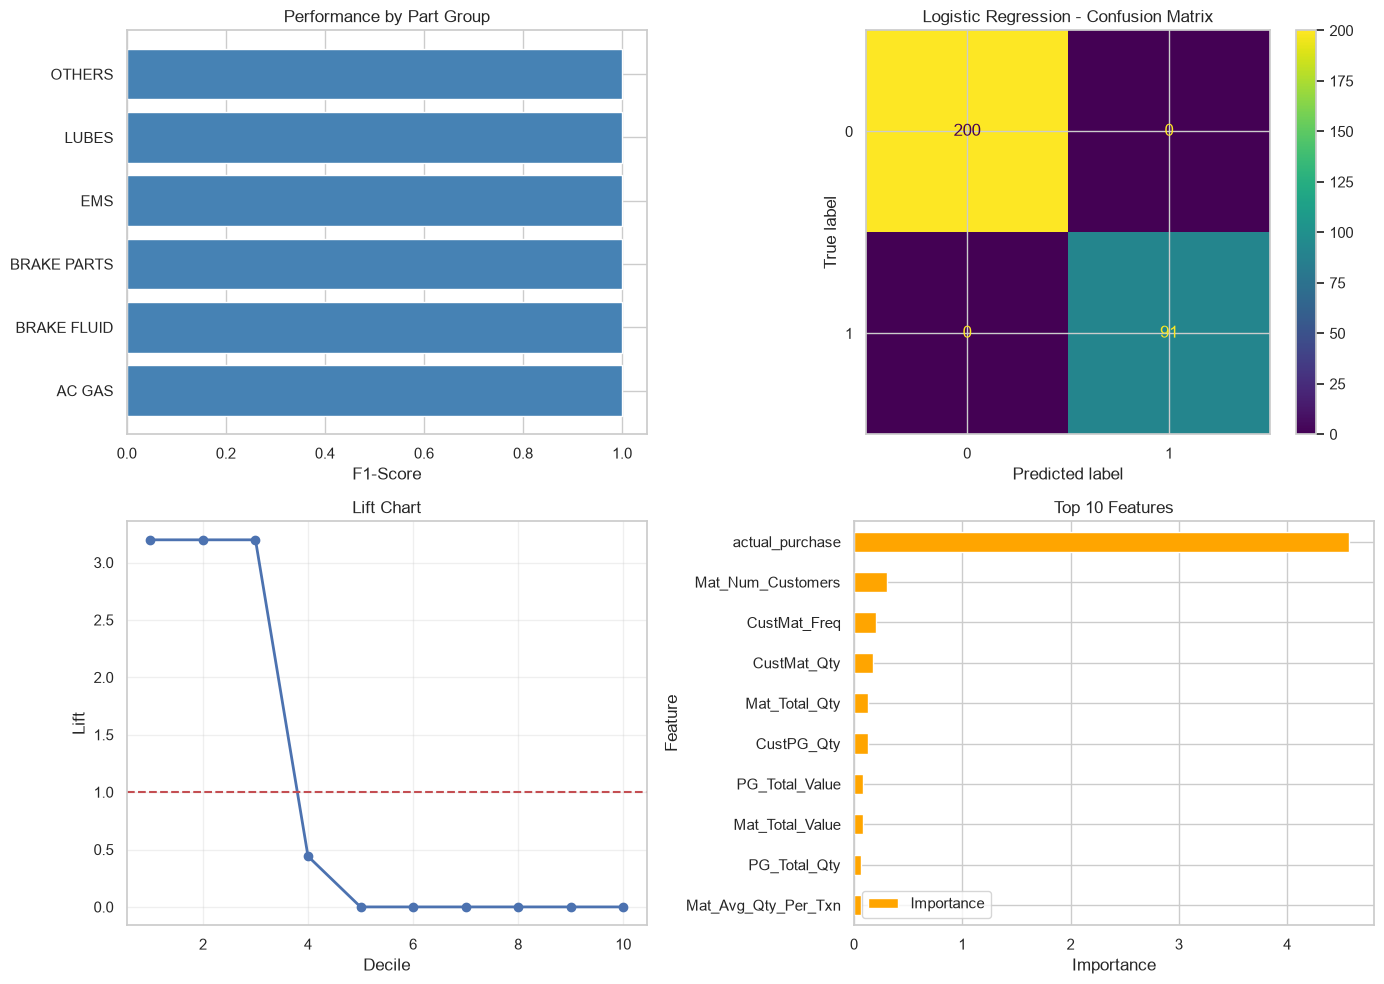

✅ Visualizations saved


In [395]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Part Group performance
pg_sorted = pg_perf.sort_values('F1-Score')
axes[0,0].barh(pg_sorted['Part Group'], pg_sorted['F1-Score'], color='steelblue')
axes[0,0].set_xlabel('F1-Score')
axes[0,0].set_title('Performance by Part Group')

# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0,1])
axes[0,1].set_title(f'{best_model_name} - Confusion Matrix')

# Lift chart
axes[1,0].plot(deciles['Decile'], deciles['Lift'], marker='o', linewidth=2)
axes[1,0].axhline(y=1, color='r', linestyle='--')
axes[1,0].set_xlabel('Decile')
axes[1,0].set_ylabel('Lift')
axes[1,0].set_title('Lift Chart')
axes[1,0].grid(alpha=0.3)

# Feature importance
feature_importance.head(10).sort_values('Importance').plot(x='Feature', y='Importance', kind='barh', ax=axes[1,1], color='orange')
axes[1,1].set_xlabel('Importance')
axes[1,1].set_title('Top 10 Features')

plt.tight_layout()
plt.savefig('model_validation_results.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ Visualizations saved')

In [396]:
# Export all results
overall_perf.to_csv('01_overall_model_performance.csv', index=False)
pg_perf.to_csv('02_performance_per_partgroup.csv', index=False)
mat_perf.to_csv('03_performance_per_material.csv', index=False)
deciles.to_csv('04_lift_gain_analysis.csv', index=False)
feature_importance.to_csv('05_feature_importance.csv', index=False)
final_recommendations.to_csv('06_final_recommendations.csv', index=False)
test_results.to_csv('07_test_predictions.csv', index=False)

print('✅ Results exported to CSV files:')
print('   - 01_overall_model_performance.csv')
print('   - 02_performance_per_partgroup.csv')
print('   - 03_performance_per_material.csv')
print('   - 04_lift_gain_analysis.csv')
print('   - 05_feature_importance.csv')
print('   - 06_final_recommendations.csv')
print('   - 07_test_predictions.csv')

✅ Results exported to CSV files:
   - 01_overall_model_performance.csv
   - 02_performance_per_partgroup.csv
   - 03_performance_per_material.csv
   - 04_lift_gain_analysis.csv
   - 05_feature_importance.csv
   - 06_final_recommendations.csv
   - 07_test_predictions.csv


### Generating Summaries and Important Findings

In [397]:
print('='*80)
print('HYBRID RECOMMENDATION SYSTEM - MODEL VALIDATION REPORT')
print('='*80)
print()
print('📊 OVERALL PERFORMANCE')
print('-'*80)
best_row = overall_perf.loc[overall_perf['F1-Score'].idxmax()]
print(f'Best Model: {best_row["Model"]}')
print(f'  Accuracy:  {best_row["Accuracy"]:.1%}')
print(f'  Precision: {best_row["Precision"]:.1%}')
print(f'  Recall:    {best_row["Recall"]:.1%}')
print(f'  F1-Score:  {best_row["F1-Score"]:.3f}')
print(f'  AUC-ROC:   {best_row["AUC-ROC"]:.3f}')
print()
print('🎯 PART GROUP RANKINGS')
print('-'*80)
top_pg = pg_perf[['Part Group', 'F1-Score', 'Precision', 'Recall', 'Conversion Rate']].head(7)
print(top_pg.to_string(index=False))
print()
print('⭐ TOP 5 MATERIALS')
print('-'*80)
top_mat = mat_perf[['Material Desc', 'Part Group', 'F1-Score', 'Conversion Rate']].head(5)
print(top_mat.to_string(index=False))
print()
print('📈 BUSINESS IMPACT')
print('-'*80)
print(f'Overall conversion rate: {(test_results["actual"]==1).sum()/len(test_results)*100:.1f}%')
print(f'Lift in top decile: {deciles.iloc[0]["Lift"]:.2f}x')
print(f'Cumulative gain (top 30%): {deciles.iloc[2]["Gain"]:.1f}%')
print()
print('💡 KEY RECOMMENDATIONS')
print('-'*80)
print(f'1. Deploy {best_row["Model"]} for production')
print(f'2. Focus on top {len(pg_perf[pg_perf["F1-Score"]>0.7])} high-performing part groups')
print(f'3. Investigate low-performing materials (F1 < 0.5)')
print(f'4. Use model scores for ranking recommendations')
print(f'5. Monitor model performance monthly on new data')

HYBRID RECOMMENDATION SYSTEM - MODEL VALIDATION REPORT

📊 OVERALL PERFORMANCE
--------------------------------------------------------------------------------
Best Model: Logistic Regression
  Accuracy:  100.0%
  Precision: 100.0%
  Recall:    100.0%
  F1-Score:  1.000
  AUC-ROC:   1.000

🎯 PART GROUP RANKINGS
--------------------------------------------------------------------------------
 Part Group  F1-Score  Precision  Recall  Conversion Rate
     AC GAS    1.0000     1.0000  1.0000           0.0312
BRAKE FLUID    1.0000     1.0000  1.0000           0.4242
BRAKE PARTS    1.0000     1.0000  1.0000           0.5930
        EMS    1.0000     1.0000  1.0000           1.0000
      LUBES    1.0000     1.0000  1.0000           0.0341
     OTHERS    1.0000     1.0000  1.0000           0.4000

⭐ TOP 5 MATERIALS
--------------------------------------------------------------------------------
                           Material Desc  Part Group  F1-Score  Conversion Rate
       SHOE KIT  (1 L